In [ ]:
from nltk.tokenize import sent_tokenize, word_tokenize
import pandas as pd
import nltk
from nltk.corpus import stopwords
import spacy
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from matplotlib.ticker import FuncFormatter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Anxiety

## Pre processing

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 87.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
df_anxiety = pd.read_csv("/content/anxiety.csv")
df_anxiety.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,ID,Transcription,Tag,Link,Plataform,Views / Likes,Classificação
0,3.0,Perfect outbacks horário das Neves Extra Dina ...,ansiedade,https://www.instagram.com/reel/C9PYPffuoVd/?ig...,Instagram,5902720,Inglês
1,12.0,o que você tá sentindo tão cedo eu tenho ansie...,ansiedade,https://www.instagram.com/reel/CmSdSD8DOWn/?ig...,Instagram,2237871,Fora do tema
2,17.0,Juliana Hatch do best for you evening feels e ...,ansiedade,https://www.instagram.com/reel/C_Y8n0MyQk2/?ig...,Instagram,2768650,Inglês
3,22.0,Eu sempre me curei sozinho eu não tenho costum...,ansiedade,https://www.instagram.com/reel/Cy3Dpd4u2mA/?ig...,Instagram,1811926,Fora do tema
4,23.0,falo não é todo mundo morreria por alguém da f...,ansiedade,https://www.instagram.com/reel/DHsw8yeO8NO/?ig...,Instagram,2881558,Fora do tema


In [ ]:
df_anxiety['Classificação'].unique()

array(['Inglês', 'Fora do tema', 'ENGANOSO', 'Depressão',
       'EXPERIÊNCIA PESSOAL', 'TDAH e TEA', 'ÚTIL', 'ÚTIL '], dtype=object)

In [ ]:
# Using one hot encoding
dictionary = dict({
    "experiência pessoal": 1,
    "útil": 2,
    "enganoso": 3,
    "outra": 4,
    "excluído (espanhol/Inglês)": 5
})

# Replacing in Classifier column and removing blank spaces in the end
df_anxiety['Classificação'] = df_anxiety['Classificação'].str.rstrip()
# Change to lower case
df_anxiety['Classificação'] = df_anxiety['Classificação'].str.lower()
# Converting to one hot encoding
df_anxiety['Classificação'] = df_anxiety['Classificação'].replace(dictionary)
df_anxiety = df_anxiety[~df_anxiety['Classificação'].apply(lambda x: isinstance(x, str))]

#Remove rows with 4 value
df_anxiety = df_anxiety[df_anxiety['Classificação'] != 5]
df_anxiety.head()

,ID,Transcription,Tag,Link,Plataform,Views / Likes,Classificação
8,32.0,Você sabia que o seu sentimentos duram no máxi...,ansiedade,https://www.instagram.com/reel/C-ldne6S5wG/?ig...,Instagram,1420394,3
13,53.0,Por que tem tanta gente tem gente demais na te...,ansiedade,https://www.instagram.com/reel/C-AnnGjugzS/?ig...,Instagram,3417117,1
46,NaN,Uma Mente eu venho sentindo um vazio tão grand...,ansiedade,https://vm.tiktok.com/ZMSY4CRo3/,TikTok,184.000,1
47,NaN,toda pessoa ansiosa tem esses três sintomas qu...,ansiedade,https://vm.tiktok.com/ZMSY4bHQd/,TikTok,190.000,3
48,NaN,ai mais um dia normal na minha vida vai vai es...,ansiedade,https://vm.tiktok.com/ZMSY4pEq8/,TikTok,983.000,1


In [ ]:
sent_tokenize(df_anxiety['Transcription'].iloc[0])
df_anxiety['tokenized_words'] = df_anxiety['Transcription'].apply(lambda x: word_tokenize(x))

stop_words = set(stopwords.words('portuguese'))
df_anxiety['removed_stopwords'] = df_anxiety['tokenized_words'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
df_anxiety.head()

,ID,Transcription,Tag,Link,Plataform,Views / Likes,Classificação,tokenized_words,removed_stopwords
8,32.0,Você sabia que o seu sentimentos duram no máxi...,ansiedade,https://www.instagram.com/reel/C-ldne6S5wG/?ig...,Instagram,1420394,3,"[Você, sabia, que, o, seu, sentimentos, duram,...","[sabia, sentimentos, duram, máximo, 90, segund..."
13,53.0,Por que tem tanta gente tem gente demais na te...,ansiedade,https://www.instagram.com/reel/C-AnnGjugzS/?ig...,Instagram,3417117,1,"[Por, que, tem, tanta, gente, tem, gente, dema...","[tanta, gente, gente, demais, terra, Precisamo..."
46,NaN,Uma Mente eu venho sentindo um vazio tão grand...,ansiedade,https://vm.tiktok.com/ZMSY4CRo3/,TikTok,184.000,1,"[Uma, Mente, eu, venho, sentindo, um, vazio, t...","[Mente, venho, sentindo, vazio, tão, grande, c..."
47,NaN,toda pessoa ansiosa tem esses três sintomas qu...,ansiedade,https://vm.tiktok.com/ZMSY4bHQd/,TikTok,190.000,3,"[toda, pessoa, ansiosa, tem, esses, três, sint...","[toda, pessoa, ansiosa, três, sintomas, vou, f..."
48,NaN,ai mais um dia normal na minha vida vai vai es...,ansiedade,https://vm.tiktok.com/ZMSY4pEq8/,TikTok,983.000,1,"[ai, mais, um, dia, normal, na, minha, vida, v...","[ai, dia, normal, vida, vai, vai, pulseira, bo..."


In [ ]:
vectorizer = TfidfVectorizer()
df_anxiety['tokenized_words_joined'] = df_anxiety['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df_anxiety['tokenized_words_joined'])
df_anxiety['Classificação'] = df_anxiety['Classificação'].astype('int')
y = df_anxiety['Classificação']

In [ ]:
nlp = spacy.load('pt_core_news_sm')

def aplicar_pos_tagging_spacy(texto):
    if not isinstance(texto, str):
        return []

    doc = nlp(texto)

    return [(token.text, token.pos_) for token in doc]


df_anxiety['pos_tags'] = df_anxiety['Transcription'].apply(aplicar_pos_tagging_spacy)

In [ ]:
def pos_tag_de_lista_de_palavras(lista_de_palavras: list) -> list:
    if not isinstance(lista_de_palavras, list):
        return []

    texto = " ".join(lista_de_palavras)

    doc = nlp(texto)

    return [(token.text, token.pos_) for token in doc if not token.is_punct]

df_anxiety['pos_tags_stopwords'] = df_anxiety['removed_stopwords'].apply(pos_tag_de_lista_de_palavras)

### Plots dataset

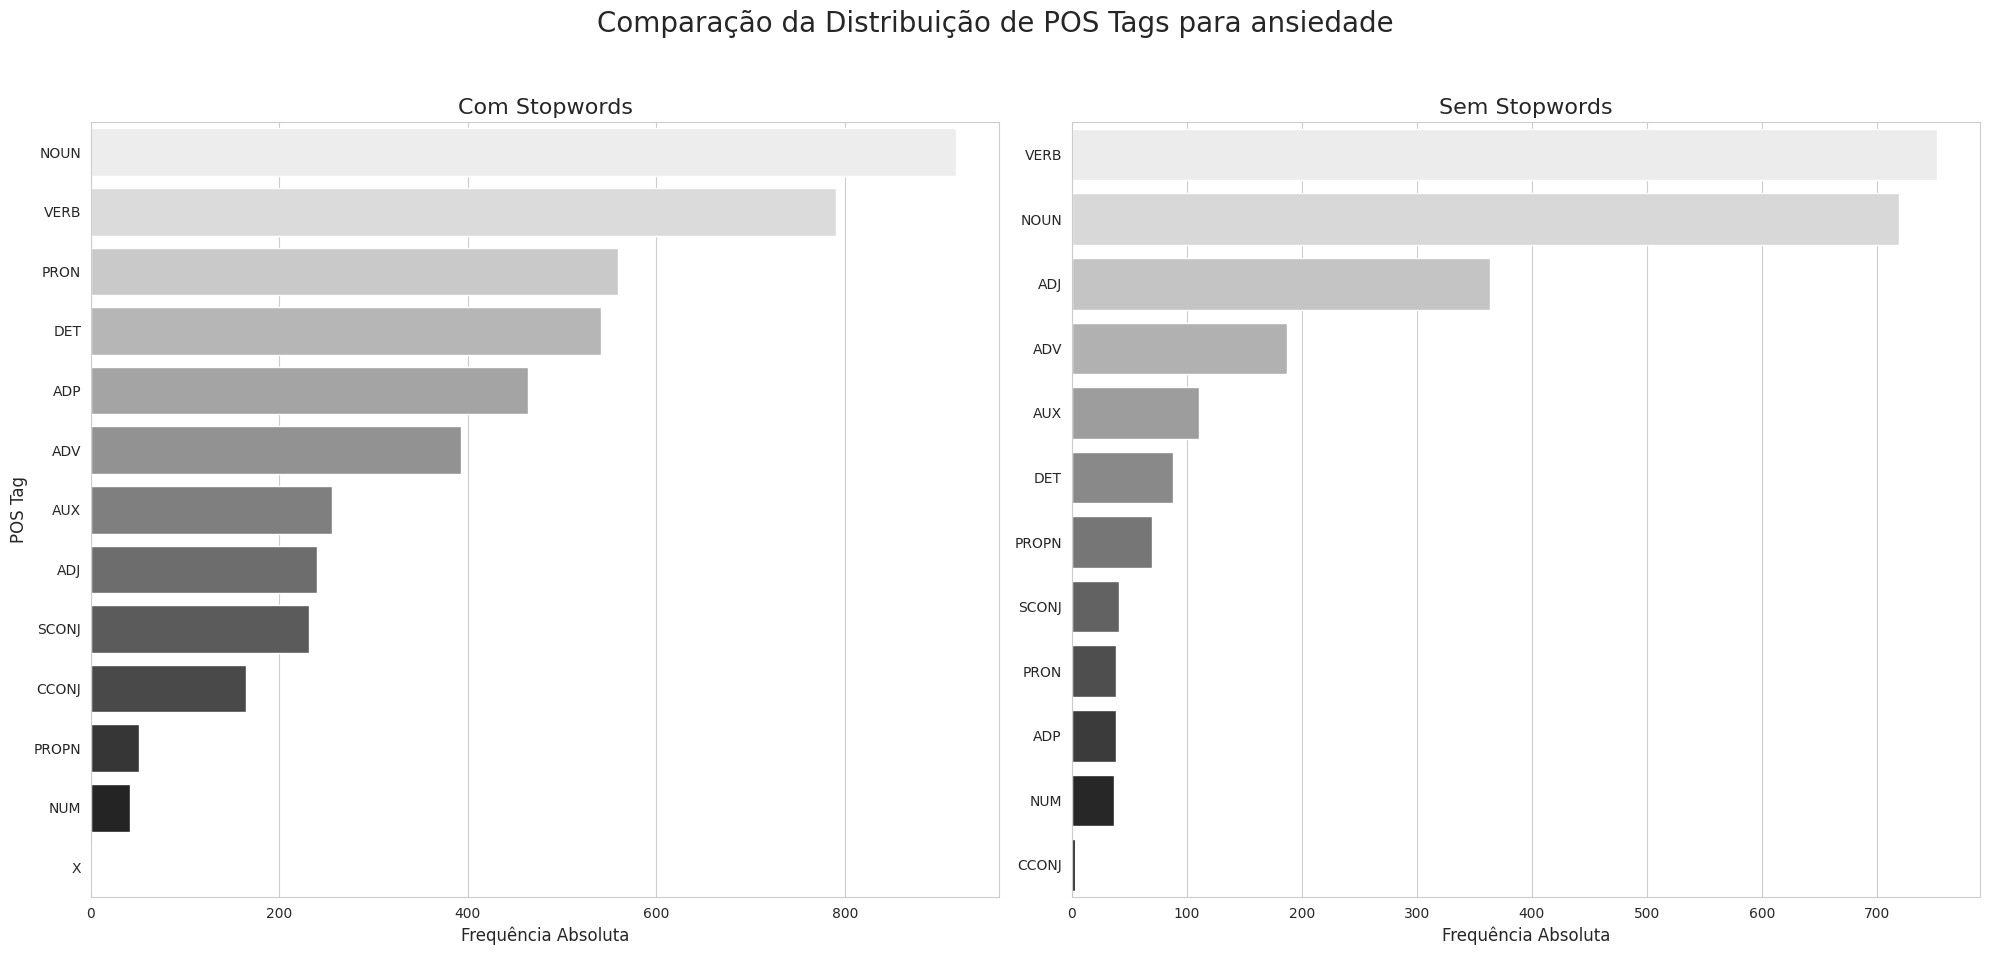

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_anxiety['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_anxiety['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparação da Distribuição de POS Tags para ansiedade', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('Com Stopwords', fontsize=16)
axes[0].set_xlabel('Frequência Absoluta', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Frequência Absoluta', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

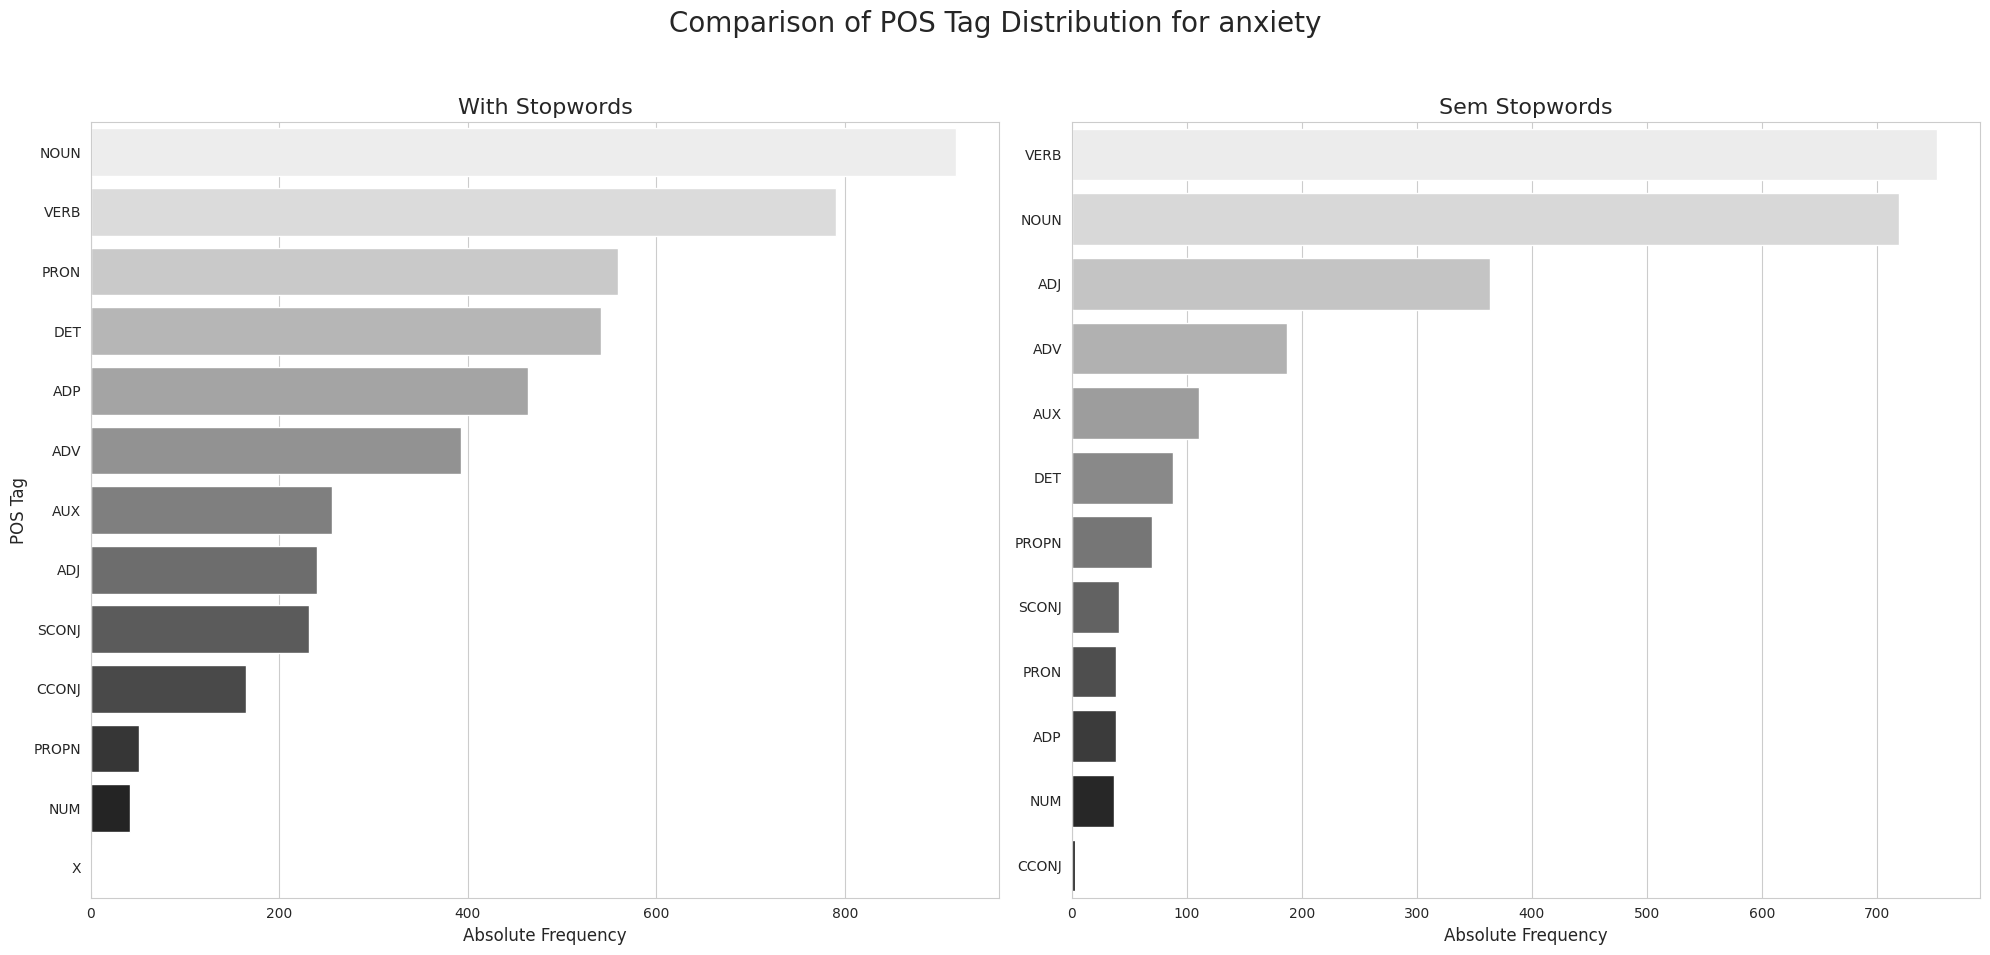

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_anxiety['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_anxiety['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparison of POS Tag Distribution for anxiety', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('With Stopwords', fontsize=16)
axes[0].set_xlabel('Absolute Frequency', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Absolute Frequency', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

In [ ]:
df_anxiety['Views / Likes'] = df_anxiety['Views / Likes'].str.replace('.', '', regex=False)
df_anxiety['Views / Likes'] = df_anxiety['Views / Likes'].astype(int)

df_anxiety['ID'] = np.arange(len(df_anxiety))

df_anxiety = df_anxiety.sort_values(by='Views / Likes', ascending=False)

In [ ]:
def format_views(x):
    if x >= 1000000:
        return f'{x//1_000_000}M'
    elif x >= 1000:
        return f'{x//1000}k'
    else:
        return str(x)

df_anxiety['Views / Likes_str'] = df_anxiety['Views / Likes'].apply(format_views)

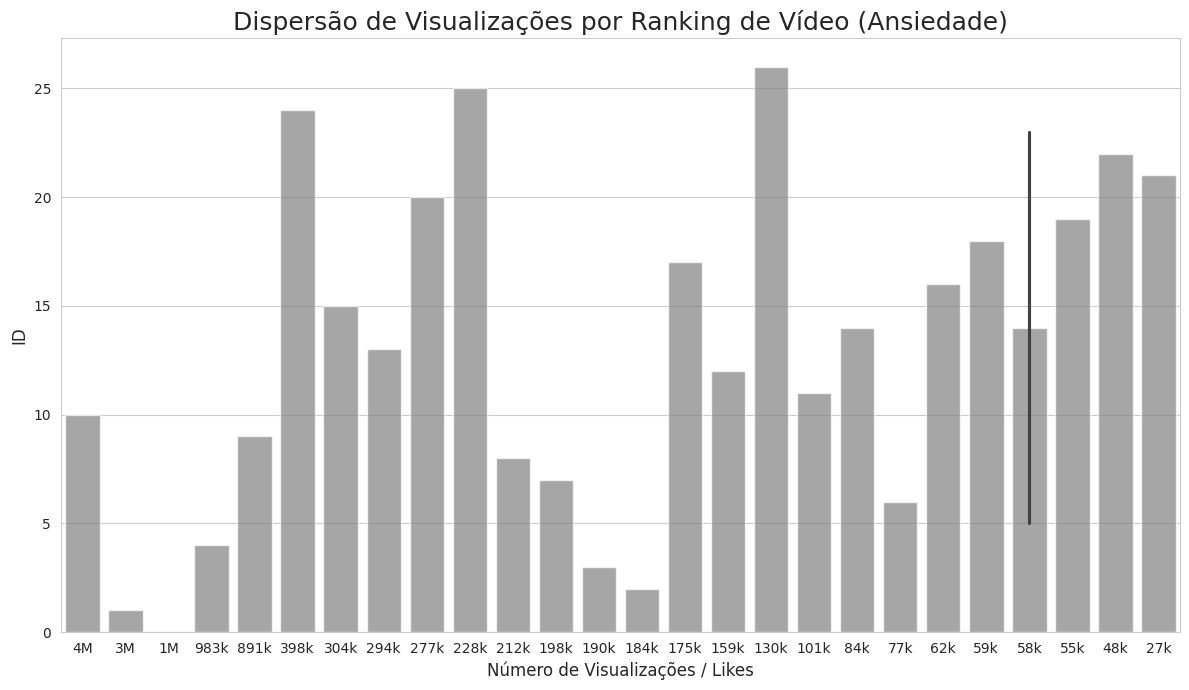

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    x='Views / Likes_str',
    y='ID',
    data=df_anxiety,
    color='gray',
    alpha=0.7
)

plt.title('Dispersão de Visualizações por Ranking de Vídeo (Ansiedade)', fontsize=18)
plt.xlabel('Número de Visualizações / Likes', fontsize=12)
plt.ylabel('ID', fontsize=12)

plt.tight_layout()
plt.show()

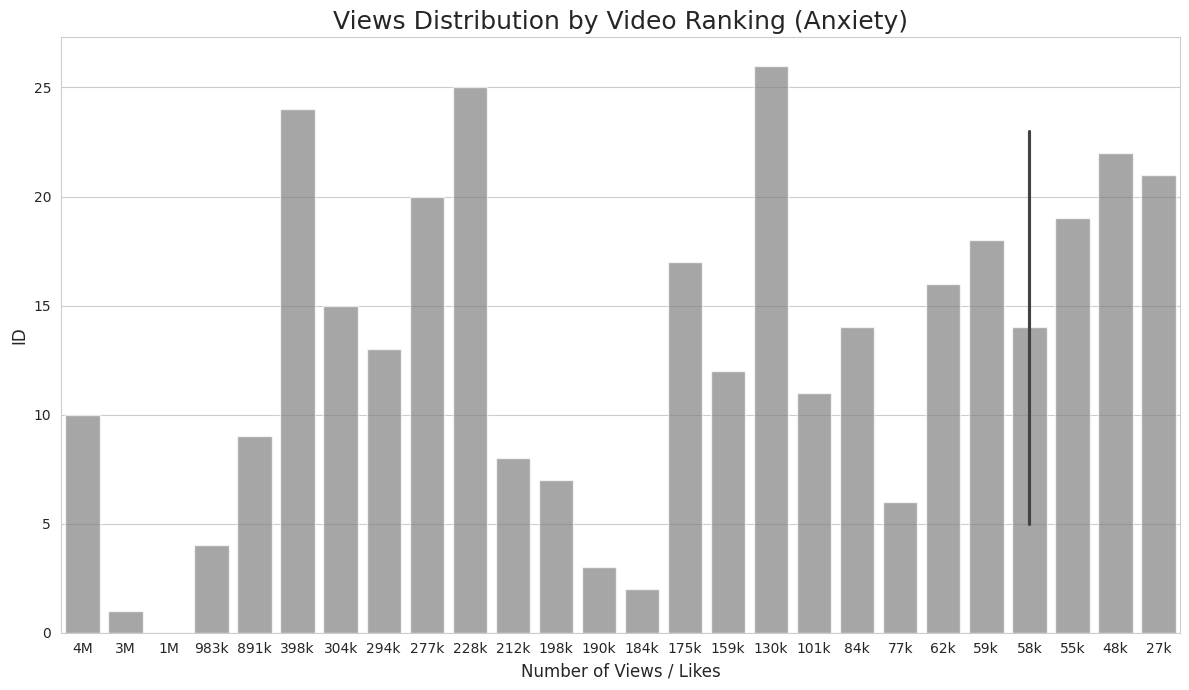

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    x='Views / Likes_str',
    y='ID',
    data=df_anxiety,
    color='gray',
    alpha=0.7
)

plt.title('Views Distribution by Video Ranking (Anxiety)', fontsize=18)
plt.xlabel('Number of Views / Likes', fontsize=12)
plt.ylabel('ID', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
texts_by_class = {}
for class_id in df_anxiety['Classificação'].unique():
    class_texts = df_anxiety[df_anxiety['Classificação'] == class_id]['Transcription'].tolist()
    texts_by_class[class_id] = class_texts
    print(f"Classe {class_id}: {len(class_texts)} textos")

Classe 2: 14 textos
Classe 1: 9 textos
Classe 3: 4 textos


In [ ]:
def convert_views_to_numeric(view_str):
    view_str = str(view_str).strip().upper()
    if 'M' in view_str:
        return float(view_str.replace('M', '')) * 1_000_000
    if 'K' in view_str:
        return float(view_str.replace('K', '')) * 1_000
    try:
        return float(view_str)
    except (ValueError, TypeError):
        return pd.NA

df_anxiety['Views_Numeric'] = df_anxiety['Views / Likes_str'].apply(convert_views_to_numeric)

df_plot_anxiety = df_anxiety.sort_values('Views_Numeric', ascending=False).reset_index(drop=True)

df_plot_anxiety['Ranking'] = df_plot_anxiety.index + 1

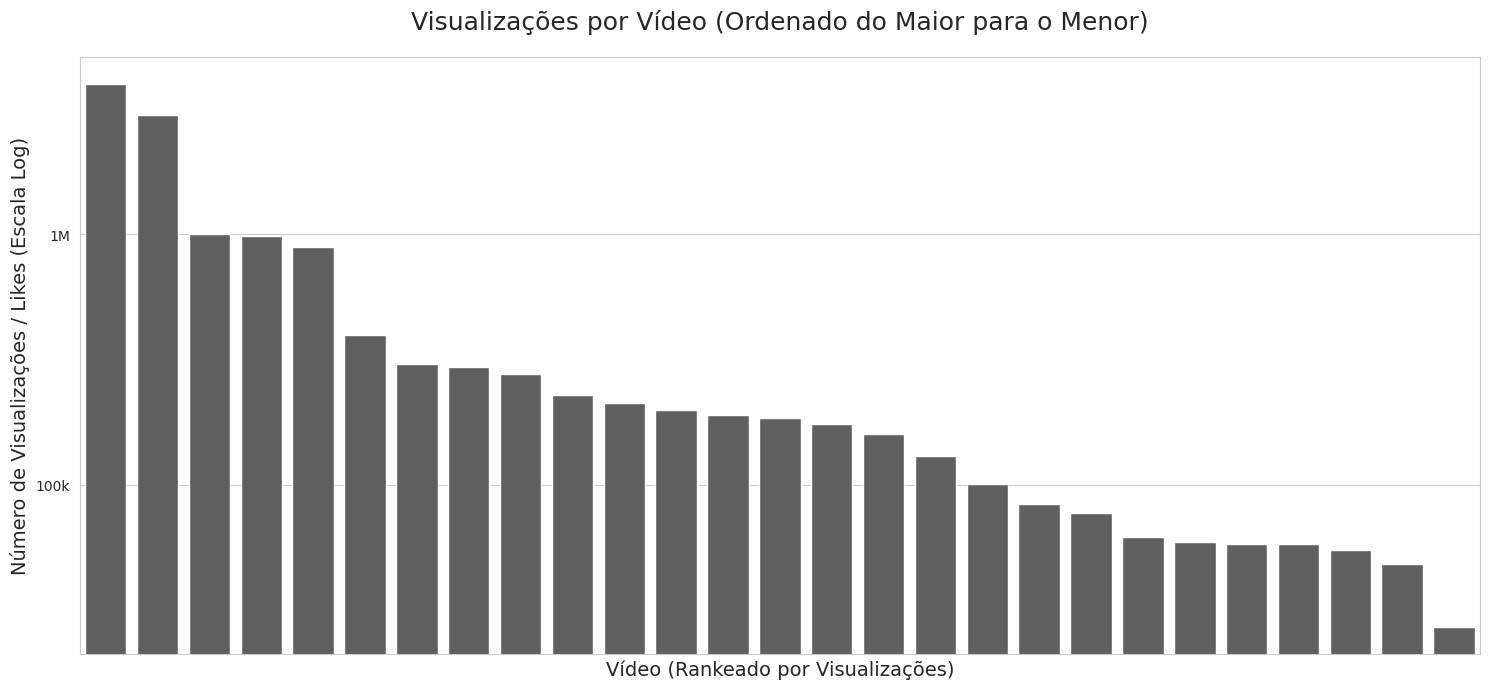

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

barplot = sns.barplot(
    data=df_plot_anxiety,
    x='Ranking',
    y='Views_Numeric',
    color='#606060'
)

plt.yscale('log')

plt.title('Visualizações por Vídeo (Ordenado do Maior para o Menor)', fontsize=18, pad=20)
plt.xlabel('Vídeo (Rankeado por Visualizações)', fontsize=14)
plt.ylabel('Número de Visualizações / Likes (Escala Log)', fontsize=14)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda y, pos: f'{y/1_000_000:.0f}M' if y >= 1_000_000 else (f'{y/1_000:.0f}k' if y >= 1_000 else f'{y:.0f}'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks([])

plt.tight_layout()
plt.show()

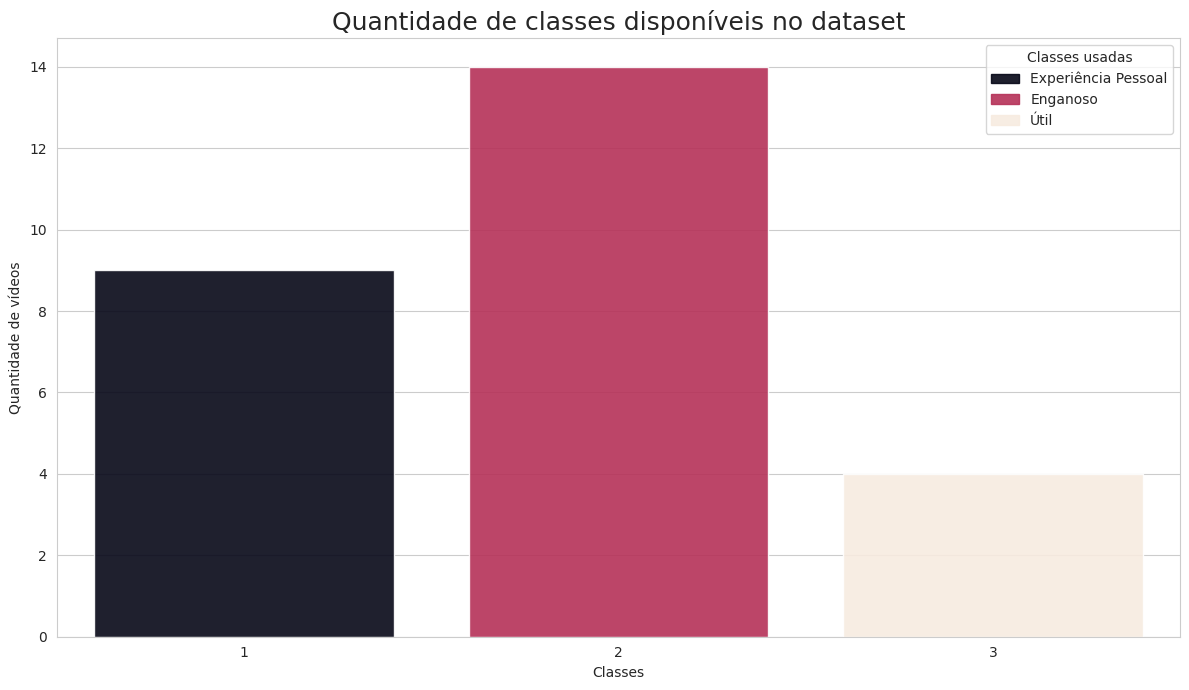

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

barplot = sns.countplot(
    x='Classificação',
    data=df_anxiety,
    palette='rocket',
    hue='Classificação',
    alpha=0.9
)

nomes_legenda = ["Experiência Pessoal", "Enganoso", "Útil"]

cores = [p.get_facecolor() for p in barplot.patches[:len(nomes_legenda)]]

handles = [Patch(color=cores[i], label=nomes_legenda[i]) for i in range(len(nomes_legenda))]

plt.legend(handles=handles, title="Classes usadas")

plt.title('Quantidade de classes disponíveis no dataset', fontsize=18)
plt.xlabel("Classes")
plt.ylabel("Quantidade de vídeos")

plt.tight_layout()
plt.show()


## Treinamento

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from transformers import AutoTokenizer, AutoModel
import random
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from nltk.tokenize import word_tokenize
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name)

def get_text_embeddings(texts, batch_size=32, max_length=128, device='cpu'):
    """Converte textos em embeddings usando BERT em modo batch."""
    all_embeddings = []
    embedding_model.to(device)

    for i in tqdm(range(0, len(texts), batch_size), desc="Gerando Embeddings"):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = embedding_model(**inputs)
            # Usa o embedding do token [CLS] como representação da sentença
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

print("Gerando embeddings...")
embeddings_by_class = {}
for class_id, texts in texts_by_class.items():
    print(f"Processando classe {class_id}...")
    embeddings = get_text_embeddings(texts[:100])
    embeddings_by_class[class_id] = embeddings
    print(f"  Shape: {embeddings.shape}")

class Generator(nn.Module):
    """Gerador da GAN para criar embeddings sintéticos"""
    def __init__(self, noise_dim=100, embedding_dim=768, hidden_dim=512):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim, embedding_dim),
            nn.Tanh()  # Normalizar saída
        )

    def forward(self, noise):
        return self.model(noise)

class Discriminator(nn.Module):
    """Discriminador da GAN para distinguir embeddings reais de sintéticos"""
    def __init__(self, embedding_dim=768, hidden_dim=512):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(embedding_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, embedding):
        return self.model(embedding)


def train_gan_for_class(embeddings, epochs=100, batch_size=16, noise_dim=100, device='cpu'): # 1. Adicionar 'device' como parâmetro
    """Treina uma GAN para uma classe específica no dispositivo correto."""

    if len(embeddings) < batch_size:
        print(f"Poucos dados ({len(embeddings)}), ajustando batch_size para {len(embeddings)}")
        batch_size = len(embeddings)

    embedding_dim = embeddings.shape[1]

    generator = Generator(noise_dim, embedding_dim).to(device)
    discriminator = Discriminator(embedding_dim).to(device)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    real_embeddings = torch.FloatTensor(embeddings).to(device)

    g_losses, d_losses = [], []
    print(f"Iniciando treinamento com {len(embeddings)} amostras")

    for epoch in range(epochs):
        indices = torch.randperm(len(real_embeddings))
        epoch_g_loss, epoch_d_loss, num_batches = 0, 0, 0

        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            real_batch = real_embeddings[batch_indices]
            batch_len = len(real_batch)

            if batch_len <= 1:
              continue

            real_labels = torch.ones(batch_len, 1).to(device)
            fake_labels = torch.zeros(batch_len, 1).to(device)

            # --- Treinar Discriminador ---
            d_optimizer.zero_grad()
            d_real_loss = criterion(discriminator(real_batch), real_labels)

            noise = torch.randn(batch_len, noise_dim).to(device)
            with torch.no_grad():
                fake_batch = generator(noise)
            d_fake_loss = criterion(discriminator(fake_batch), fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()

            # --- Treinar Gerador ---
            g_optimizer.zero_grad()
            noise = torch.randn(batch_len, noise_dim).to(device)
            fake_batch = generator(noise)
            g_loss = criterion(discriminator(fake_batch), real_labels)

            g_loss.backward()
            g_optimizer.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1

        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}")

    return generator, discriminator, g_losses, d_losses

scalers_by_class = {}
scaled_embeddings_by_class = {}

for class_id, embeddings in embeddings_by_class.items():
    if len(embeddings) < 3:
        print(f"Classe {class_id} tem dados insuficientes para normalização, pulando.")
        continue

    scaler = StandardScaler()

    scaled_embeddings = scaler.fit_transform(embeddings)

    scalers_by_class[class_id] = scaler
    scaled_embeddings_by_class[class_id] = scaled_embeddings


generators = {}
discriminators = {}
training_histories = {}

for class_id, scaled_embeddings in scaled_embeddings_by_class.items():
    print(f"\nTREINANDO GAN PARA CLASSE {class_id}")

    try:
        generator, discriminator, g_losses, d_losses = train_gan_for_class(
            scaled_embeddings,
            epochs=100,
            batch_size=8,
            device=device
        )

        generators[class_id] = generator
        discriminators[class_id] = discriminator
        training_histories[class_id] = {'g_losses': g_losses, 'd_losses': d_losses}

        print(f"GAN treinada para classe {class_id}")

    except Exception as e:
        print(f"Erro ao treinar GAN para classe {class_id}: {e}")

def generate_and_rescale_embeddings(generator, scaler, num_samples=50, noise_dim=100, device='cpu'):
    """Gera embeddings sintéticos e os retorna para a escala original."""
    generator.eval()
    generator.to(device)

    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim).to(device)
        synthetic_embeddings_scaled = generator(noise)

        synthetic_embeddings_scaled = synthetic_embeddings_scaled.cpu().numpy()

    synthetic_embeddings_original_scale = scaler.inverse_transform(synthetic_embeddings_scaled)

    return synthetic_embeddings_original_scale

synthetic_embeddings_by_class = {}

for class_id, generator in generators.items():
    print(f"\nGerando embeddings sintéticos para classe {class_id}")

    scaler = scalers_by_class[class_id]

    original_count = len(embeddings_by_class[class_id])
    target_count = max(100, original_count * 3)

    final_synthetic_embeddings = generate_and_rescale_embeddings(
        generator,
        scaler,
        num_samples=target_count,
        device=device
    )

    synthetic_embeddings_by_class[class_id] = final_synthetic_embeddings

    print(f"  Originais: {original_count}, Sintéticos gerados: {len(final_synthetic_embeddings)}")
    print(f"  Média dos embeddings sintéticos (escala original): {final_synthetic_embeddings.mean():.2f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

  Shape: (14, 768)
Processando classe 1...


Gerando Embeddings: 100%|██████████| 1/1 [00:05<00:00,  5.58s/it]


  Shape: (9, 768)
Processando classe 3...


Gerando Embeddings: 100%|██████████| 1/1 [00:03<00:00,  3.33s/it]


  Shape: (4, 768)

TREINANDO GAN PARA CLASSE 2
Iniciando treinamento com 14 amostras
Epoch 0: G_Loss = 0.7350, D_Loss = 1.3808
Epoch 20: G_Loss = 0.7186, D_Loss = 0.9003
Epoch 40: G_Loss = 1.2439, D_Loss = 0.7862
Epoch 60: G_Loss = 1.9524, D_Loss = 0.3652
Epoch 80: G_Loss = 3.0900, D_Loss = 0.2875
GAN treinada para classe 2

TREINANDO GAN PARA CLASSE 1
Iniciando treinamento com 9 amostras
Epoch 0: G_Loss = 0.6744, D_Loss = 1.3825
Epoch 20: G_Loss = 0.6286, D_Loss = 1.1625
Epoch 40: G_Loss = 0.7211, D_Loss = 1.0029
Epoch 60: G_Loss = 0.9115, D_Loss = 0.7529
Epoch 80: G_Loss = 1.3264, D_Loss = 0.5946
GAN treinada para classe 1

TREINANDO GAN PARA CLASSE 3
Poucos dados (4), ajustando batch_size para 4
Iniciando treinamento com 4 amostras
Epoch 0: G_Loss = 0.6974, D_Loss = 1.3736
Epoch 20: G_Loss = 0.6802, D_Loss = 1.0922
Epoch 40: G_Loss = 0.7056, D_Loss = 0.7946
Epoch 60: G_Loss = 1.0043, D_Loss = 0.6849
Epoch 80: G_Loss = 1.3855, D_Loss = 0.5919
GAN treinada para classe 3

Gerando embed

In [ ]:
from transformers import pipeline
import torch
from tqdm import tqdm
import random
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model_name = "bigscience/bloomz-1b1"
generator_pipeline = pipeline('text-generation', model=model_name, device=0 if torch.cuda.is_available() else -1)

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.13G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Device set to use cuda:0


## Generate synthetic text using cosine similarity

Processando classe 2...


Gerando Embeddings: 100%|██████████| 1/1 [00:04<00:00,  4.63s/it]


  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:05<00:00,  5.74s/it]


  Processados 60/100


...

  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:02<00:00,  2.01s/it]


  Processados 60/100


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.38s/it]


  Gerados 100 textos sintéticos
Dataset original: 27 amostras
Dataset aumentado com GANs: 327 amostras
Aumento: 1111.1%

Distribuição das classes no dataset GAN-aumentado:
Classificação
2    114
1    109
3    104
Name: count, dtype: int64


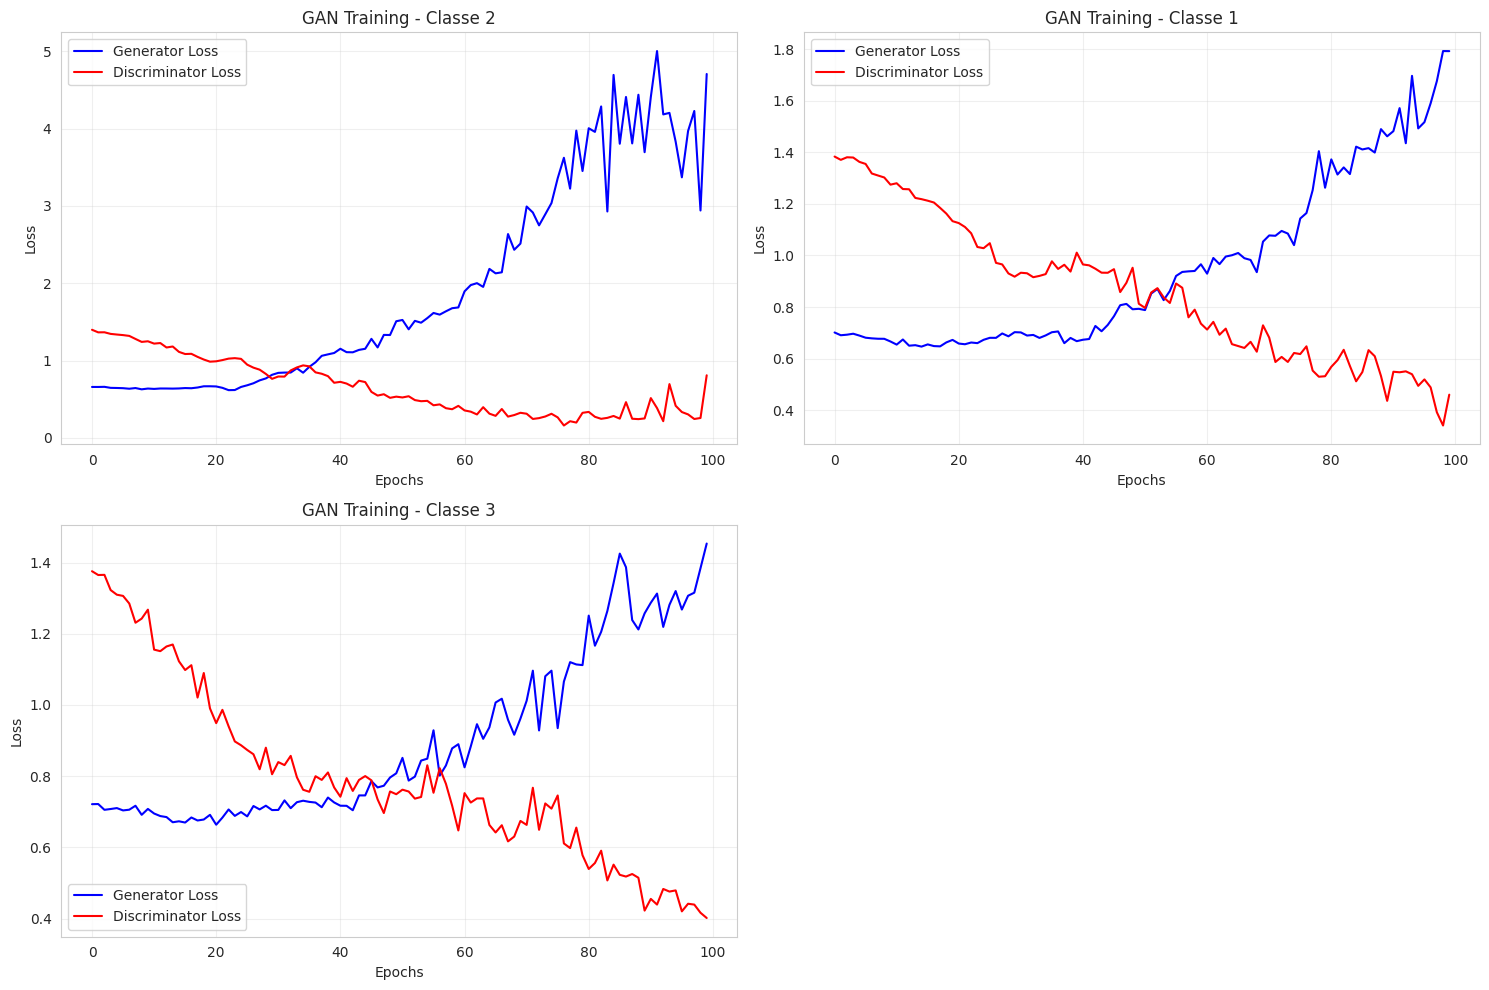

In [ ]:
def embedding_to_text_simple(embedding, original_texts, similarity_threshold=0.7):
    """
    Converte embedding sintético em texto usando similaridade com textos originais.
    Esta é uma abordagem simplificada - para produção, usaria modelos mais sofisticados.
    """
    original_embeddings = get_text_embeddings(original_texts[:20])

    similarities = []
    for orig_emb in original_embeddings:
        similarity = np.dot(embedding, orig_emb) / (np.linalg.norm(embedding) * np.linalg.norm(orig_emb))
        similarities.append(similarity)

    most_similar_idx = np.argmax(similarities)
    most_similar_text = original_texts[most_similar_idx]
    max_similarity = similarities[most_similar_idx]

    if max_similarity < similarity_threshold:
        words = most_similar_text.split()

        if len(words) > 3:
            if random.random() > 0.5:
                idx1, idx2 = random.sample(range(len(words)), 2)
                words[idx1], words[idx2] = words[idx2], words[idx1]

            if random.random() > 0.5:
                connectors = ["então", "mas", "porém", "além disso", "na verdade"]
                connector = random.choice(connectors)
                words.insert(random.randint(0, len(words)), connector)

        return ' '.join(words)

    return most_similar_text

synthetic_texts_by_class_cosine = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando classe {class_id}...")

    original_texts = texts_by_class[class_id]
    synthetic_texts = []

    # Processar em lotes menores para evitar sobrecarga
    batch_size = 10
    for i in range(0, len(synthetic_embeddings), batch_size):
        batch_embeddings = synthetic_embeddings[i:i+batch_size]

        for embedding in batch_embeddings:
            try:
                synthetic_text = embedding_to_text_simple(embedding, original_texts)
                synthetic_texts.append(synthetic_text)
            except Exception as e:
                print(f"Erro ao converter embedding: {e}")
                # Usar texto original como fallback
                synthetic_texts.append(random.choice(original_texts))

        if i % 50 == 0:
            print(f"  Processados {min(i+batch_size, len(synthetic_embeddings))}/{len(synthetic_embeddings)}")

    synthetic_texts_by_class_cosine[class_id] = synthetic_texts
    print(f"  Gerados {len(synthetic_texts)} textos sintéticos")

    anxiety_gan_augmented_data_cosine = []

for _, row in df_anxiety.iterrows():
    anxiety_gan_augmented_data_cosine.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class_cosine.items():
    for text in synthetic_texts:
        anxiety_gan_augmented_data_cosine.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

# Criar DataFrame
df_anxiety_gan_augmented_cosine = pd.DataFrame(anxiety_gan_augmented_data_cosine)

print(f"Dataset original: {len(df_anxiety)} amostras")
print(f"Dataset aumentado com GANs: {len(df_anxiety_gan_augmented_cosine)} amostras")
print(f"Aumento: {((len(df_anxiety_gan_augmented_cosine) - len(df_anxiety)) / len(df_anxiety) * 100):.1f}%")

print("\nDistribuição das classes no dataset GAN-aumentado:")
print(df_anxiety_gan_augmented_cosine['Classificação'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

# Remover subplots não utilizados
for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
def preprocess_dataframe(df, text_column='Transcription'):
    """Aplica tokenização, remoção de stopwords e junção de tokens em um DataFrame."""
    print(f"Pré-processando DataFrame... Tamanho: {len(df)} linhas.")
    df_processed = df.copy()
    df_processed['tokenized_words'] = df_processed[text_column].apply(
        lambda x: word_tokenize(str(x))
    )
    df_processed['removed_stopwords'] = df_processed['tokenized_words'].apply(
        lambda x: [word for word in x if word.lower() not in stop_words]
    )
    df_processed['tokenized_words_joined'] = df_processed['removed_stopwords'].apply(
        lambda x: ' '.join(x)
    )
    return df_processed

def find_best_models_and_evaluate(data, title):
    """
    Vetoriza os dados, encontra os melhores hiperparâmetros para cada modelo via GridSearchCV
    e avalia o desempenho no conjunto de validação.
    """
    print(f"INICIANDO AVALIAÇÃO: {title}\n")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
            'params': {
              'C': [0.01, 0.1, 0.5, 1.0, 10.0],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear'],
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
              'n_estimators': [10, 50, 100, 200],
              'max_depth': [1, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
              'max_features': ['sqrt', 'log2']
            }
        },
        'SVM': {
            'model': SVC(random_state=42, class_weight='balanced', probability=True),
            'params': {
              'C': [0.01, 0.1, 1, 10],
              'gamma': ['scale', 'auto'],
              'kernel': ['linear', 'rbf']
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
              'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
              'fit_prior': [True, False]
            }
        }
    }

    results = {}
    cv_strategy = StratifiedKFold(n_splits=3)

    for model_name, config in model_configs.items():
        print(f"--- Treinando e otimizando {model_name} ---")
        try:
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=cv_strategy,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"  Melhores parâmetros: {grid_search.best_params_}")

            y_pred = best_model.predict(X_val)
            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro'),
                'best_params': grid_search.best_params_
            }

            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score (Macro): {results[model_name]['f1']:.4f}")
            print(f"  Precision: {results[model_name]['precision']:.4f}")
            print(f"  Recall: {results[model_name]['recall']:.4f}\n")

        except Exception as e:
            print(f"  ERRO com {model_name}: {e}\n")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0, 'best_params': {}}

    return results


df_original_for_cossine_processed = preprocess_dataframe(df_anxiety)
df_gan_augmented_for_cossine_processed = preprocess_dataframe(df_anxiety_gan_augmented_cosine)

results_original_cossine = find_best_models_and_evaluate(df_original_for_cossine_processed, "DADOS ORIGINAIS (Cosseno)")
results_gan_augmented_cossine = find_best_models_and_evaluate(df_gan_augmented_for_cossine_processed, "DADOS GAN-AUMENTADOS (Cosseno)")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_original_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results_gan_augmented_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")


Pré-processando DataFrame... Tamanho: 27 linhas.
Pré-processando DataFrame... Tamanho: 327 linhas.
INICIANDO AVALIAÇÃO: DADOS ORIGINAIS (Cosseno)

Tamanho do dataset: 27
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.5, 'fit_prior': True}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS (Cosseno)

Tamanho do dataset: 327
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.9545
  F1-Score (Macro): 0.9556
  Precision: 0.9615
  Recall: 0.9538

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 10}
  Accuracy: 0.9848
  F1-Score (Macro): 0.9845
  Precision: 0.9855
  Recall: 0.9841

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.9545
  F1-Score (Macro): 0.9556
  Precision: 0.9615
  Recall: 0.9538

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 10.0, 'fit_prior': False}
  Accuracy: 0.9394
  F1-Score (Macro): 0.9400
  Precision: 0.9425
  Recall

## Generating text using LLM

In [ ]:
def embedding_to_text(query_embedding, original_texts, original_embeddings):
    query_embedding = query_embedding.reshape(1, -1)
    similarities = cosine_similarity(query_embedding, original_embeddings)
    most_similar_index = np.argmax(similarities[0])
    return original_texts[most_similar_index]

def embedding_to_generative_text(query_embedding, original_texts, original_embeddings, generator, max_length=50):
    """
    Gera um texto novo e único a partir de um embedding.
    """
    seed_text = embedding_to_text(query_embedding, original_texts, original_embeddings)

    prompt = f"Reescreva a seguinte frase com outras palavras, mas mantendo o mesmo significado, sem traduzir para inglês: \"{seed_text}\"\nFrase reescrita:"

    try:
        generated_outputs = generator(
            prompt,
            max_length=len(seed_text.split()) + max_length,
            num_return_sequences=1,
            pad_token_id=generator.tokenizer.eos_token_id
        )

        generated_text = generated_outputs[0]['generated_text']
        clean_text = generated_text.replace(prompt, "").strip()

        return clean_text if clean_text else seed_text

    except Exception as e:
        print(f"Erro na geração de texto: {e}")
        return seed_text


synthetic_texts_by_class = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando e gerando textos para a classe {class_id}")

    original_texts = texts_by_class[class_id]
    original_embeds = embeddings_by_class[class_id]

    synthetic_texts = []

    for embedding in tqdm(synthetic_embeddings, desc=f"Gerando textos para classe {class_id}"):
        try:
            synthetic_text = embedding_to_generative_text(
                embedding,
                original_texts,
                original_embeds,
                generator_pipeline
            )
            synthetic_texts.append(synthetic_text)
        except Exception as e:
            print(f"Erro ao converter embedding: {e}")
            if original_texts:
                synthetic_texts.append(random.choice(original_texts))

    synthetic_texts_by_class[class_id] = synthetic_texts
    print(f"\nGerados {len(synthetic_texts)} textos sintéticos para a classe {class_id}")


Processando e gerando textos para a classe 2


Gerando textos para classe 2:   0%|          | 0/100 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=254) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Gerando textos para classe 2:  10%|█         | 10/100 [00:16<02:04,  1.38s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=256) and `max_length`(=254) seem to have been set. `max_new_tokens` will take precedence. Please 


Gerados 100 textos sintéticos para a classe 2
Processando e gerando textos para a classe 1


Gerando textos para classe 1: 100%|██████████| 100/100 [02:55<00:00,  1.75s/it]



Gerados 100 textos sintéticos para a classe 1
Processando e gerando textos para a classe 3


Gerando textos para classe 3: 100%|██████████| 100/100 [07:56<00:00,  4.76s/it]


Gerados 100 textos sintéticos para a classe 3


In [ ]:
gan_augmented_data = []
for _, row in df_anxiety.iterrows():
    gan_augmented_data.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class.items():
    for text in synthetic_texts:
        gan_augmented_data.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

df_gan_augmented = pd.DataFrame(gan_augmented_data)

df_gan_augmented.to_csv('df_gan_augmented.csv', index=False)

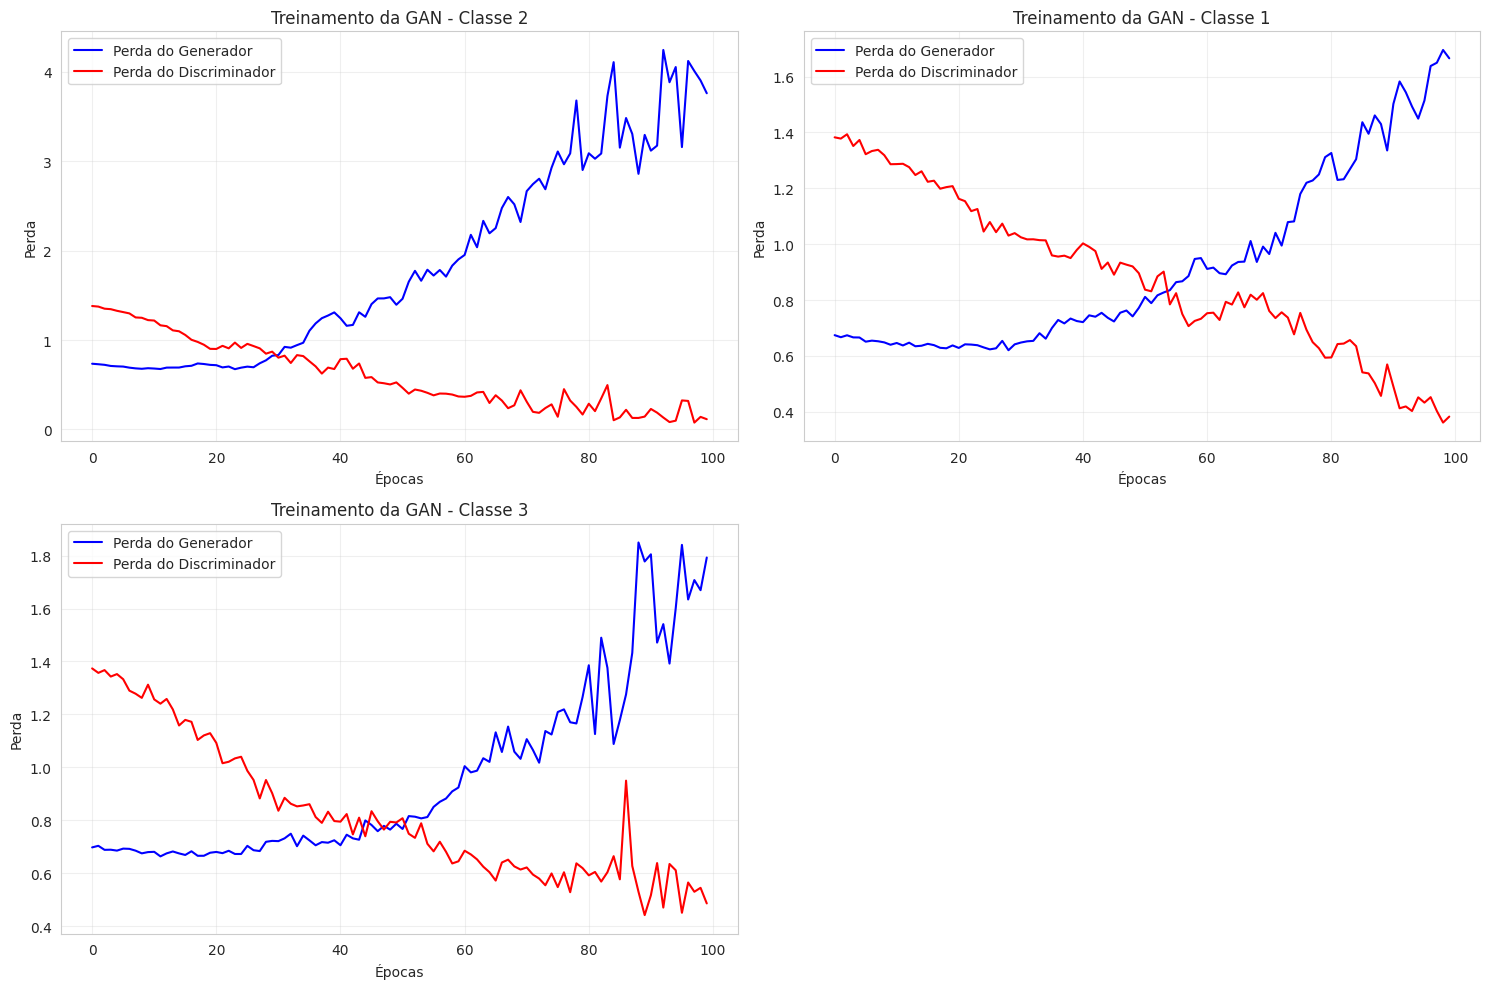

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Perda do Generador', color='blue')
    ax.plot(epochs, history['d_losses'], label='Perda do Discriminador', color='red')

    ax.set_title(f'Treinamento da GAN - Classe {class_id}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Perda')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

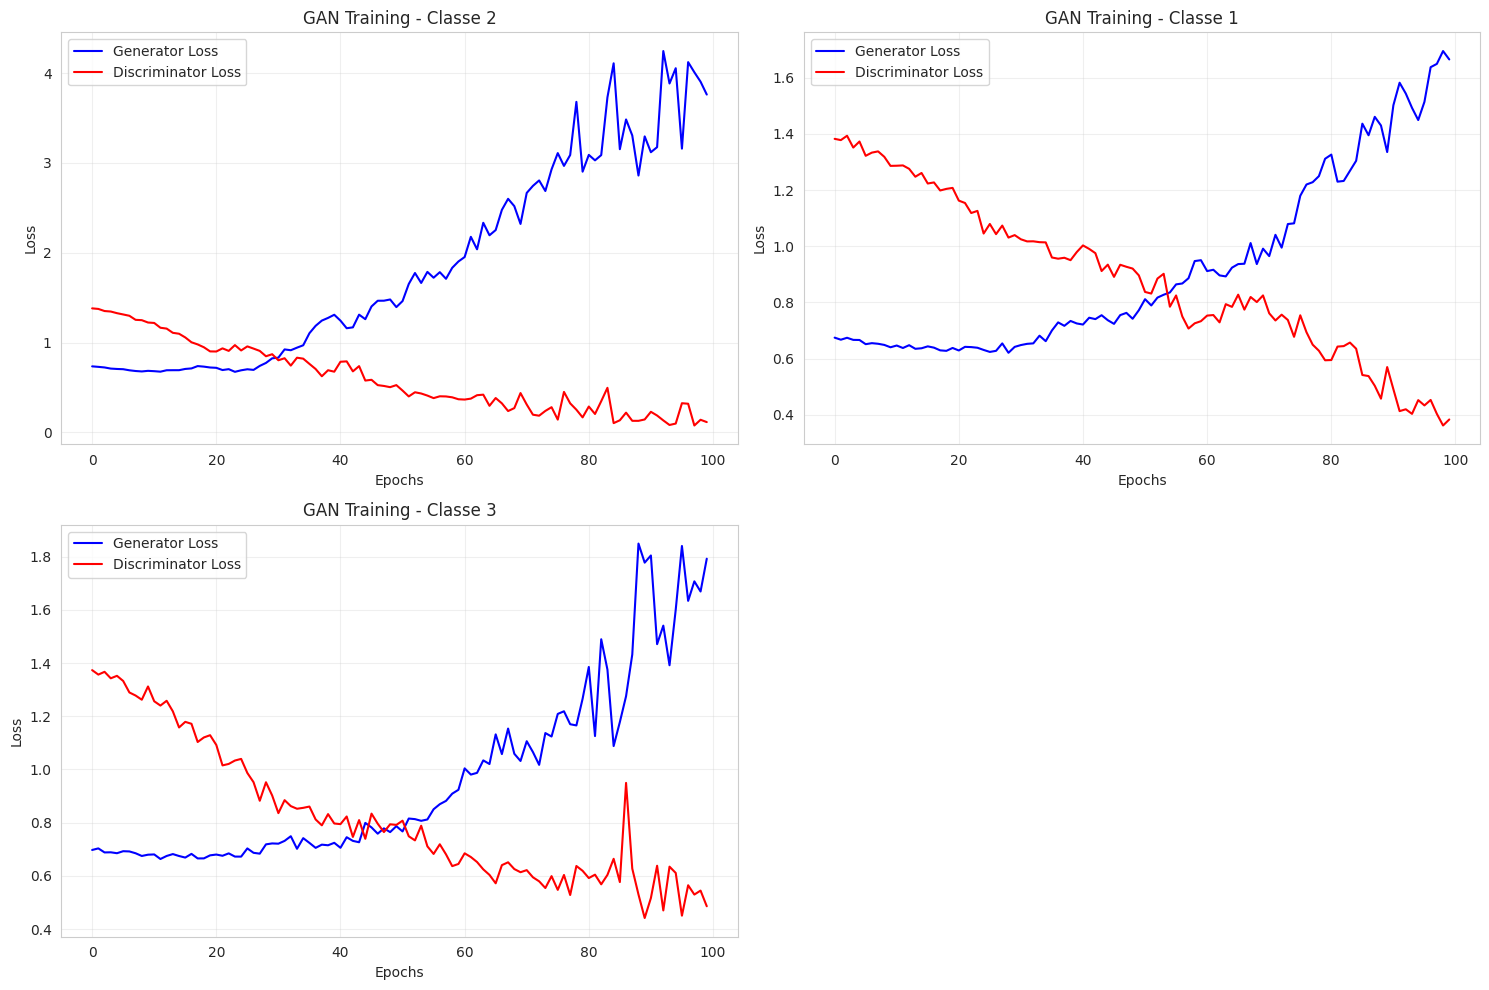

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df_gan_augmented['tokenized_words'] = df_gan_augmented['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_gan_augmented['removed_stopwords'] = df_gan_augmented['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_gan_augmented['tokenized_words_joined'] = df_gan_augmented['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

def test_model_performance_gan(data, title):
    """Testa performance do modelo com dados GAN-aumentados"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        'Naive Bayes': MultinomialNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2)
    }

    results = {}

    for model_name, model in models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro')
            }

            print(f"{model_name}:")
            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score: {results[model_name]['f1']:.4f}")

        except Exception as e:
            print(f"Erro com {model_name}: {e}")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}

    return results


df_original_processed = df_anxiety.copy()
df_original_processed['tokenized_words'] = df_original_processed['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_original_processed['removed_stopwords'] = df_original_processed['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original_processed['tokenized_words_joined'] = df_original_processed['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

results_original_gan = test_model_performance_gan(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = test_model_performance_gan(df_gan_augmented, "DADOS GAN-AUMENTADOS")


=== DADOS ORIGINAIS ===
Tamanho do dataset: 27
Naive Bayes:
  Accuracy: 0.6667
  F1-Score: 0.4000
Logistic Regression:
  Accuracy: 0.6667
  F1-Score: 0.4000
SVM:
  Accuracy: 0.8333
  F1-Score: 0.7778
Random Forest:
  Accuracy: 0.6667
  F1-Score: 0.6667

=== DADOS GAN-AUMENTADOS ===
Tamanho do dataset: 327


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Naive Bayes:
  Accuracy: 0.9394
  F1-Score: 0.9406
Logistic Regression:
  Accuracy: 0.9091
  F1-Score: 0.9117
SVM:
  Accuracy: 0.9242
  F1-Score: 0.9262
Random Forest:
  Accuracy: 0.9394
  F1-Score: 0.9389


In [ ]:
def preprocess_dataframe(df, text_column='Transcription'):
    """Aplica tokenização, remoção de stopwords e junção de tokens."""
    df_processed = df.copy()

    df_processed[text_column] = df_processed[text_column].astype(str)

    df_processed['tokenized_words'] = df_processed[text_column].apply(
        lambda x: word_tokenize(x)
    )
    df_processed['removed_stopwords'] = df_processed['tokenized_words'].apply(
        lambda x: [word for word in x if word.lower() not in stop_words]
    )
    df_processed['tokenized_words_joined'] = df_processed['removed_stopwords'].apply(
        lambda x: ' '.join(x)
    )
    return df_processed

def find_best_models_and_evaluate(data, title):
    """
    Vetoriza os dados, encontra os melhores hiperparâmetros para cada modelo via GridSearchCV
    e avalia o desempenho no conjunto de validação.
    """
    print(f"INICIANDO AVALIAÇÃO: {title}\n")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
            'params': {
              'C': [0.01, 0.1, 0.5, 1.0, 10.0],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear'],
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
              'n_estimators': [10, 50, 100, 200],
              'max_depth': [1, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
              'max_features': ['sqrt', 'log2']
            }
        },
        'SVM': {
            'model': SVC(random_state=42, class_weight='balanced', probability=True),
            'params': {
              'C': [0.01, 0.1, 1, 10],
              'gamma': ['scale', 'auto'],
              'kernel': ['linear', 'rbf']
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
              'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
              'fit_prior': [True, False]
            }
        }
    }

    results = {}
    cv_strategy = StratifiedKFold(n_splits=3)

    for model_name, config in model_configs.items():
        print(f"--- Treinando e otimizando {model_name} ---")
        try:
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=cv_strategy,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"  Melhores parâmetros: {grid_search.best_params_}")

            y_pred = best_model.predict(X_val)
            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro'),
                'best_params': grid_search.best_params_
            }

            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score (Macro): {results[model_name]['f1']:.4f}")
            print(f"  Precision: {results[model_name]['precision']:.4f}")
            print(f"  Recall: {results[model_name]['recall']:.4f}\n")

        except Exception as e:
            print(f"  ERRO com {model_name}: {e}\n")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0, 'best_params': {}}

    return results


df_original_processed = preprocess_dataframe(df_anxiety)
df_gan_augmented_processed = preprocess_dataframe(df_gan_augmented)

results_original = find_best_models_and_evaluate(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = find_best_models_and_evaluate(df_gan_augmented_processed, "DADOS GAN-AUMENTADOS")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_original.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results_gan_augmented.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")


INICIANDO AVALIAÇÃO: DADOS ORIGINAIS

Tamanho do dataset: 27
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.5, 'fit_prior': True}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS

Tamanho do dataset: 327
--- Treinando e otimizando Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
  Accuracy: 0.9242
  F1-Score (Macro): 0.9253
  Precision: 0.9297
  Recall: 0.9235

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Accuracy: 0.8939
  F1-Score (Macro): 0.8966
  Precision: 0.9222
  Recall: 0.8925

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.9545
  F1-Score (Macro): 0.9556
  Precision: 0.9615
  Recall: 0.9538

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.01, 'fit_prior': True}
  Accuracy: 0.9394
  F1-Score (Macro): 0.9408
  Precision: 0.9506
  Recall: 0.9380



=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===

Modelo: Logistic Regression
  Acurácia: 0.5000
  F1-Score: 0.2222
  Precision: 0.1667
  Recall: 0.3333

Modelo: Random Forest
  Acurácia: 0.5000
  F1-Score: 0

In [ ]:
def preprocess_dataframe(df, text_column='Transcription'):
    """Aplica tokenização, remoção de stopwords e junção de tokens."""
    df_processed = df.copy()

    df_processed[text_column] = df_processed[text_column].astype(str)

    df_processed['tokenized_words'] = df_processed[text_column].apply(
        lambda x: word_tokenize(x)
    )
    df_processed['removed_stopwords'] = df_processed['tokenized_words'].apply(
        lambda x: [word for word in x if word.lower() not in stop_words]
    )
    df_processed['tokenized_words_joined'] = df_processed['removed_stopwords'].apply(
        lambda x: ' '.join(x)
    )
    return df_processed

def run_training_pipeline(X_train_text, y_train, X_test_text, y_test, title):
    print(f"==================================================")
    print(f"INICIANDO PIPELINE: {title}")
    print(f"Treino: {len(X_train_text)} amostras | Teste: {len(X_test_text)} amostras")
    print(f"==================================================\n")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    model_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
            'params': {'C': [0.01, 0.1, 0.5, 1.0, 10.0], 'penalty': ['l1', 'l2']}
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
              'n_estimators': [10, 50, 100, 200],
              'max_depth': [1, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
              'max_features': ['sqrt', 'log2']
            },
        },
        'SVM': {
            'model': SVC(random_state=42, class_weight='balanced', probability=True),
            'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {'alpha': [0.1, 1.0], 'fit_prior': [True, False]}
        }
    }

    results = {}
    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for model_name, config in model_configs.items():
        print(f"> Otimizando {model_name}...")
        try:
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=cv_strategy,
                scoring='f1_macro',
                n_jobs=-1
            )
            grid_search.fit(X_train_vec, y_train)

            best_model = grid_search.best_estimator_

            y_pred = best_model.predict(X_test_vec)

            results[model_name] = {
                'accuracy': accuracy_score(y_test, y_pred),
                'f1': f1_score(y_test, y_pred, average='macro'),
                'precision': precision_score(y_test, y_pred, average='macro'),
                'recall': recall_score(y_test, y_pred, average='macro'),
                'best_params': grid_search.best_params_
            }
        except Exception as e:
            print(f"  ERRO com {model_name}: {e}")
            results[model_name] = None

    return results

df_original_processed = preprocess_dataframe(df_anxiety)
df_synthetic_processed = preprocess_dataframe(df_gan_augmented)

X = df_original_processed['tokenized_words_joined']
y = df_original_processed['Classificação'].astype('int')

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results_original = run_training_pipeline(
    X_train_orig, y_train_orig,
    X_test_orig, y_test_orig,
    title="BASELINE (Apenas Dados Originais)"
)

X_synth = df_synthetic_processed['tokenized_words_joined']
y_synth = df_synthetic_processed['Classificação'].astype('int')

X_train_aug = pd.concat([X_train_orig, X_synth])
y_train_aug = pd.concat([y_train_orig, y_synth])

results_augmented = run_training_pipeline(
    X_train_aug, y_train_aug,
    X_test_orig, y_test_orig,
    title="GAN AUMENTADO (Original + Sintético)"
)

def print_results(results_dict, title):
    print(f"\n=== {title} ===")
    if not results_dict: return
    for model, metrics in results_dict.items():
        if metrics:
            print(f"\nModelo: {model}")
            print(f"  Best Params: {metrics['best_params']}")
            print(f"  Acurácia:  {metrics['accuracy']:.4f}")
            print(f"  F1-Score:  {metrics['f1']:.4f}")
            print(f"  Recall:    {metrics['recall']:.4f}")

print_results(results_original, "RESULTADOS FINAIS - DADOS ORIGINAIS")
print_results(results_augmented, "RESULTADOS FINAIS - COM DATA AUGMENTATION")

INICIANDO PIPELINE: BASELINE (Apenas Dados Originais)
Treino: 21 amostras | Teste: 6 amostras

> Otimizando Logistic Regression...
> Otimizando Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

> Otimizando SVM...
> Otimizando Naive Bayes...
INICIANDO PIPELINE: GAN AUMENTADO (Original + Sintético)
Treino: 348 amostras | Teste: 6 amostras

> Otimizando Logistic Regression...
> Otimizando Random Forest...
> Otimizando SVM...
> Otimizando Naive Bayes...

=== RESULTADOS FINAIS - DADOS ORIGINAIS ===

Modelo: Logistic Regression
  Best Params: {'C': 10.0, 'penalty': 'l1'}
  Acurácia:  0.3333
  F1-Score:  0.1667
  Recall:    0.2222

Modelo: Random Forest
  Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Acurácia:  0.8333
  F1-Score:  0.6190
  Recall:    0.6667

Modelo: SVM
  Best Params: {'C': 10, 'kernel': 'linear'}
  Acurácia:  0.6667
  F1-Score:  0.4722
  Recall:    0.5000

Modelo: Naive Bayes
  Best Params: {'alpha': 1.0, 'fit_prior': False}
  Acurácia:  0.6667
  F1-Score:  0.4722
  Recall:    0.5000

=== RESULTADOS FINAIS - COM DATA AUGMENTATION ===

Modelo: Logistic Regression
  Best Params: {'C': 10.

In [ ]:
def create_comparison_df(results_original, results_augmented):
    records = []

    for model_name, metrics in results_original.items():
        record = {'model': model_name, 'condition': 'Original'}
        record.update(metrics)
        records.append(record)

    for model_name, metrics in results_augmented.items():
        record = {'model': model_name, 'condition': 'Augmented'}
        record.update(metrics)
        records.append(record)

    return pd.DataFrame(records)

In [ ]:
sample_size = 25
sample_original = df_original_processed.sample(n=sample_size, random_state=42)
sample_augmented = df_synthetic_processed.sample(n=sample_size, random_state=42)

In [ ]:
sample_original.head()

,ID,Transcription,Tag,Link,Plataform,Views / Likes,Classificação,tokenized_words,removed_stopwords,tokenized_words_joined,pos_tags,pos_tags_stopwords,Views / Likes_str,Views_Numeric
67,20,5 dores causadas pela ansiedade meu nome é Stê...,ansiedade,https://vm.tiktok.com/ZMSYbxfrM/,TikTok,277000,2,"[5, dores, causadas, pela, ansiedade, meu, nom...","[5, dores, causadas, ansiedade, nome, Stênio, ...",5 dores causadas ansiedade nome Stênio Lima ps...,"[(5, NUM), (dores, NOUN), (causadas, VERB), (p...","[(5, NUM), (dores, NOUN), (causadas, VERB), (a...",277k,277000.0
46,2,Uma Mente eu venho sentindo um vazio tão grand...,ansiedade,https://vm.tiktok.com/ZMSY4CRo3/,TikTok,184000,1,"[Uma, Mente, eu, venho, sentindo, um, vazio, t...","[Mente, venho, sentindo, vazio, tão, grande, c...",Mente venho sentindo vazio tão grande crise an...,"[(Uma, DET), (Mente, PROPN), (eu, PRON), (venh...","[(Mente, NOUN), (venho, ADJ), (sentindo, VERB)...",184k,184000.0
73,25,primeira vez que presenciei minha esposa tendo...,ansiedade,https://vm.tiktok.com/ZMSYbEUsC/,TikTok,228000,1,"[primeira, vez, que, presenciei, minha, esposa...","[primeira, vez, presenciei, esposa, tendo, cri...",primeira vez presenciei esposa tendo crise ans...,"[(primeira, ADP), (vez, NOUN), (que, SCONJ), (...","[(primeira, ADP), (vez, NOUN), (presenciei, NO...",228k,228000.0
65,18,como é que é a ansiedade o transtorno de ansie...,ansiedade,https://vm.tiktok.com/ZMSYb6ycT/,TikTok,59000,2,"[como, é, que, é, a, ansiedade, o, transtorno,...","[ansiedade, transtorno, ansiedade, doença, psí...",ansiedade transtorno ansiedade doença psíquica...,"[(como, ADV), (é, AUX), (que, SCONJ), (é, AUX)...","[(ansiedade, NOUN), (transtorno, ADJ), (ansied...",59k,59000.0
56,10,se prepara viu se preparar para que serve nada...,ansiedade,https://vm.tiktok.com/ZMSYqpGfx/,TikTok,4500000,2,"[se, prepara, viu, se, preparar, para, que, se...","[prepara, viu, preparar, serve, nada, prepara,...",prepara viu preparar serve nada prepara prepar...,"[(se, PRON), (prepara, VERB), (viu, VERB), (se...","[(prepara, VERB), (viu, VERB), (preparar, VERB...",4M,4000000.0


In [ ]:
sample_augmented.head()

,Transcription,Classificação,augmentation_type,tokenized_words,removed_stopwords,tokenized_words_joined
231,"""Você sabe que o seu sentimentos duram no máxi...",3,gan_synthetic,"[``, Você, sabe, que, o, seu, sentimentos, dur...","[``, sabe, sentimentos, duram, máximo, 90, seg...",`` sabe sentimentos duram máximo 90 segundos a...
110,"ita: ""Quando você está passando por uma crise ...",2,gan_synthetic,"[ita, :, ``, Quando, você, está, passando, por...","[ita, :, ``, passando, crise, ansiedade, comum...",ita : `` passando crise ansiedade comum vai cé...
250,"""Você sabe que o seu sentimentos duram no máxi...",3,gan_synthetic,"[``, Você, sabe, que, o, seu, sentimentos, dur...","[``, sabe, sentimentos, duram, máximo, 90, seg...",`` sabe sentimentos duram máximo 90 segundos a...
9,primeira vez que presenciei minha esposa tendo...,1,original,"[primeira, vez, que, presenciei, minha, esposa...","[primeira, vez, presenciei, esposa, tendo, cri...",primeira vez presenciei esposa tendo crise ans...
93,"ita: ""Quando você está passando por uma crise ...",2,gan_synthetic,"[ita, :, ``, Quando, você, está, passando, por...","[ita, :, ``, passando, crise, ansiedade, comum...",ita : `` passando crise ansiedade comum vai cé...


In [ ]:
sample_original['condition'] = 'Original'
sample_augmented['condition'] = 'Augmented'

comparison_df = pd.concat([sample_original, sample_augmented])

comparison_df = comparison_df[['Transcription', 'Classificação', 'augmentation_type', 'condition']]

In [ ]:
sample_size = 20
comparison_df.sample(n=sample_size, random_state=42)

comparison_df.to_csv('comparison_df.csv', index=True)

In [ ]:
from nltk.tokenize import word_tokenize
import numpy as np

def classificar_novo_texto(texto, vectorizer, model, stop_words):
    """
    Recebe um texto cru, aplica o pré-processamento, vetorização e retorna a classe prevista.
    """

    texto = str(texto)

    tokens = word_tokenize(texto)

    tokens_sem_sw = [word for word in tokens if word.lower() not in stop_words]

    texto_processado = ' '.join(tokens_sem_sw)

    texto_vetorizado = vectorizer.transform([texto_processado])

    predicao = model.predict(texto_vetorizado)

    mapa_classes = {
        1: "Experiência Pessoal",
        2: "Útil",
        3: "Enganoso"
    }

    classe_nome = mapa_classes.get(predicao[0], "Desconhecido")

    return predicao[0], classe_nome

df_final = df_gan_augmented_processed.copy()

print("Ajustando vetorizador nos dados completos...")
final_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
X_final = final_vectorizer.fit_transform(df_final['tokenized_words_joined'])
y_final = df_final['Classificação'].astype('int')

print("Treinando modelo final (Logistic Regression)...")
final_model = LogisticRegression(C=10.0, penalty='l2', solver='liblinear', random_state=42)
final_model.fit(X_final, y_final)

print("Modelo pronto para uso!")


novo_texto = "Eu sinto meu coração acelerar do nada e fico com medo de morrer, é uma sensação horrível."

classe_id, classe_nome = classificar_novo_texto(novo_texto, final_vectorizer, final_model, stop_words)

print(f"\nTexto: \"{novo_texto}\"")
print(f"Classificação Predita: {classe_id} - {classe_nome}")

# Outro exemplo
texto_util = "Para controlar a respiração, inspire contando até 4 e expire contando até 6."
classe_id2, classe_nome2 = classificar_novo_texto(texto_util, final_vectorizer, final_model, stop_words)
print(f"\nTexto: \"{texto_util}\"")
print(f"Classificação Predita: {classe_id2} - {classe_nome2}")

Ajustando vetorizador nos dados completos...
Treinando modelo final (Logistic Regression)...
Modelo pronto para uso!

Texto: "Eu sinto meu coração acelerar do nada e fico com medo de morrer, é uma sensação horrível."
Classificação Predita: 2 - Útil

Texto: "Para controlar a respiração, inspire contando até 4 e expire contando até 6."
Classificação Predita: 2 - Útil


In [ ]:
novos_textos = [
    """Se você não entende, por favor não julgue, AJUDE. O peso já é muito grande pra quem vive Crise de ansiedade é excesso Excesso de futuro excesso de pensamentos excesso de medoTodos esses excessos nos paralisam nos acelera por dentro sem nos permitir sair do lugar Ansiedade dói em excesso. Não romantize a crise de ansiedade.""",

    """A ansiedade é um sinal de sobrecarga, não de fraqueza. Ela aparece quando o corpo e a mente já estão há muito tempo tentando dar conta de tudo, e ainda assim, se cobrando por não conseguir. A culpa vem porque fomos ensinados a acreditar que sentir é um erro. Mas sentir é humano. É legítimo. E, na maior parte das vezes, é um pedido de cuidado que o corpo faz quando o limite já foi ultrapassado. Você não precisa se culpar por estar ansiosa. Precisa se acolher, com paciência, com empatia e, se possível, com ajuda profissional A ansiedade não define quem você é. Ela apenas mostra o quanto você tem tentado suportar sozinha.""",

    """Às vezes, tudo o que a gente queria era um botão pra silenciar a cabeça Mas a mente não tem “mudo” Ela fala — principalmente quando a gente tenta fugir do que sente E é por isso que a terapia é tão importante: porque ela te ensina a entender o que essas vozes estão tentando dizer, em vez de brigar com elas. Nem todo pensamento é verdade. Nem toda dor precisa virar tormenta. Com o tempo, você aprende a desacelerar por dentro — e a encontrar silêncio mesmo quando a mente grita"""
]

print(f"RESULTADOS DA CLASSIFICAÇÃO: \n")
print("-" * 60)

for i, texto in enumerate(novos_textos, 1):
    classe_id, classe_nome = classificar_novo_texto(texto, final_vectorizer, final_model, stop_words)


    print(f"Texto: {texto} \n")
    print(f"Classificação: {classe_id} ({classe_nome})")
    print("-" * 60)

RESULTADOS DA CLASSIFICAÇÃO: 

------------------------------------------------------------
Texto: Se você não entende, por favor não julgue, AJUDE. O peso já é muito grande pra quem vive Crise de ansiedade é excesso Excesso de futuro excesso de pensamentos excesso de medoTodos esses excessos nos paralisam nos acelera por dentro sem nos permitir sair do lugar Ansiedade dói em excesso. Não romantize a crise de ansiedade. 

Classificação: 2 (Útil)
------------------------------------------------------------
Texto: A ansiedade é um sinal de sobrecarga, não de fraqueza. Ela aparece quando o corpo e a mente já estão há muito tempo tentando dar conta de tudo, e ainda assim, se cobrando por não conseguir. A culpa vem porque fomos ensinados a acreditar que sentir é um erro. Mas sentir é humano. É legítimo. E, na maior parte das vezes, é um pedido de cuidado que o corpo faz quando o limite já foi ultrapassado. Você não precisa se culpar por estar ansiosa. Precisa se acolher, com paciência, com 

### Plots

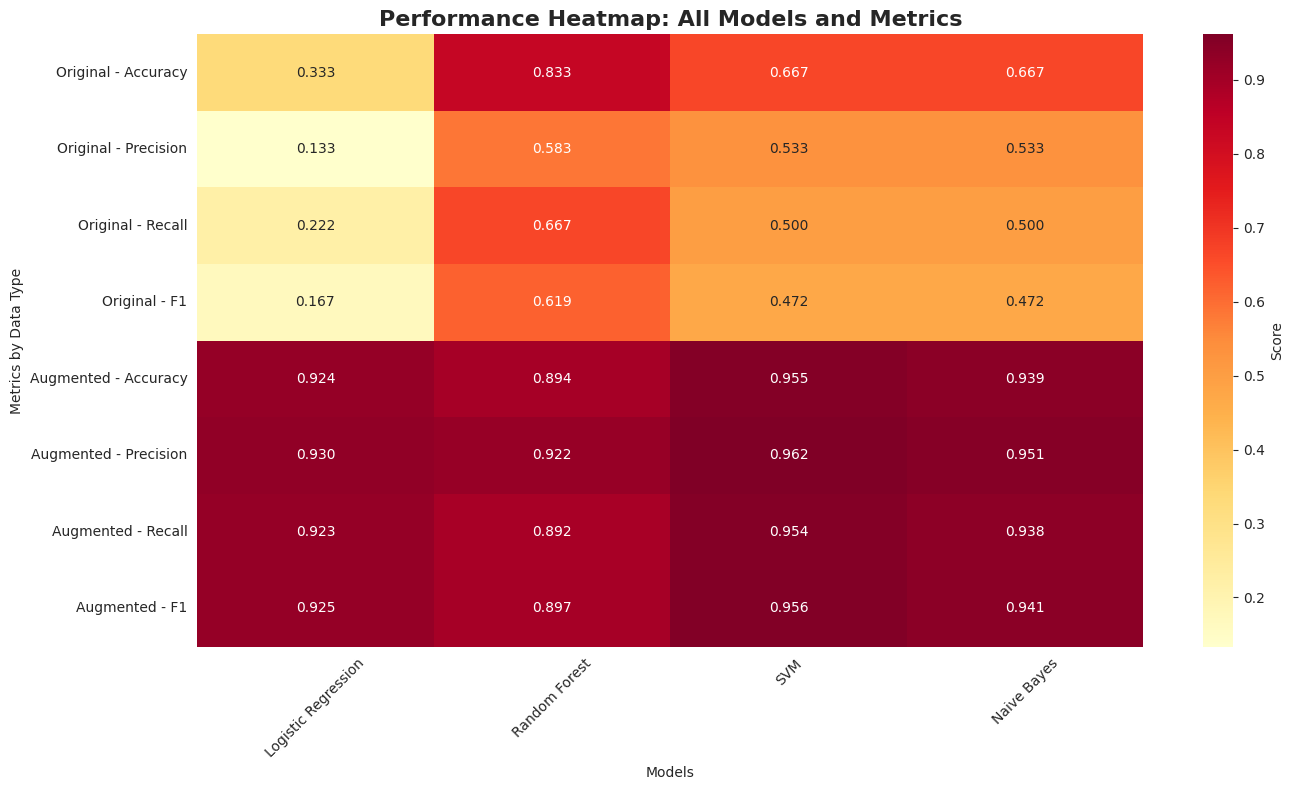

In [ ]:
comparison_df = create_comparison_df(results_original, results_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
metrics = ['accuracy', 'precision', 'recall', 'f1']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Score'})

plt.title('Performance Heatmap: All Models and Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Metrics by Data Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

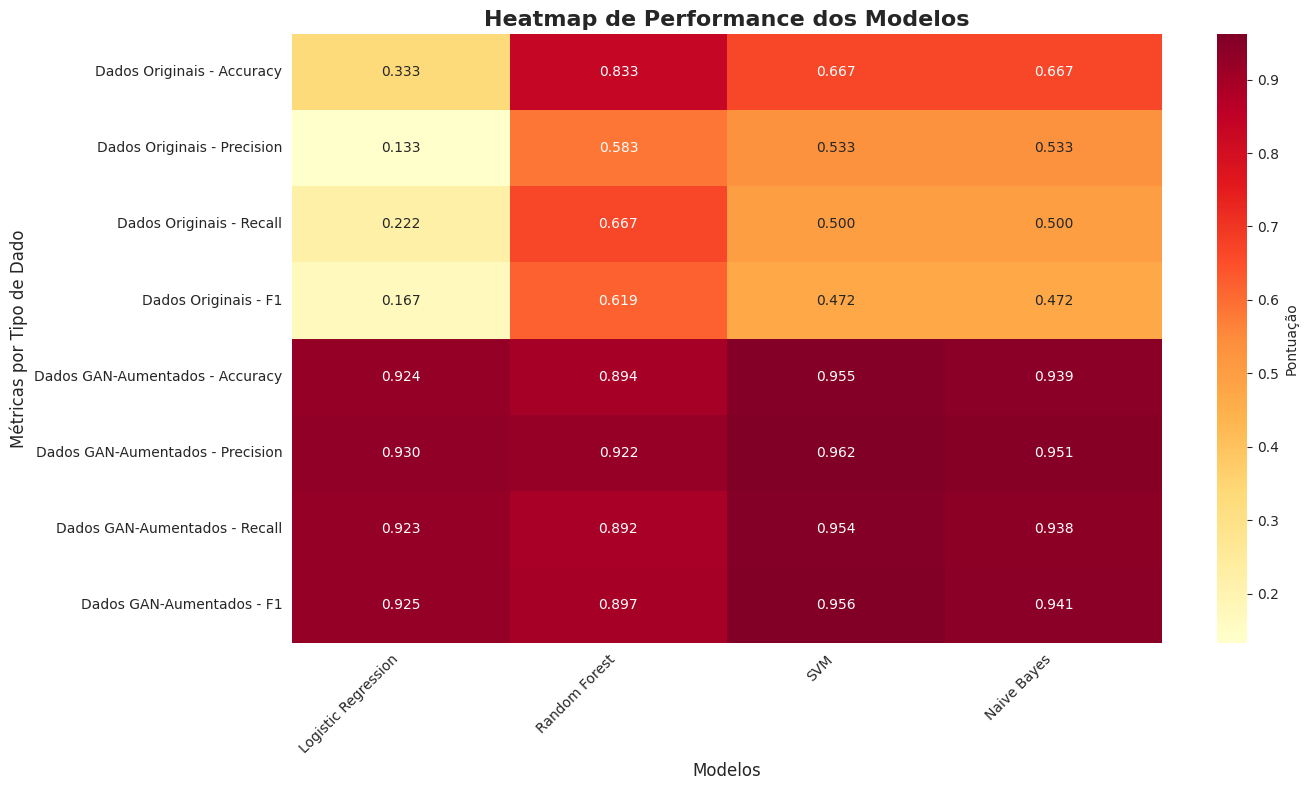

In [ ]:
comparison_df = create_comparison_df(results_original, results_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
conditions_br = ['Dados Originais', 'Dados GAN-Aumentados']
metrics = ['accuracy', 'precision', 'recall', 'f1']
metrics_labels_pt = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions_br for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Pontuação'})

plt.title('Heatmap de Performance dos Modelos', fontsize=16, fontweight='bold')
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Métricas por Tipo de Dado', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [ ]:
def plot_class_distribution(data, title):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimensão 1': X_embedded[:, 0],
        'Dimensão 2': X_embedded[:, 1],
        'Classe': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimensão 1',
        y='Dimensão 2',
        hue='Classe',
        style='Classe',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Distribuição das Classes ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("Componente t-SNE 1", fontsize=12)
    plt.ylabel("Componente t-SNE 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


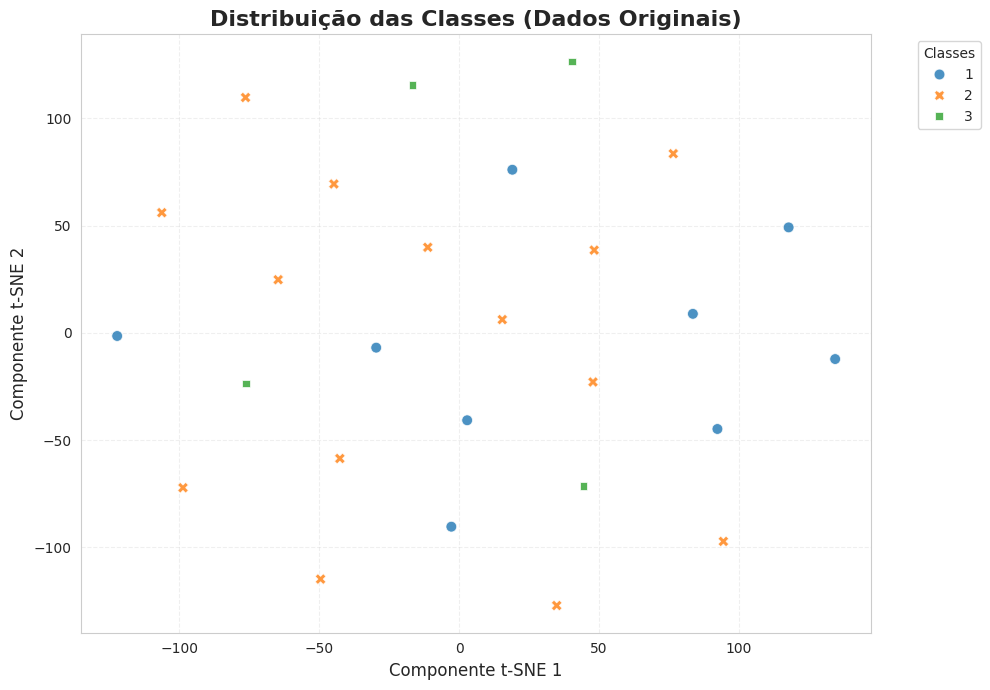

In [ ]:
plot_class_distribution(df_original_processed, "Dados Originais")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


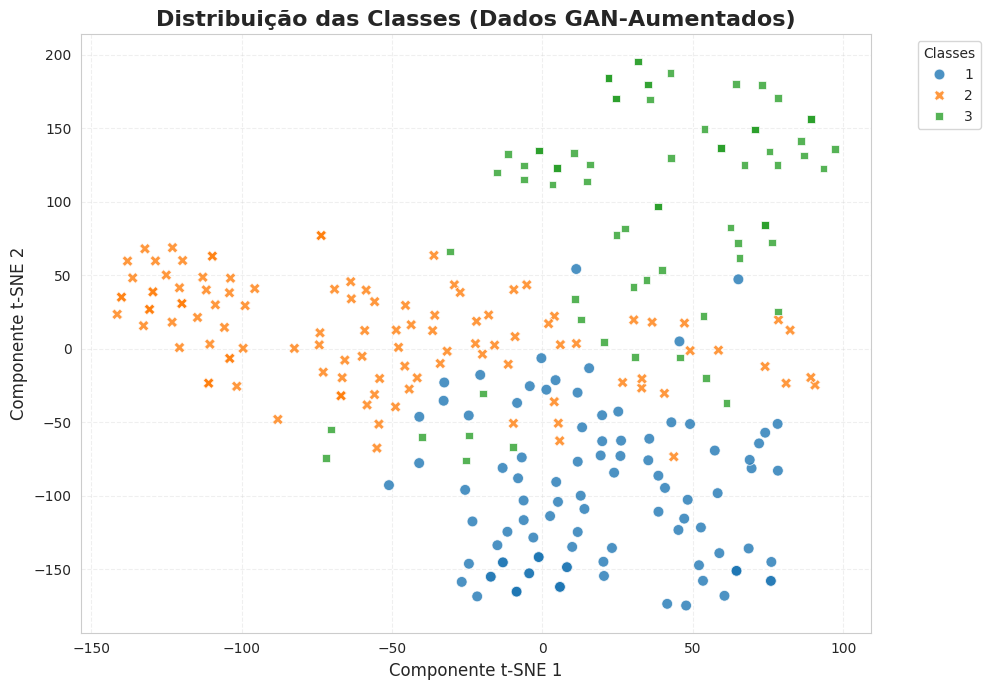

In [ ]:
plot_class_distribution(df_gan_augmented, "Dados GAN-Aumentados")

In [ ]:
def plot_class_distribution(data, title):
    # Vectorize the text data using TF-IDF
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimension 1': X_embedded[:, 0],
        'Dimension 2': X_embedded[:, 1],
        'Class': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimension 1',
        y='Dimension 2',
        hue='Class',
        style='Class',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Class Distribution ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("t-SNE 1 Component", fontsize=12)
    plt.ylabel("t-SNE 2 Component", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


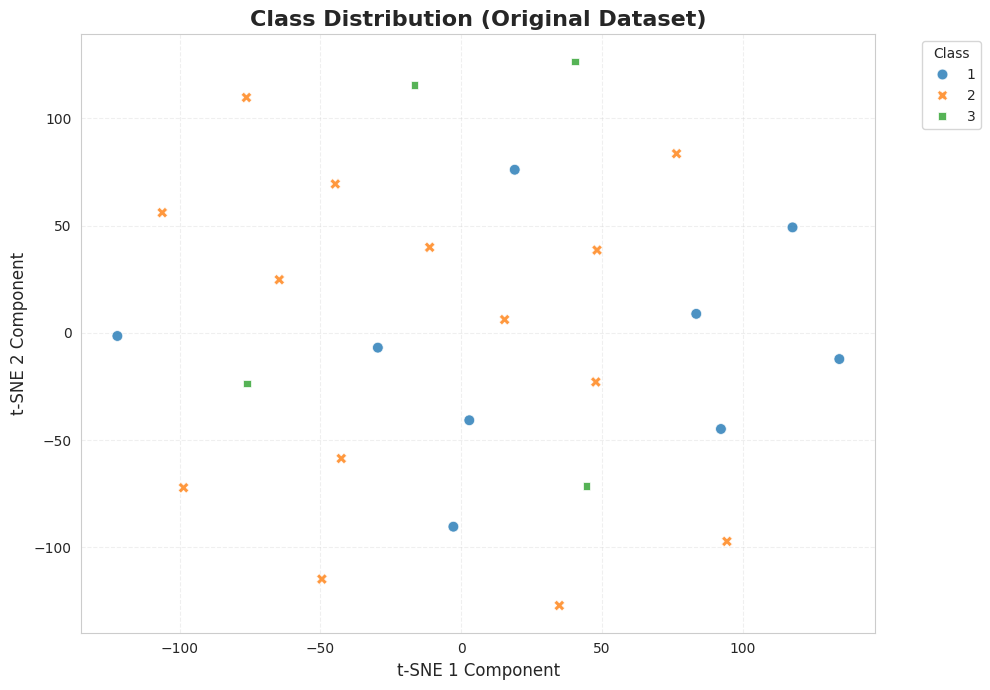

In [ ]:
plot_class_distribution(df_original_processed, "Original Dataset")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


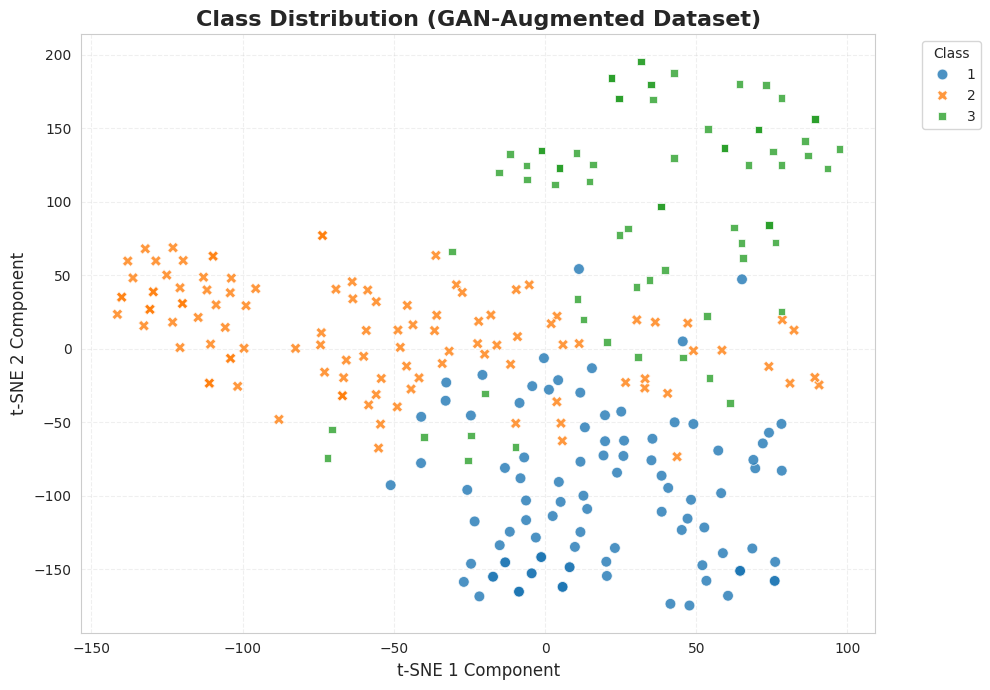

In [ ]:
plot_class_distribution(df_gan_augmented, "GAN-Augmented Dataset")

# Depression

## Pre processing

In [ ]:
!python -m spacy download pt_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 104.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
df_depression = pd.read_csv("/content/depression.csv")
df_depression.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


,ID,Transcription,Tag,Link,Platform,Views / Likes,Classificação
0,0,mudo fala nome de seis rapariga que não vale n...,depressao,https://www.instagram.com/reel/C9PzOaIO0-y/?ig...,instagram,131334.0,NÃO INCLUSO
1,1,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,EXPERIÊNCIA PESSOAL
2,2,então eu oriento aos casados namorem sexo três...,depressao,https://www.instagram.com/reel/CiddsJHgFKl/?ig...,instagram,6242282.0,NÃO INCLUSO
3,3,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,OUTRA
4,4,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,OUTRA


In [ ]:
df_depression['Classificação'].unique()

array(['NÃO INCLUSO', 'EXPERIÊNCIA PESSOAL', 'OUTRA', 'TDAH', 'REPETIDO',
       'ÚTIL', 'TOD', 'SUICÍDIO', 'INDISPONÍVEL'], dtype=object)

In [ ]:
# Using one hot encoding
dictionary = dict({
    "experiência pessoal": 1,
    "útil": 2,
    "enganoso": 3,
    "outra": 4,
    "excluído (espanhol/Inglês)": 5
})

# Replacing in Classifier column and removing blank spaces in the end
df_depression['Classificação'] = df_depression['Classificação'].str.rstrip()
# Change to lower case
df_depression['Classificação'] = df_depression['Classificação'].str.lower()
# Converting to one hot encoding
df_depression['Classificação'] = df_depression['Classificação'].replace(dictionary)
df_depression = df_depression[~df_depression['Classificação'].apply(lambda x: isinstance(x, str))]

#Remove rows with 4 value
df_depression = df_depression[df_depression['Classificação'] != 5]
df_depression.head()

,ID,Transcription,Tag,Link,Platform,Views / Likes,Classificação
1,1,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1
3,3,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4
4,4,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,4
5,5,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4
11,11,Richard Happy teste de armas,depressao,https://www.instagram.com/reel/C7jrX1DsbV9/?ig...,instagram,535983.0,4


In [ ]:
sent_tokenize(df_depression['Transcription'].iloc[0])
df_depression['tokenized_words'] = df_depression['Transcription'].apply(lambda x: word_tokenize(x))

stop_words = set(stopwords.words('portuguese'))
df_depression['removed_stopwords'] = df_depression['tokenized_words'].apply(lambda x: [word for word in x if word.lower() not in stop_words])
df_depression.head()

,ID,Transcription,Tag,Link,Platform,Views / Likes,Classificação,tokenized_words,removed_stopwords
1,1,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1,"[depressão, é, foda, né, Eu, tive, um, princíp...","[depressão, foda, né, princípio, foda, coisa, ..."
3,3,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4,"[esse, aqui, é, o, Uno, é, o, Uno, a, lenda, v...","[aqui, Uno, Uno, lenda, viva, aqui, melhor, ca..."
4,4,melhor psiquiatra que tem é o exercício físico...,depressao,https://www.instagram.com/reel/Cz3Yw-IuYl6/?ig...,instagram,261871.0,4,"[melhor, psiquiatra, que, tem, é, o, exercício...","[melhor, psiquiatra, exercício, físico, pera, ..."
5,5,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4,"[Não, Chora, não, chora, não, chora, não, chora]","[Chora, chora, chora, chora]"
11,11,Richard Happy teste de armas,depressao,https://www.instagram.com/reel/C7jrX1DsbV9/?ig...,instagram,535983.0,4,"[Richard, Happy, teste, de, armas]","[Richard, Happy, teste, armas]"


In [ ]:
vectorizer = TfidfVectorizer()
df_depression['tokenized_words_joined'] = df_depression['removed_stopwords'].apply(lambda x: ' '.join(x))
X = vectorizer.fit_transform(df_depression['tokenized_words_joined'])
df_depression['Classificação'] = df_depression['Classificação'].astype('int')
y = df_depression['Classificação']

In [ ]:
nlp = spacy.load('pt_core_news_sm')

def aplicar_pos_tagging_spacy(texto):
    if not isinstance(texto, str):
        return []

    doc = nlp(texto)

    return [(token.text, token.pos_) for token in doc]


df_depression['pos_tags'] = df_depression['Transcription'].apply(aplicar_pos_tagging_spacy)

In [ ]:
def pos_tag_de_lista_de_palavras(lista_de_palavras: list) -> list:
    if not isinstance(lista_de_palavras, list):
        return []

    texto = " ".join(lista_de_palavras)

    doc = nlp(texto)

    return [(token.text, token.pos_) for token in doc if not token.is_punct]

df_depression['pos_tags_stopwords'] = df_depression['removed_stopwords'].apply(pos_tag_de_lista_de_palavras)

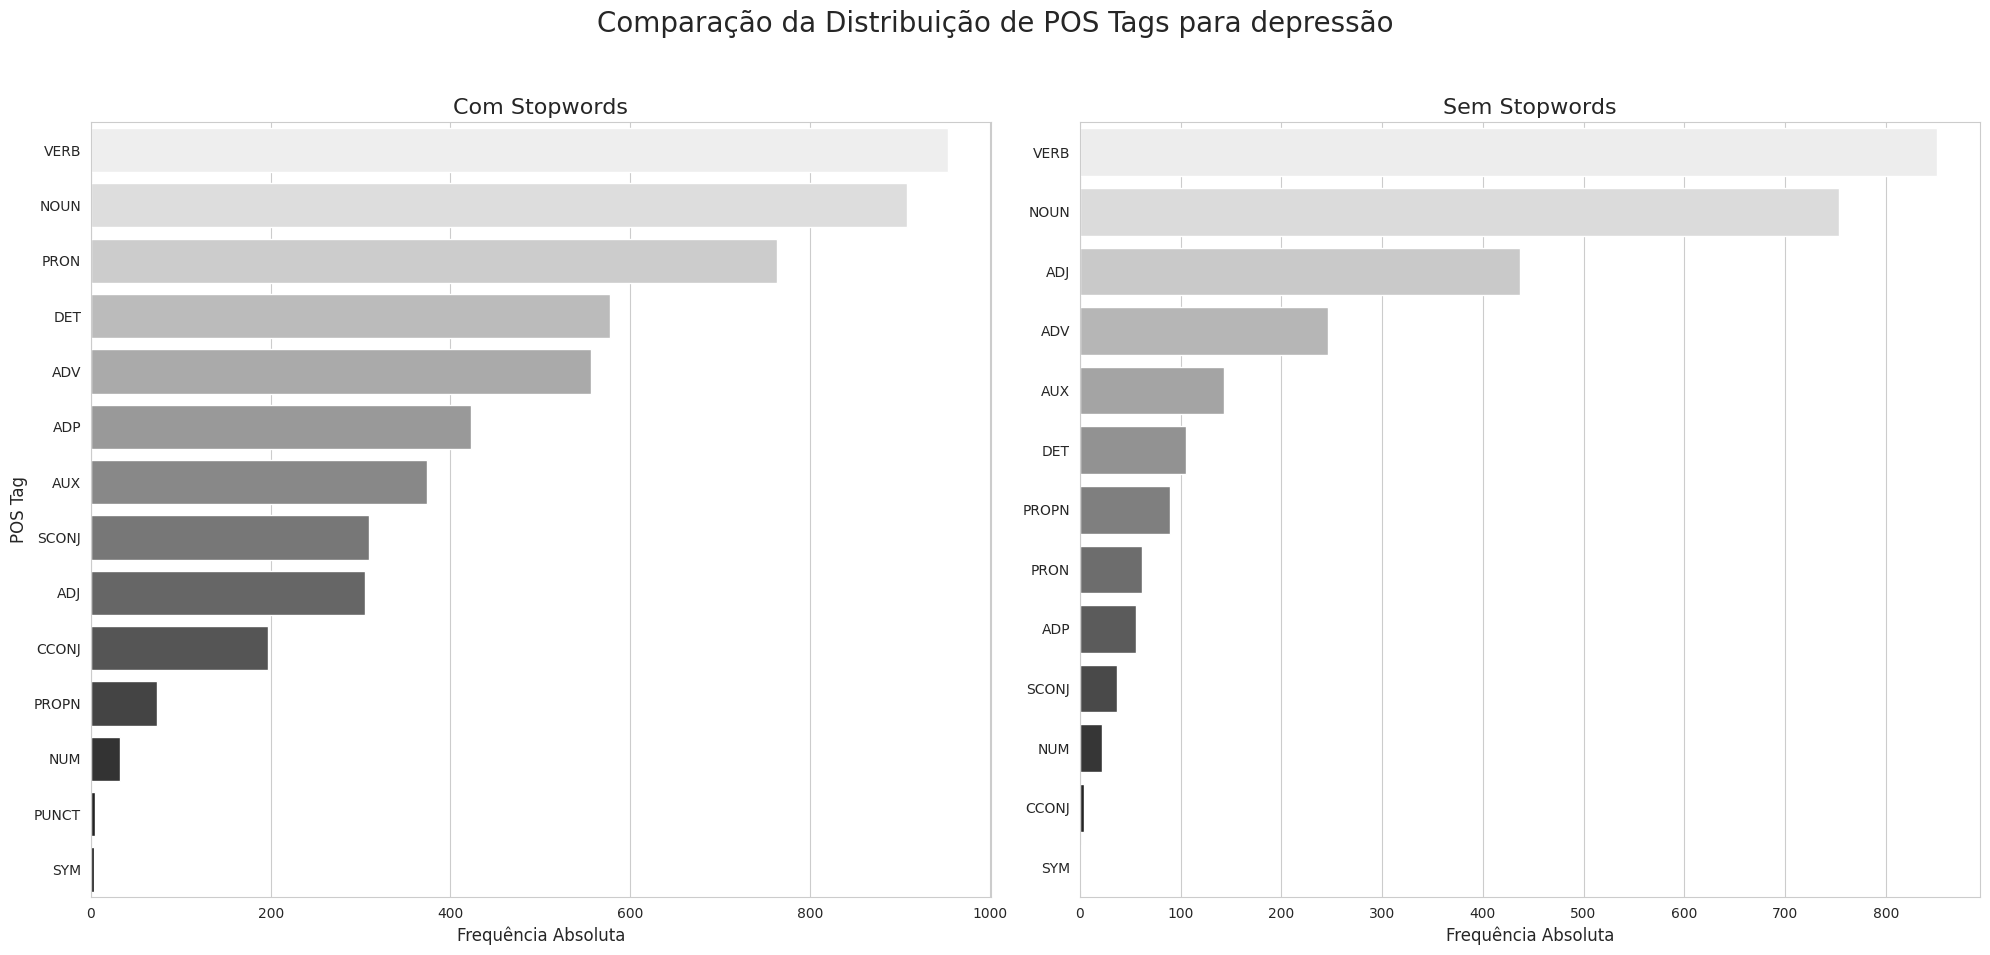

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_depression['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_depression['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparação da Distribuição de POS Tags para depressão', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('Com Stopwords', fontsize=16)
axes[0].set_xlabel('Frequência Absoluta', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Frequência Absoluta', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

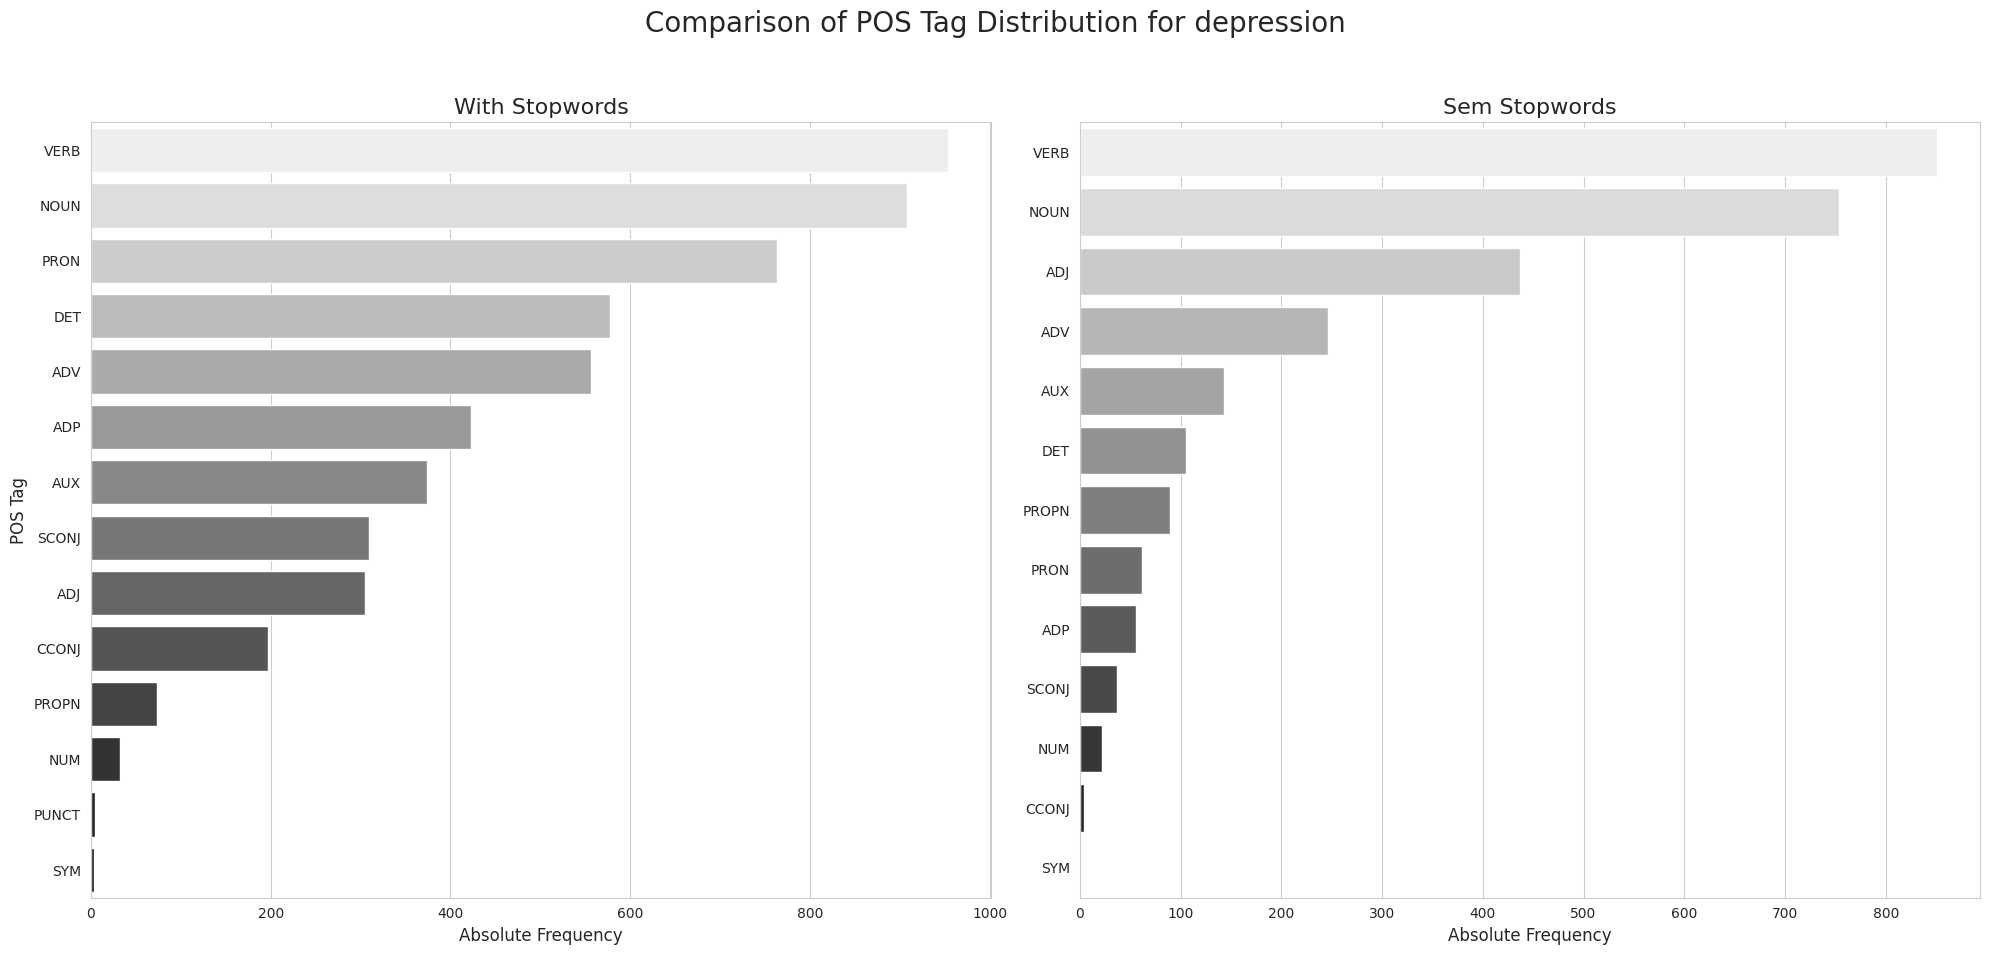

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_depression['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_depression['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparison of POS Tag Distribution for depression', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('With Stopwords', fontsize=16)
axes[0].set_xlabel('Absolute Frequency', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Absolute Frequency', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

In [ ]:
try:
  df_depression['Views / Likes'] = df_depression['Views / Likes'].str.replace('.', '', regex=False)
  df_depression['Views / Likes'] = df_depression['Views / Likes'].astype(int)
except Exception as e:
  print(e)
df_depression['ID'] = np.arange(len(df_depression))

df_depression = df_depression.sort_values(by='Views / Likes', ascending=False)

Can only use .str accessor with string values!


In [ ]:
def format_views(x):
    if x >= 1000000:
        return f'{x//1_000_000}M'
    elif x >= 1000:
        return f'{x//1000}k'
    else:
        return str(x)

df_depression['Views / Likes_str'] = df_depression['Views / Likes'].apply(format_views)

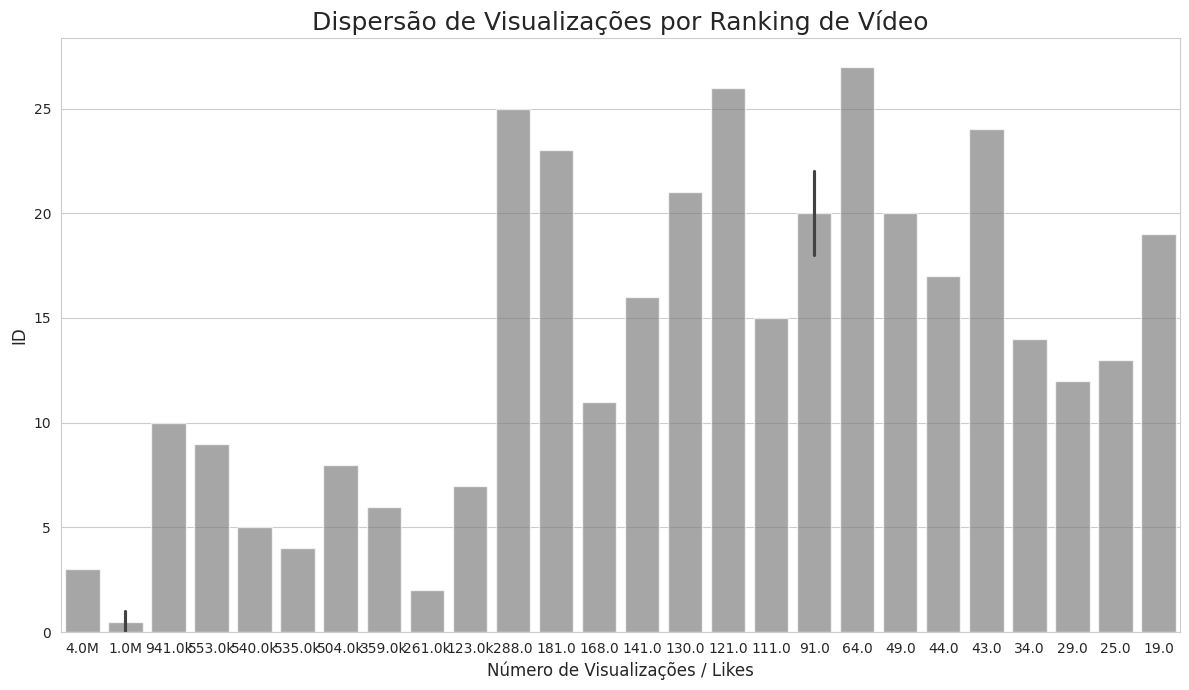

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    x='Views / Likes_str',
    y='ID',
    data=df_depression,
    color='gray',
    alpha=0.7
)

plt.title('Dispersão de Visualizações por Ranking de Vídeo', fontsize=18)
plt.xlabel('Número de Visualizações / Likes', fontsize=12)
plt.ylabel('ID', fontsize=12)

plt.tight_layout()
plt.show()

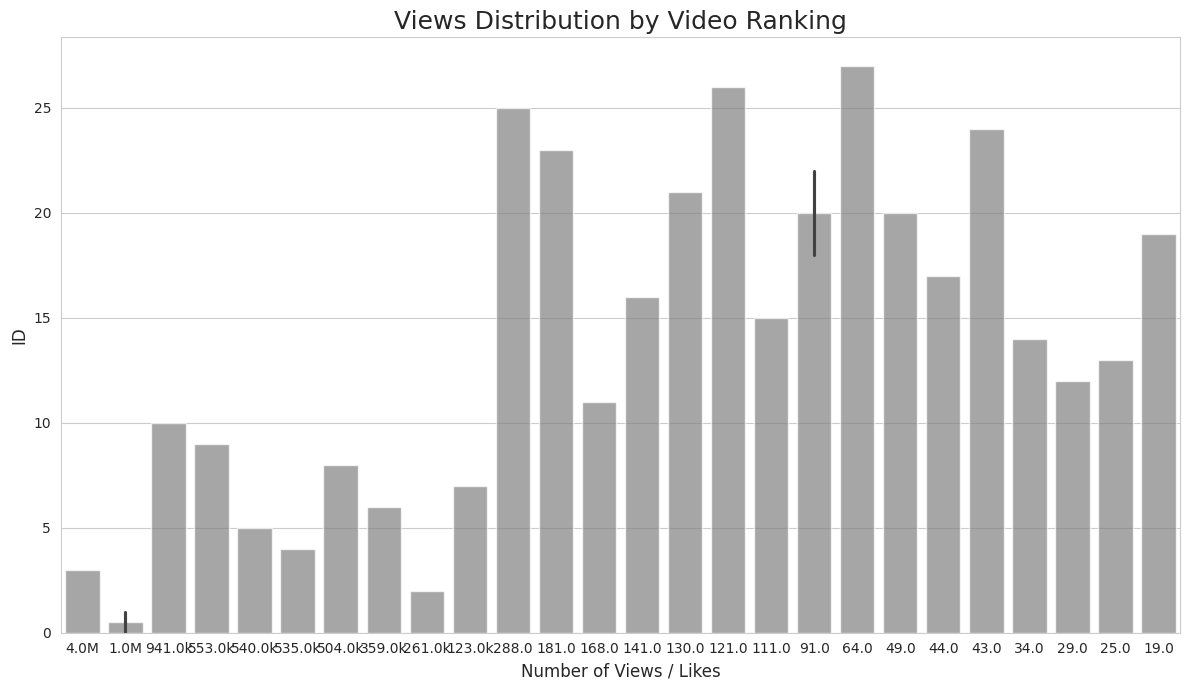

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    x='Views / Likes_str',
    y='ID',
    data=df_depression,
    color='gray',
    alpha=0.7
)

plt.title('Views Distribution by Video Ranking', fontsize=18)
plt.xlabel('Number of Views / Likes', fontsize=12)
plt.ylabel('ID', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
texts_by_class = {}
for class_id in df_depression['Classificação'].unique():
    class_texts = df_depression[df_depression['Classificação'] == class_id]['Transcription'].tolist()
    texts_by_class[class_id] = class_texts
    print(f"Classe {class_id}: {len(class_texts)} textos")

Classe 4: 13 textos
Classe 1: 11 textos
Classe 2: 4 textos


In [ ]:
def convert_views_to_numeric(view_str):
    view_str = str(view_str).strip().upper()
    if 'M' in view_str:
        return float(view_str.replace('M', '')) * 1_000_000
    if 'K' in view_str:
        return float(view_str.replace('K', '')) * 1_000
    try:
        return float(view_str)
    except (ValueError, TypeError):
        return pd.NA

df_depression['Views_Numeric'] = df_depression['Views / Likes_str'].apply(convert_views_to_numeric)

df_plot_depression = df_depression.sort_values('Views_Numeric', ascending=False).reset_index(drop=True)

df_plot_depression['Ranking'] = df_plot_depression.index + 1

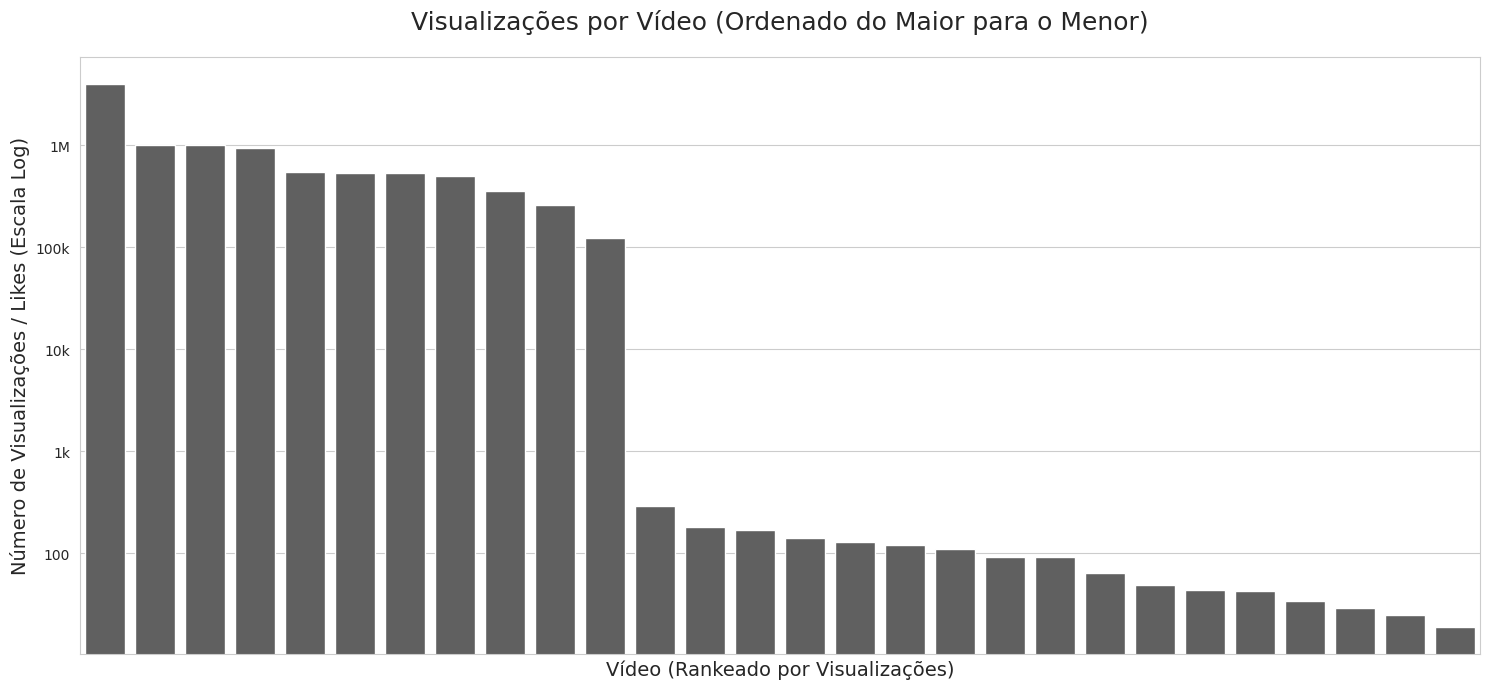

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

barplot = sns.barplot(
    data=df_plot_depression,
    x='Ranking',
    y='Views_Numeric',
    color='#606060'
)

plt.yscale('log')

plt.title('Visualizações por Vídeo (Ordenado do Maior para o Menor)', fontsize=18, pad=20)
plt.xlabel('Vídeo (Rankeado por Visualizações)', fontsize=14)
plt.ylabel('Número de Visualizações / Likes (Escala Log)', fontsize=14)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda y, pos: f'{y/1_000_000:.0f}M' if y >= 1_000_000 else (f'{y/1_000:.0f}k' if y >= 1_000 else f'{y:.0f}'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks([])

plt.tight_layout()
plt.show()

## Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from transformers import AutoTokenizer, AutoModel
import random
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from nltk.tokenize import word_tokenize
import pandas as pd

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [ ]:
import torch
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [ ]:
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
embedding_model = AutoModel.from_pretrained(model_name)

In [ ]:
def get_text_embeddings(texts, batch_size=32, max_length=128, device='cpu'):
    """Converte textos em embeddings usando BERT em modo batch."""
    all_embeddings = []
    embedding_model.to(device)

    for i in tqdm(range(0, len(texts), batch_size), desc="Gerando Embeddings"):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = embedding_model(**inputs)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

print("Gerando embeddings...")
embeddings_by_class = {}
for class_id, texts in texts_by_class.items():
    print(f"Processando classe {class_id}...")
    embeddings = get_text_embeddings(texts[:100])
    embeddings_by_class[class_id] = embeddings
    print(f"  Shape: {embeddings.shape}")

class Generator(nn.Module):
    """Gerador da GAN para criar embeddings sintéticos"""
    def __init__(self, noise_dim=100, embedding_dim=768, hidden_dim=512):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim, embedding_dim),
            nn.Tanh()  # Normalizar saída
        )

    def forward(self, noise):
        return self.model(noise)

class Discriminator(nn.Module):
    """Discriminador da GAN para distinguir embeddings reais de sintéticos"""
    def __init__(self, embedding_dim=768, hidden_dim=512):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(embedding_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, embedding):
        return self.model(embedding)


def train_gan_for_class(embeddings, epochs=100, batch_size=16, noise_dim=100, device='cpu'): # 1. Adicionar 'device' como parâmetro
    """Treina uma GAN para uma classe específica no dispositivo correto."""

    if len(embeddings) < batch_size:
        print(f"Poucos dados ({len(embeddings)}), ajustando batch_size para {len(embeddings)}")
        batch_size = len(embeddings)

    embedding_dim = embeddings.shape[1]

    generator = Generator(noise_dim, embedding_dim).to(device)
    discriminator = Discriminator(embedding_dim).to(device)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    real_embeddings = torch.FloatTensor(embeddings).to(device)

    g_losses, d_losses = [], []
    print(f"Iniciando treinamento com {len(embeddings)} amostras")

    for epoch in range(epochs):
        indices = torch.randperm(len(real_embeddings))
        epoch_g_loss, epoch_d_loss, num_batches = 0, 0, 0

        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            real_batch = real_embeddings[batch_indices]
            batch_len = len(real_batch)

            if batch_len <= 1:
              continue

            real_labels = torch.ones(batch_len, 1).to(device)
            fake_labels = torch.zeros(batch_len, 1).to(device)

            # --- Treinar Discriminador ---
            d_optimizer.zero_grad()
            d_real_loss = criterion(discriminator(real_batch), real_labels)

            noise = torch.randn(batch_len, noise_dim).to(device)
            with torch.no_grad():
                fake_batch = generator(noise)
            d_fake_loss = criterion(discriminator(fake_batch), fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()

            # --- Treinar Gerador ---
            g_optimizer.zero_grad()
            noise = torch.randn(batch_len, noise_dim).to(device)
            fake_batch = generator(noise)
            g_loss = criterion(discriminator(fake_batch), real_labels)

            g_loss.backward()
            g_optimizer.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1

        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}")

    return generator, discriminator, g_losses, d_losses

scalers_by_class = {}
scaled_embeddings_by_class = {}

for class_id, embeddings in embeddings_by_class.items():
    if len(embeddings) < 3:
        print(f"Classe {class_id} tem dados insuficientes para normalização, pulando.")
        continue

    scaler = StandardScaler()

    scaled_embeddings = scaler.fit_transform(embeddings)

    scalers_by_class[class_id] = scaler
    scaled_embeddings_by_class[class_id] = scaled_embeddings


generators = {}
discriminators = {}
training_histories = {}

for class_id, scaled_embeddings in scaled_embeddings_by_class.items():
    print(f"\nTREINANDO GAN PARA CLASSE {class_id}")

    try:
        generator, discriminator, g_losses, d_losses = train_gan_for_class(
            scaled_embeddings,
            epochs=100,
            batch_size=8,
            device=device
        )

        generators[class_id] = generator
        discriminators[class_id] = discriminator
        training_histories[class_id] = {'g_losses': g_losses, 'd_losses': d_losses}

        print(f"GAN treinada para classe {class_id}")

    except Exception as e:
        print(f"Erro ao treinar GAN para classe {class_id}: {e}")

def generate_and_rescale_embeddings(generator, scaler, num_samples=50, noise_dim=100, device='cpu'):
    """Gera embeddings sintéticos e os retorna para a escala original."""
    generator.eval()
    generator.to(device)

    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim).to(device)
        synthetic_embeddings_scaled = generator(noise)

        synthetic_embeddings_scaled = synthetic_embeddings_scaled.cpu().numpy()

    synthetic_embeddings_original_scale = scaler.inverse_transform(synthetic_embeddings_scaled)

    return synthetic_embeddings_original_scale

synthetic_embeddings_by_class = {}

for class_id, generator in generators.items():
    print(f"\nGerando embeddings sintéticos para classe {class_id}")

    scaler = scalers_by_class[class_id]

    original_count = len(embeddings_by_class[class_id])
    target_count = max(100, original_count * 3)

    final_synthetic_embeddings = generate_and_rescale_embeddings(
        generator,
        scaler,
        num_samples=target_count,
        device=device
    )

    synthetic_embeddings_by_class[class_id] = final_synthetic_embeddings

    print(f"  Originais: {original_count}, Sintéticos gerados: {len(final_synthetic_embeddings)}")
    print(f"  Média dos embeddings sintéticos (escala original): {final_synthetic_embeddings.mean():.2f}")

Gerando embeddings...
Processando classe 4...


Gerando Embeddings: 100%|██████████| 1/1 [00:11<00:00, 11.60s/it]


  Shape: (13, 768)
Processando classe 1...


Gerando Embeddings: 100%|██████████| 1/1 [00:08<00:00,  8.74s/it]


  Shape: (11, 768)
Processando classe 2...


Gerando Embeddings: 100%|██████████| 1/1 [00:03<00:00,  3.22s/it]


  Shape: (4, 768)

TREINANDO GAN PARA CLASSE 4
Iniciando treinamento com 13 amostras
Epoch 0: G_Loss = 0.6661, D_Loss = 1.4039
Epoch 20: G_Loss = 0.6469, D_Loss = 1.0055
Epoch 40: G_Loss = 1.1361, D_Loss = 0.6646
Epoch 60: G_Loss = 1.7941, D_Loss = 0.3917
Epoch 80: G_Loss = 3.0091, D_Loss = 0.1555
GAN treinada para classe 4

TREINANDO GAN PARA CLASSE 1
Iniciando treinamento com 11 amostras
Epoch 0: G_Loss = 0.6851, D_Loss = 1.3781
Epoch 20: G_Loss = 0.6668, D_Loss = 0.9612
Epoch 40: G_Loss = 0.9820, D_Loss = 0.6867
Epoch 60: G_Loss = 1.6445, D_Loss = 0.4286
Epoch 80: G_Loss = 2.7611, D_Loss = 0.2046
GAN treinada para classe 1

TREINANDO GAN PARA CLASSE 2
Poucos dados (4), ajustando batch_size para 4
Iniciando treinamento com 4 amostras
Epoch 0: G_Loss = 0.6977, D_Loss = 1.3966
Epoch 20: G_Loss = 0.6580, D_Loss = 1.0534
Epoch 40: G_Loss = 0.7251, D_Loss = 0.8062
Epoch 60: G_Loss = 0.9501, D_Loss = 0.6889
Epoch 80: G_Loss = 1.1354, D_Loss = 0.5032
GAN treinada para classe 2

Gerando embe

In [ ]:
from transformers import pipeline
import torch
from tqdm import tqdm
import random
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model_name = "bigscience/bloomz-1b1"
generator_pipeline = pipeline('text-generation', model=model_name, device=0 if torch.cuda.is_available() else -1)

Device set to use cuda:0


## Generate synthetic text using cosine similarity

Processando classe 4...


Gerando Embeddings: 100%|██████████| 1/1 [00:05<00:00,  5.83s/it]


  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:07<00:00,  7.00s/it]


  Processados 60/100


...

  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


  Processados 60/100


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


  Gerados 100 textos sintéticos
Dataset original: 28 amostras
Dataset aumentado com GANs: 328 amostras
Aumento: 1071.4%

Distribuição das classes no dataset GAN-aumentado:
Classificação
4    113
1    111
2    104
Name: count, dtype: int64


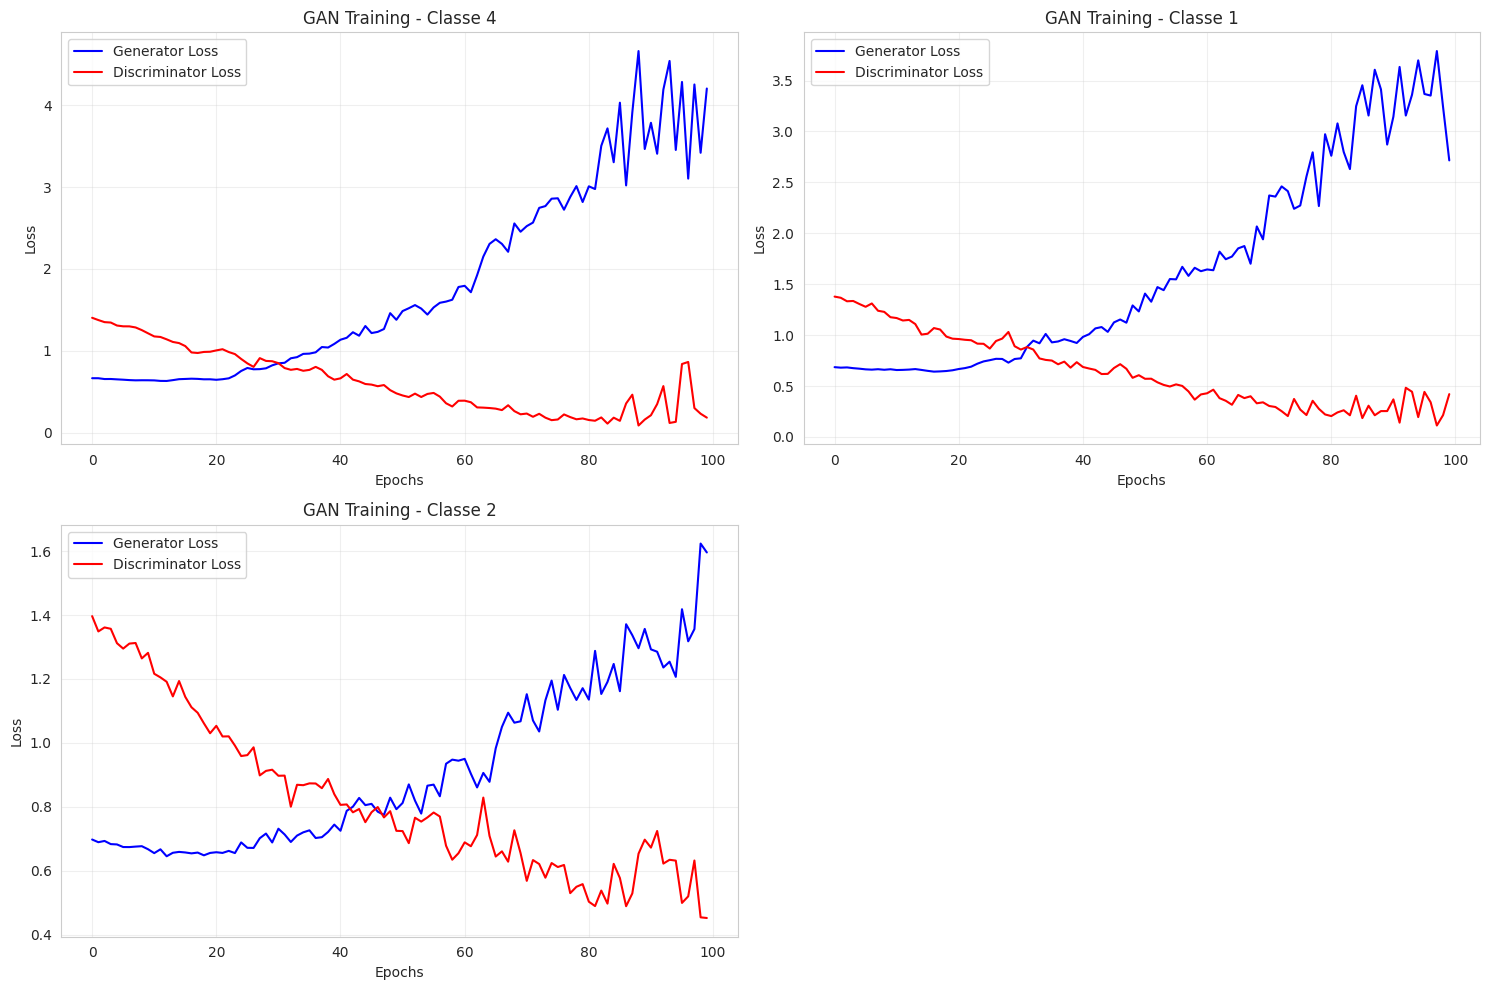

In [ ]:
def embedding_to_text_simple(embedding, original_texts, similarity_threshold=0.7):
    """
    Converte embedding sintético em texto usando similaridade com textos originais.
    """
    original_embeddings = get_text_embeddings(original_texts[:20])

    similarities = []
    for orig_emb in original_embeddings:
        similarity = np.dot(embedding, orig_emb) / (np.linalg.norm(embedding) * np.linalg.norm(orig_emb))
        similarities.append(similarity)

    most_similar_idx = np.argmax(similarities)
    most_similar_text = original_texts[most_similar_idx]
    max_similarity = similarities[most_similar_idx]

    if max_similarity < similarity_threshold:
        words = most_similar_text.split()

        if len(words) > 3:
            if random.random() > 0.5:
                idx1, idx2 = random.sample(range(len(words)), 2)
                words[idx1], words[idx2] = words[idx2], words[idx1]

            if random.random() > 0.5:
                connectors = ["então", "mas", "porém", "além disso", "na verdade"]
                connector = random.choice(connectors)
                words.insert(random.randint(0, len(words)), connector)

        return ' '.join(words)

    return most_similar_text

synthetic_texts_by_class_cosine = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando classe {class_id}...")

    original_texts = texts_by_class[class_id]
    synthetic_texts = []

    # Processar em lotes menores para evitar sobrecarga
    batch_size = 10
    for i in range(0, len(synthetic_embeddings), batch_size):
        batch_embeddings = synthetic_embeddings[i:i+batch_size]

        for embedding in batch_embeddings:
            try:
                synthetic_text = embedding_to_text_simple(embedding, original_texts)
                synthetic_texts.append(synthetic_text)
            except Exception as e:
                print(f"Erro ao converter embedding: {e}")
                # Usar texto original como fallback
                synthetic_texts.append(random.choice(original_texts))

        if i % 50 == 0:
            print(f"  Processados {min(i+batch_size, len(synthetic_embeddings))}/{len(synthetic_embeddings)}")

    synthetic_texts_by_class_cosine[class_id] = synthetic_texts
    print(f"  Gerados {len(synthetic_texts)} textos sintéticos")


depression_gan_augmented_data_cosine = []
for _, row in df_depression.iterrows():
    depression_gan_augmented_data_cosine.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class_cosine.items():
    for text in synthetic_texts:
        depression_gan_augmented_data_cosine.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

# Criar DataFrame
df_depression_gan_augmented_cosine = pd.DataFrame(depression_gan_augmented_data_cosine)

print(f"Dataset original: {len(df_depression)} amostras")
print(f"Dataset aumentado com GANs: {len(df_depression_gan_augmented_cosine)} amostras")
print(f"Aumento: {((len(df_depression_gan_augmented_cosine) - len(df_depression)) / len(df_depression) * 100):.1f}%")

print("\nDistribuição das classes no dataset GAN-aumentado:")
print(df_depression_gan_augmented_cosine['Classificação'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

# Remover subplots não utilizados
for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
def preprocess_dataframe(df, text_column='Transcription'):
    """Aplica tokenização, remoção de stopwords e junção de tokens em um DataFrame."""
    print(f"Pré-processando DataFrame... Tamanho: {len(df)} linhas.")
    df_processed = df.copy()
    df_processed['tokenized_words'] = df_processed[text_column].apply(
        lambda x: word_tokenize(str(x))
    )
    df_processed['removed_stopwords'] = df_processed['tokenized_words'].apply(
        lambda x: [word for word in x if word.lower() not in stop_words]
    )
    df_processed['tokenized_words_joined'] = df_processed['removed_stopwords'].apply(
        lambda x: ' '.join(x)
    )
    return df_processed

def find_best_models_and_evaluate(data, title):
    """
    Vetoriza os dados, encontra os melhores hiperparâmetros para cada modelo via GridSearchCV
    e avalia o desempenho no conjunto de validação.
    """
    print(f"INICIANDO AVALIAÇÃO: {title}\n")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
            'params': {
              'C': [0.01, 0.1, 0.5, 1.0, 10.0],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear'],
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
              'n_estimators': [10, 50, 100, 200],
              'max_depth': [1, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
              'max_features': ['sqrt', 'log2']
            }
        },
        'SVM': {
            'model': SVC(random_state=42, class_weight='balanced', probability=True),
            'params': {
              'C': [0.01, 0.1, 1, 10],
              'gamma': ['scale', 'auto'],
              'kernel': ['linear', 'rbf']
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
              'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
              'fit_prior': [True, False]
            }
        }
    }

    results = {}
    cv_strategy = StratifiedKFold(n_splits=3)

    for model_name, config in model_configs.items():
        print(f"--- Treinando e otimizando {model_name} ---")
        try:
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=cv_strategy,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"  Melhores parâmetros: {grid_search.best_params_}")

            y_pred = best_model.predict(X_val)
            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro'),
                'best_params': grid_search.best_params_
            }

            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score (Macro): {results[model_name]['f1']:.4f}")
            print(f"  Precision: {results[model_name]['precision']:.4f}")
            print(f"  Recall: {results[model_name]['recall']:.4f}\n")

        except Exception as e:
            print(f"  ERRO com {model_name}: {e}\n")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0, 'best_params': {}}

    return results


df_original_for_cossine_processed = preprocess_dataframe(df_depression)
df_gan_augmented_for_cossine_processed = preprocess_dataframe(df_depression_gan_augmented_cosine)

results_depression_original_cossine = find_best_models_and_evaluate(df_original_for_cossine_processed, "DADOS ORIGINAIS (Cosseno)")
results__depression_gan_augmented_cossine = find_best_models_and_evaluate(df_gan_augmented_for_cossine_processed, "DADOS GAN-AUMENTADOS (Cosseno)")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_depression_original_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results__depression_gan_augmented_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")


Pré-processando DataFrame... Tamanho: 28 linhas.
Pré-processando DataFrame... Tamanho: 328 linhas.
INICIANDO AVALIAÇÃO: DADOS ORIGINAIS (Cosseno)

Tamanho do dataset: 28
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Accuracy: 0.5000
  F1-Score (Macro): 0.3571
  Precision: 0.3333
  Recall: 0.3889

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.3333
  F1-Score (Macro): 0.2444
  Precision: 0.2500
  Recall: 0.2778

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.1, 'fit_prior': True}
  Accuracy: 0.3333
  F1-Score (Macro): 0.4444
  Precision: 0.4444
  Recall: 0.4444

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS (Cosseno)

Tamanho do dataset: 328
--- Treinando e otimizando Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.9697
  F1-Score (Macro): 0.9702
  Precision: 0.9733
  Recall: 0.9697

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
  Accuracy: 0.9697
  F1-Score (Macro): 0.9702
  Precision: 0.9733
  Recall: 0.9697

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
  Accuracy: 0.9697
  F1-Score (Macro): 0.9702
  Precision: 0.9733
  Recall: 0.9697

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 10.0, 'fit_prior': False}
  Accuracy: 0.9697
  F1-Score (Macro): 0.9702
  Precision: 0.9733
  Recall: 0.9697



=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===

Modelo: Logistic Regression
  Acurácia: 0.5000
  F1-Score: 0.2222
  Precision: 0.1667
  Recall: 0.3333

Modelo: Random Forest
  Acurácia: 0.5000
  F1-Score: 0.

## Generating text using LLM

In [ ]:
def embedding_to_text(query_embedding, original_texts, original_embeddings):
    query_embedding = query_embedding.reshape(1, -1)
    similarities = cosine_similarity(query_embedding, original_embeddings)
    most_similar_index = np.argmax(similarities[0])
    return original_texts[most_similar_index]

def embedding_to_generative_text(query_embedding, original_texts, original_embeddings, generator, max_length=50):
    """
    Gera um texto novo e único a partir de um embedding.
    """
    seed_text = embedding_to_text(query_embedding, original_texts, original_embeddings)

    prompt = f"Reescreva a seguinte frase com outras palavras, mas mantendo o mesmo significado, sem traduzir para inglês: \"{seed_text}\"\nFrase reescrita:"

    try:
        generated_outputs = generator(
            prompt,
            max_length=len(seed_text.split()) + max_length,
            num_return_sequences=1,
            pad_token_id=generator.tokenizer.eos_token_id
        )

        generated_text = generated_outputs[0]['generated_text']
        clean_text = generated_text.replace(prompt, "").strip()

        return clean_text if clean_text else seed_text

    except Exception as e:
        print(f"Erro na geração de texto: {e}")
        return seed_text


synthetic_texts_by_class = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando e gerando textos para a classe {class_id}")

    original_texts = texts_by_class[class_id]
    original_embeds = embeddings_by_class[class_id]

    synthetic_texts = []

    for embedding in tqdm(synthetic_embeddings, desc=f"Gerando textos para classe {class_id}"):
        try:
            synthetic_text = embedding_to_generative_text(
                embedding,
                original_texts,
                original_embeds,
                generator_pipeline
            )
            synthetic_texts.append(synthetic_text)
        except Exception as e:
            print(f"Erro ao converter embedding: {e}")
            if original_texts:
                synthetic_texts.append(random.choice(original_texts))

    synthetic_texts_by_class[class_id] = synthetic_texts
    print(f"\nGerados {len(synthetic_texts)} textos sintéticos para a classe {class_id}")


Processando e gerando textos para a classe 4


Gerando textos para classe 4:   0%|          | 0/100 [00:00<?, ?it/s]Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=253) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Gerando textos para classe 4: 100%|██████████| 100/100 [07:26<00:00,  4.46s/it]



Gerados 100 textos sintéticos para a classe 4
Processando e gerando textos para a classe 1


Gerando textos para classe 1: 100%|██████████| 100/100 [06:49<00:00,  4.10s/it]



Gerados 100 textos sintéticos para a classe 1
Processando e gerando textos para a classe 2


Gerando textos para classe 2:  10%|█         | 10/100 [00:07<01:12,  1.24it/s]Both `max_new_tokens` (=256) and `max_length`(=374) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=374) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Gerando textos para classe 2:  12%|█▏        | 12/100 [00:07<00:42,  2.08it/s]Both `max_new_tokens` (=256) and `max_length`(=374) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=374) seem to have been set. `max_new_tokens` wi


Gerados 100 textos sintéticos para a classe 2


In [ ]:
gan_augmented_data = []
for _, row in df_depression.iterrows():
    gan_augmented_data.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class.items():
    for text in synthetic_texts:
        gan_augmented_data.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

df_gan_augmented_depression = pd.DataFrame(gan_augmented_data)

df_gan_augmented_depression.to_csv('df_gan_augmented_depression.csv', index=False)

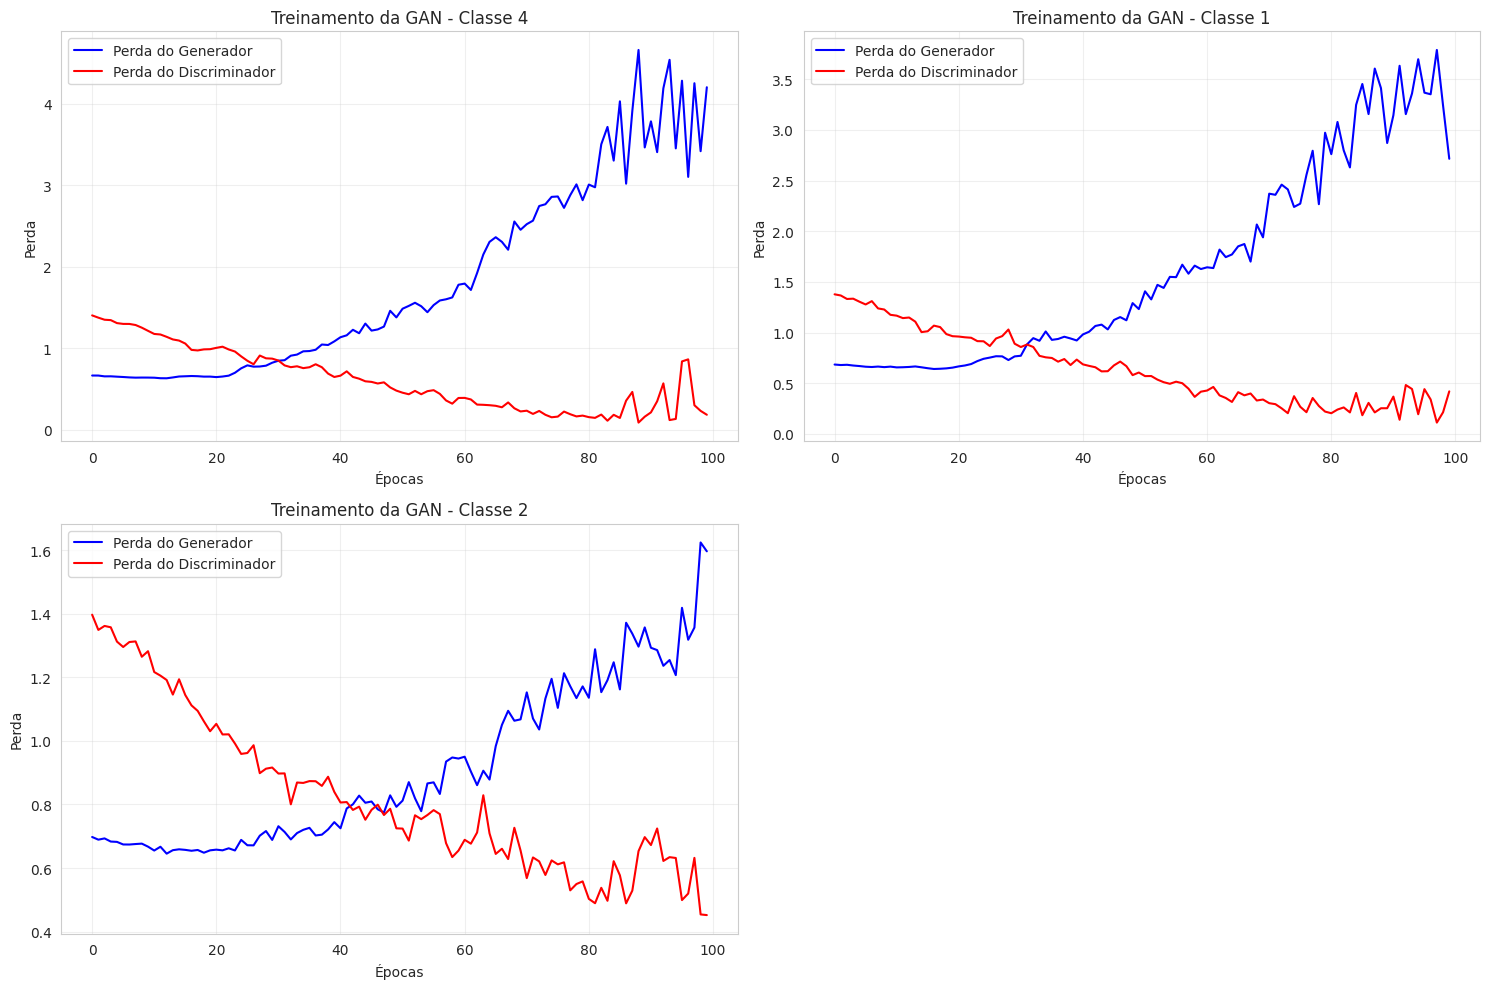

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Perda do Generador', color='blue')
    ax.plot(epochs, history['d_losses'], label='Perda do Discriminador', color='red')

    ax.set_title(f'Treinamento da GAN - Classe {class_id}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Perda')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

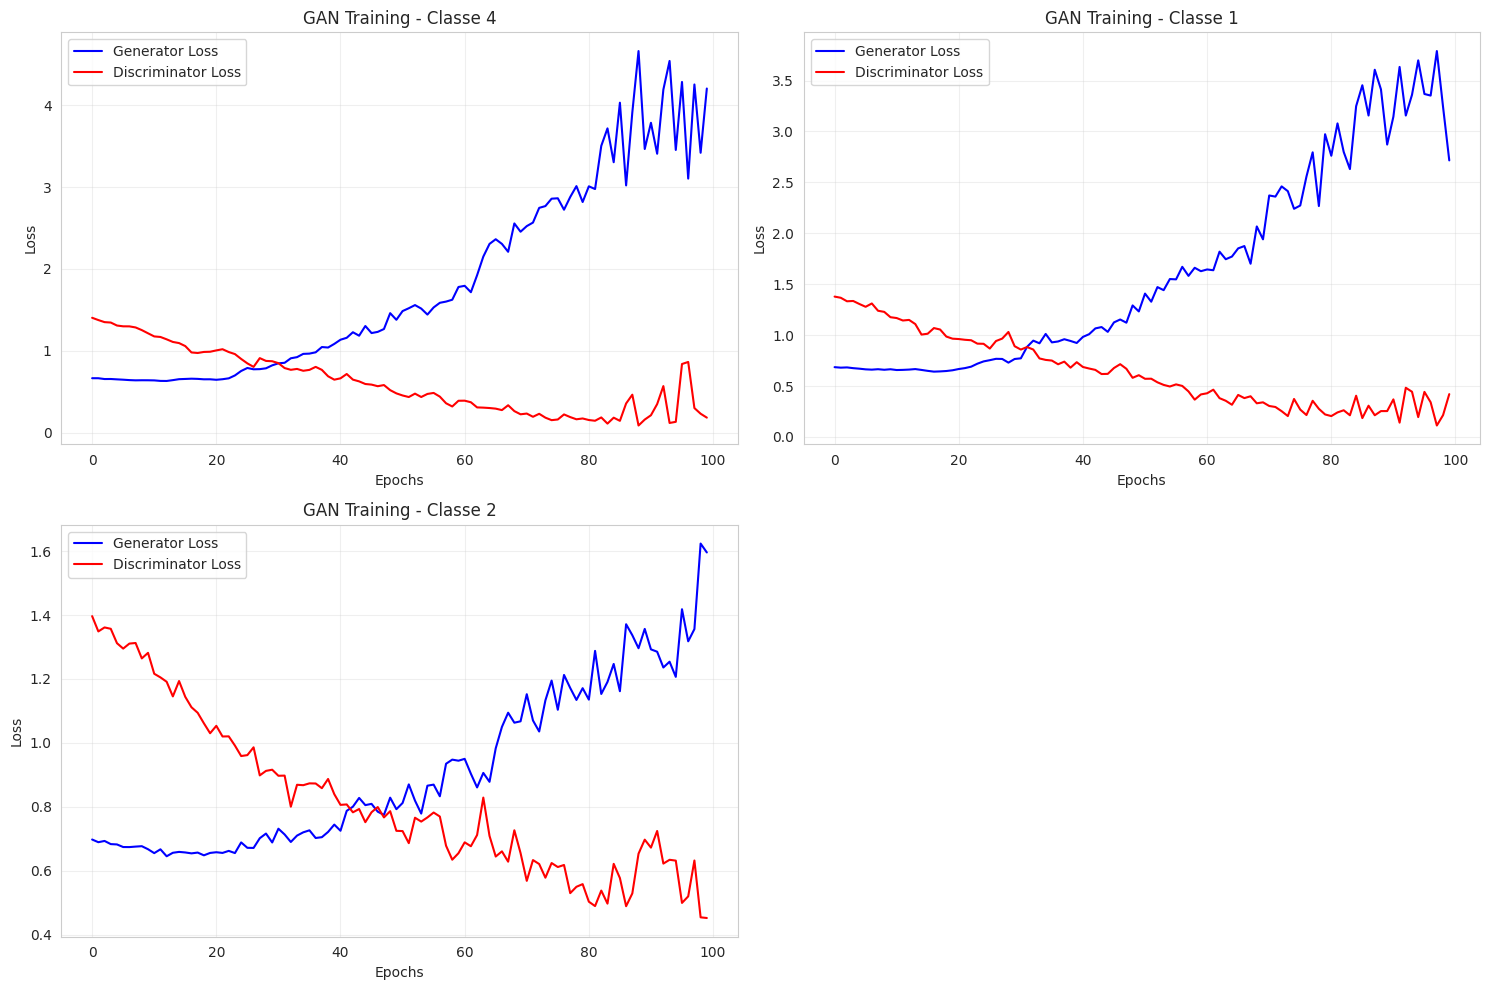

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df_gan_augmented_depression['tokenized_words'] = df_gan_augmented_depression['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_gan_augmented_depression['removed_stopwords'] = df_gan_augmented_depression['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_gan_augmented_depression['tokenized_words_joined'] = df_gan_augmented_depression['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

def test_model_performance_gan(data, title):
    """Testa performance do modelo com dados GAN-aumentados"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        'Naive Bayes': MultinomialNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2)
    }

    results = {}

    for model_name, model in models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro')
            }

            print(f"{model_name}:")
            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score: {results[model_name]['f1']:.4f}")

        except Exception as e:
            print(f"Erro com {model_name}: {e}")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}

    return results


df_original_processed = df_depression.copy()
df_original_processed['tokenized_words'] = df_original_processed['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_original_processed['removed_stopwords'] = df_original_processed['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original_processed['tokenized_words_joined'] = df_original_processed['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

results_original_gan = test_model_performance_gan(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = test_model_performance_gan(df_gan_augmented_depression, "DADOS GAN-AUMENTADOS")


=== DADOS ORIGINAIS ===
Tamanho do dataset: 28
Naive Bayes:
  Accuracy: 0.6667
  F1-Score: 0.4722
Logistic Regression:
  Accuracy: 0.6667
  F1-Score: 0.4722
SVM:
  Accuracy: 0.3333
  F1-Score: 0.1667
Random Forest:
  Accuracy: 0.5000
  F1-Score: 0.2222

=== DADOS GAN-AUMENTADOS ===
Tamanho do dataset: 328


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Naive Bayes:
  Accuracy: 0.8788
  F1-Score: 0.8815
Logistic Regression:
  Accuracy: 0.8636
  F1-Score: 0.8685
SVM:
  Accuracy: 0.8636
  F1-Score: 0.8652
Random Forest:
  Accuracy: 0.8939
  F1-Score: 0.8946


In [ ]:
def preprocess_dataframe(df, text_column='Transcription'):
    """Aplica tokenização, remoção de stopwords e junção de tokens em um DataFrame."""
    print(f"Pré-processando DataFrame... Tamanho: {len(df)} linhas.")
    df_processed = df.copy()
    df_processed['tokenized_words'] = df_processed[text_column].apply(
        lambda x: word_tokenize(str(x))
    )
    df_processed['removed_stopwords'] = df_processed['tokenized_words'].apply(
        lambda x: [word for word in x if word.lower() not in stop_words]
    )
    df_processed['tokenized_words_joined'] = df_processed['removed_stopwords'].apply(
        lambda x: ' '.join(x)
    )
    return df_processed

def find_best_models_and_evaluate(data, title):
    """
    Vetoriza os dados, encontra os melhores hiperparâmetros para cada modelo via GridSearchCV
    e avalia o desempenho no conjunto de validação.
    """
    print(f"INICIANDO AVALIAÇÃO: {title}\n")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    model_configs = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
            'params': {
              'C': [0.01, 0.1, 0.5, 1.0, 10.0],
              'penalty': ['l1', 'l2'],
              'solver': ['liblinear'],
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
            'params': {
              'n_estimators': [10, 50, 100, 200],
              'max_depth': [1, 10, 20, 50],
              'min_samples_split': [2, 5, 10, 20],
              'min_samples_leaf': [1, 5, 10, 20],
              'max_features': ['sqrt', 'log2']
            }
        },
        'SVM': {
            'model': SVC(random_state=42, class_weight='balanced', probability=True),
            'params': {
              'C': [0.01, 0.1, 1, 10],
              'gamma': ['scale', 'auto'],
              'kernel': ['linear', 'rbf']
            }
        },
        'Naive Bayes': {
            'model': MultinomialNB(),
            'params': {
              'alpha': [0.01, 0.1, 0.5, 1.0, 10.0],
              'fit_prior': [True, False]
            }
        }
    }

    results = {}
    cv_strategy = StratifiedKFold(n_splits=3)

    for model_name, config in model_configs.items():
        print(f"--- Treinando e otimizando {model_name} ---")
        try:
            grid_search = GridSearchCV(
                estimator=config['model'],
                param_grid=config['params'],
                cv=cv_strategy,
                scoring='accuracy',
                n_jobs=-1
            )
            grid_search.fit(X_train, y_train)

            best_model = grid_search.best_estimator_
            print(f"  Melhores parâmetros: {grid_search.best_params_}")

            y_pred = best_model.predict(X_val)
            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro'),
                'best_params': grid_search.best_params_
            }

            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score (Macro): {results[model_name]['f1']:.4f}")
            print(f"  Precision: {results[model_name]['precision']:.4f}")
            print(f"  Recall: {results[model_name]['recall']:.4f}\n")

        except Exception as e:
            print(f"  ERRO com {model_name}: {e}\n")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0, 'best_params': {}}

    return results


df_original_depression_processed = preprocess_dataframe(df_depression)
df_gan_augmented_depression_processed = preprocess_dataframe(df_gan_augmented_depression)

results_depression_original = find_best_models_and_evaluate(df_original_depression_processed, "DADOS ORIGINAIS")
results_depression_gan_augmented = find_best_models_and_evaluate(df_gan_augmented_depression_processed, "DADOS GAN-AUMENTADOS")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_depression_original.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results_depression_gan_augmented.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")


Pré-processando DataFrame... Tamanho: 28 linhas.
Pré-processando DataFrame... Tamanho: 328 linhas.
INICIANDO AVALIAÇÃO: DADOS ORIGINAIS

Tamanho do dataset: 28
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5000
  F1-Score (Macro): 0.2222
  Precision: 0.1667
  Recall: 0.3333

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Accuracy: 0.5000
  F1-Score (Macro): 0.3571
  Precision: 0.3333
  Recall: 0.3889

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.3333
  F1-Score (Macro): 0.2444
  Precision: 0.2500
  Recall: 0.2778

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.1, 'fit_prior': True}
  Accuracy: 0.3333
  F1-Score (Macro): 0.4444
  Precision: 0.4444
  Recall: 0.4444

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS

Tamanho do dataset: 328
--- Treinando e otimizando Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
  Accuracy: 0.9545
  F1-Score (Macro): 0.9549
  Precision: 0.9545
  Recall: 0.9559

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Accuracy: 0.8939
  F1-Score (Macro): 0.8931
  Precision: 0.8975
  Recall: 0.8959

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.8939
  F1-Score (Macro): 0.8936
  Precision: 0.9025
  Recall: 0.8959

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 1.0, 'fit_prior': True}
  Accuracy: 0.8788
  F1-Score (Macro): 0.8800
  Precision: 0.8928
  Recall: 0.8800



=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===

Modelo: Logistic Regression
  Acurácia: 0.5000
  F1-Score: 0.2222
  Precision: 0.1667
  Recall: 0.3333

Modelo: Random Forest
  Acurácia: 0.5000
  F1-Score: 0.

## Plots

In [ ]:
def create_comparison_df(results_original, results_augmented):
    records = []

    for model_name, metrics in results_original.items():
        record = {'model': model_name, 'condition': 'Original'}
        record.update(metrics)
        records.append(record)

    for model_name, metrics in results_augmented.items():
        record = {'model': model_name, 'condition': 'Augmented'}
        record.update(metrics)
        records.append(record)

    return pd.DataFrame(records)

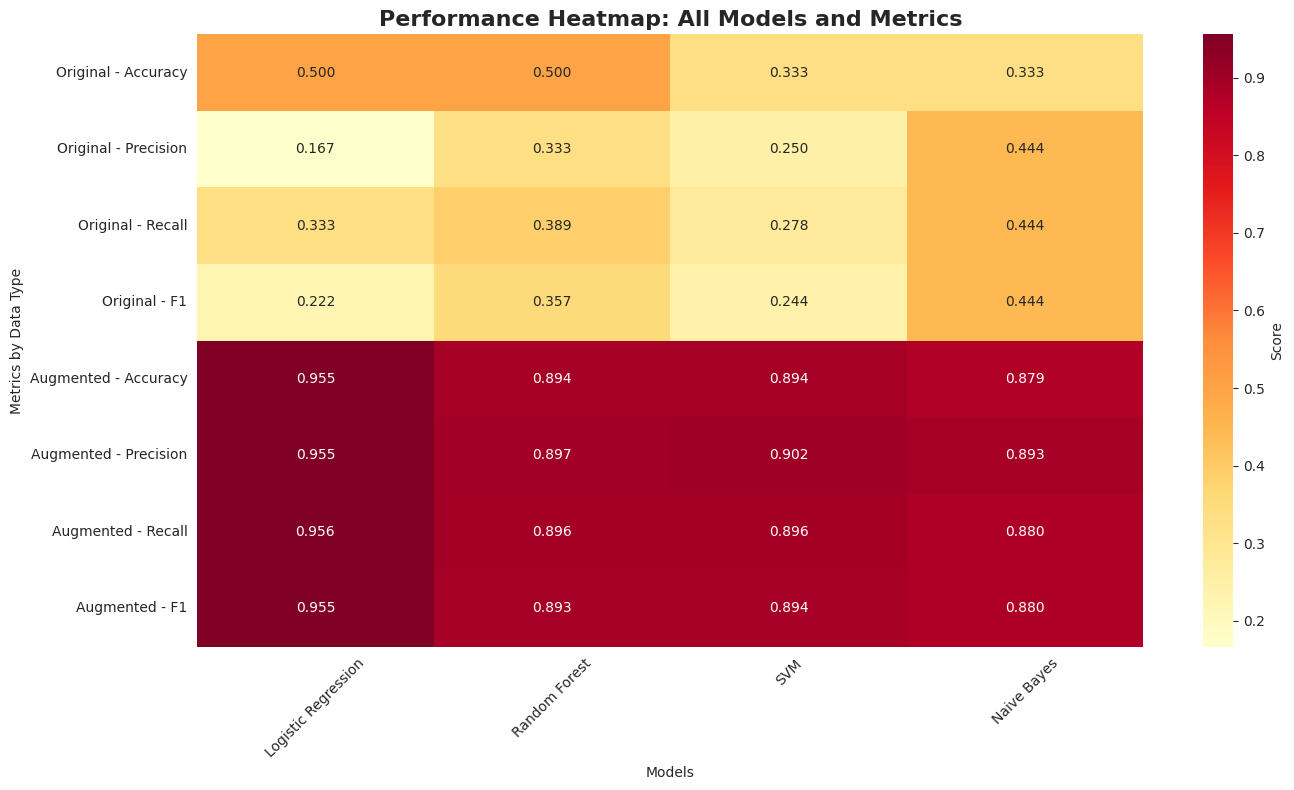

In [ ]:
comparison_df = create_comparison_df(results_depression_original, results_depression_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
metrics = ['accuracy', 'precision', 'recall', 'f1']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Score'})

plt.title('Performance Heatmap: All Models and Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Metrics by Data Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

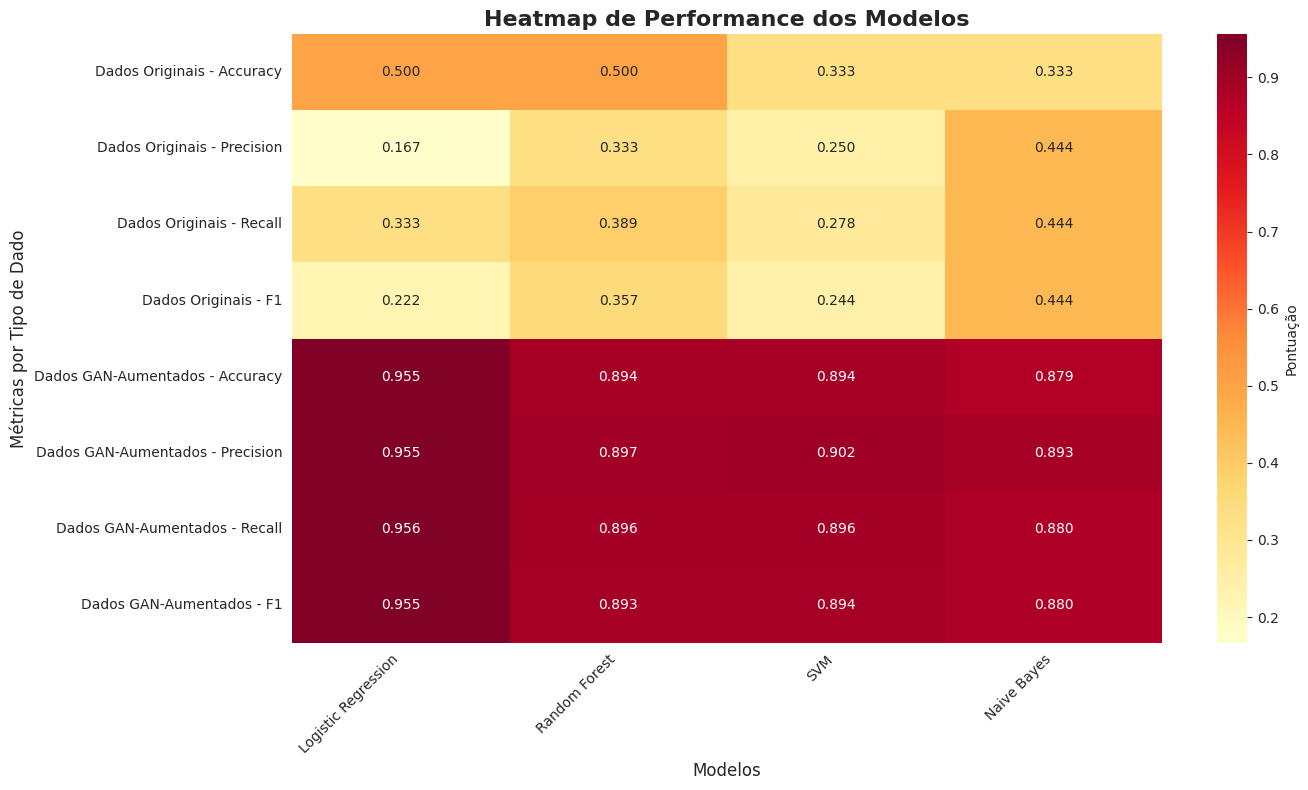

In [ ]:
comparison_df = create_comparison_df(results_depression_original, results_depression_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
conditions_br = ['Dados Originais', 'Dados GAN-Aumentados']
metrics = ['accuracy', 'precision', 'recall', 'f1']
metrics_labels_pt = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions_br for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Pontuação'})

plt.title('Heatmap de Performance dos Modelos', fontsize=16, fontweight='bold')
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Métricas por Tipo de Dado', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [ ]:
def plot_class_distribution(data, title):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimensão 1': X_embedded[:, 0],
        'Dimensão 2': X_embedded[:, 1],
        'Classe': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimensão 1',
        y='Dimensão 2',
        hue='Classe',
        style='Classe',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Distribuição das Classes ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("Componente t-SNE 1", fontsize=12)
    plt.ylabel("Componente t-SNE 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


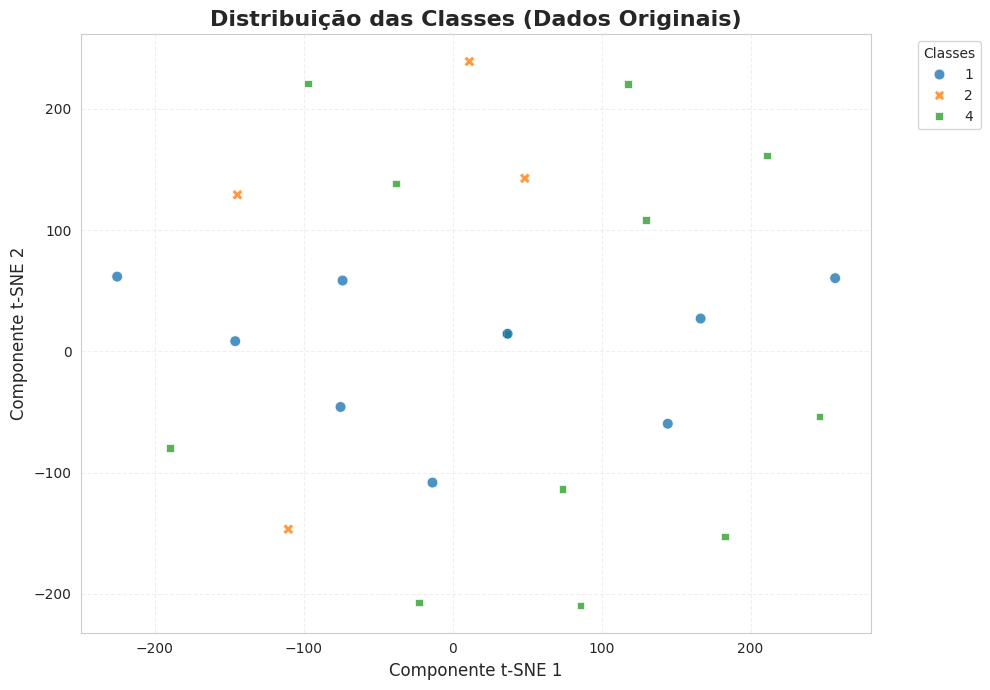

In [ ]:
plot_class_distribution(df_original_depression_processed, "Dados Originais")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


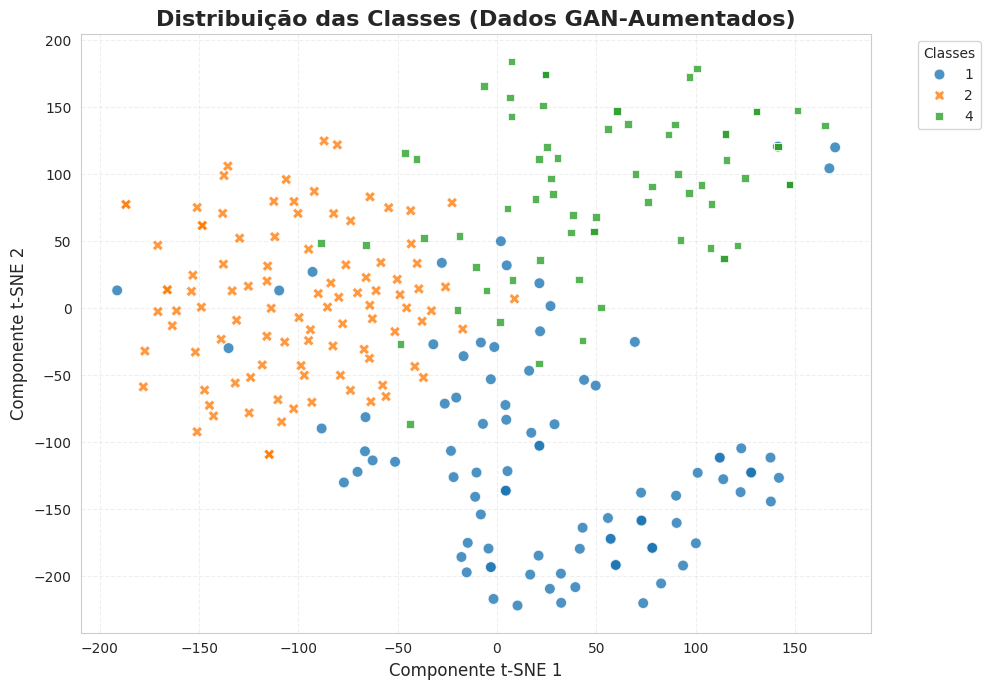

In [ ]:
plot_class_distribution(df_gan_augmented_depression_processed, "Dados GAN-Aumentados")

In [ ]:
def plot_class_distribution(data, title):
    # Vectorize the text data using TF-IDF
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimension 1': X_embedded[:, 0],
        'Dimension 2': X_embedded[:, 1],
        'Class': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimension 1',
        y='Dimension 2',
        hue='Class',
        style='Class',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Class Distribution ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("t-SNE 1 Component", fontsize=12)
    plt.ylabel("t-SNE 2 Component", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


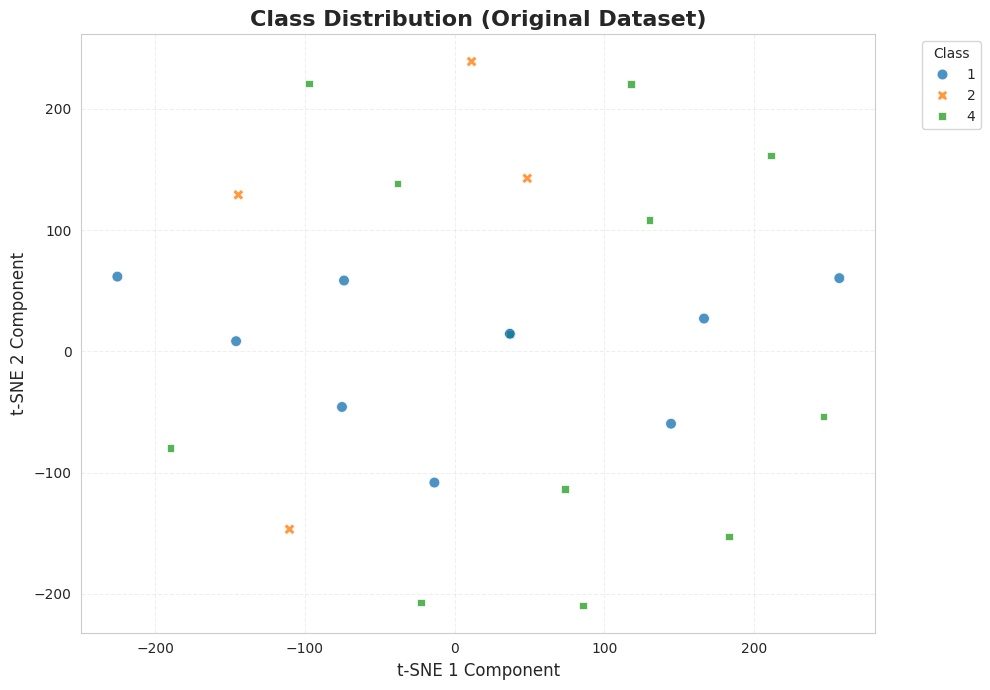

In [ ]:
plot_class_distribution(df_original_depression_processed, "Original Dataset")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


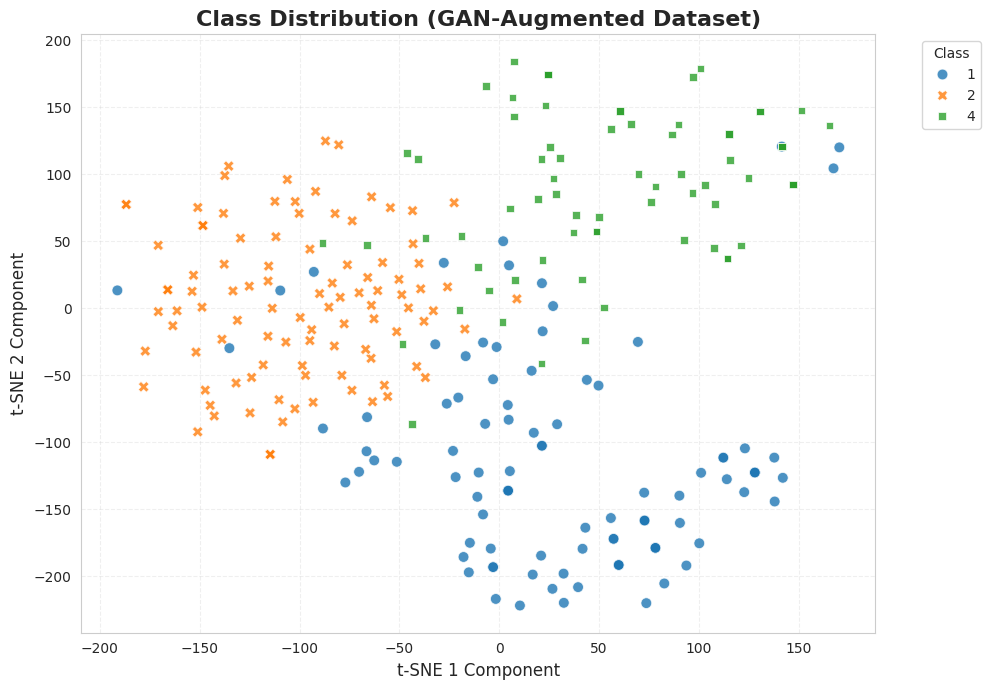

In [ ]:
plot_class_distribution(df_gan_augmented_depression_processed, "GAN-Augmented Dataset")

# Depression + Anxiety (Combination)

## Pre-processing

In [ ]:
df_combined = pd.concat([df_depression, df_anxiety], ignore_index=True)
df_combined.head()

,ID,Transcription,Tag,Link,Platform,Views / Likes,Classificação,tokenized_words,removed_stopwords,tokenized_words_joined,pos_tags,pos_tags_stopwords,Views / Likes_str,Views_Numeric,Plataform
0,3,Não Chora não chora não chora não chora,depressao,https://www.instagram.com/reel/C9oE9g-N3vF/?ig...,instagram,4203201.0,4,"[Não, Chora, não, chora, não, chora, não, chora]","[Chora, chora, chora, chora]",Chora chora chora chora,"[(Não, ADV), (Chora, VERB), (não, ADV), (chora...","[(Chora, NOUN), (chora, VERB), (chora, VERB), ...",4.0M,4000000.0,NaN
1,1,esse aqui é o Uno é o Uno a lenda viva esse aq...,depressao,https://www.instagram.com/reel/C8fBq0IOixX/?ig...,instagram,1432116.0,4,"[esse, aqui, é, o, Uno, é, o, Uno, a, lenda, v...","[aqui, Uno, Uno, lenda, viva, aqui, melhor, ca...",aqui Uno Uno lenda viva aqui melhor carro fabr...,"[(esse, DET), (aqui, NOUN), (é, AUX), (o, DET)...","[(aqui, ADV), (Uno, PROPN), (Uno, PROPN), (len...",1.0M,1000000.0,NaN
2,0,depressão é foda né Eu tive um princípio foi f...,depressao,https://www.instagram.com/reel/C8E2hVeONhc/?ig...,instagram,1395605.0,1,"[depressão, é, foda, né, Eu, tive, um, princíp...","[depressão, foda, né, princípio, foda, coisa, ...",depressão foda né princípio foda coisa fácil l...,"[(depressão, NOUN), (é, AUX), (foda, NOUN), (n...","[(depressão, NOUN), (foda, ADJ), (né, ADP), (p...",1.0M,1000000.0,NaN
3,10,Porque existe uma relação muito próxima entre ...,depressao,https://www.instagram.com/reel/C8eOhQCBgAO/?ig...,instagram,941155.0,4,"[Porque, existe, uma, relação, muito, próxima,...","[Porque, existe, relação, próxima, saúde, ment...",Porque existe relação próxima saúde mental can...,"[(Porque, SCONJ), (existe, VERB), (uma, DET), ...","[(Porque, SCONJ), (existe, VERB), (relação, NO...",941.0k,941000.0,NaN
4,9,como ficar deprimido primeiro seja sedentário ...,depressao,https://www.instagram.com/reel/C8O6oHzuNS9/?ig...,instagram,553648.0,4,"[como, ficar, deprimido, primeiro, seja, seden...","[ficar, deprimido, primeiro, sedentário, faça,...",ficar deprimido primeiro sedentário faça exerc...,"[(como, SCONJ), (ficar, VERB), (deprimido, VER...","[(ficar, VERB), (deprimido, VERB), (primeiro, ...",553.0k,553000.0,NaN


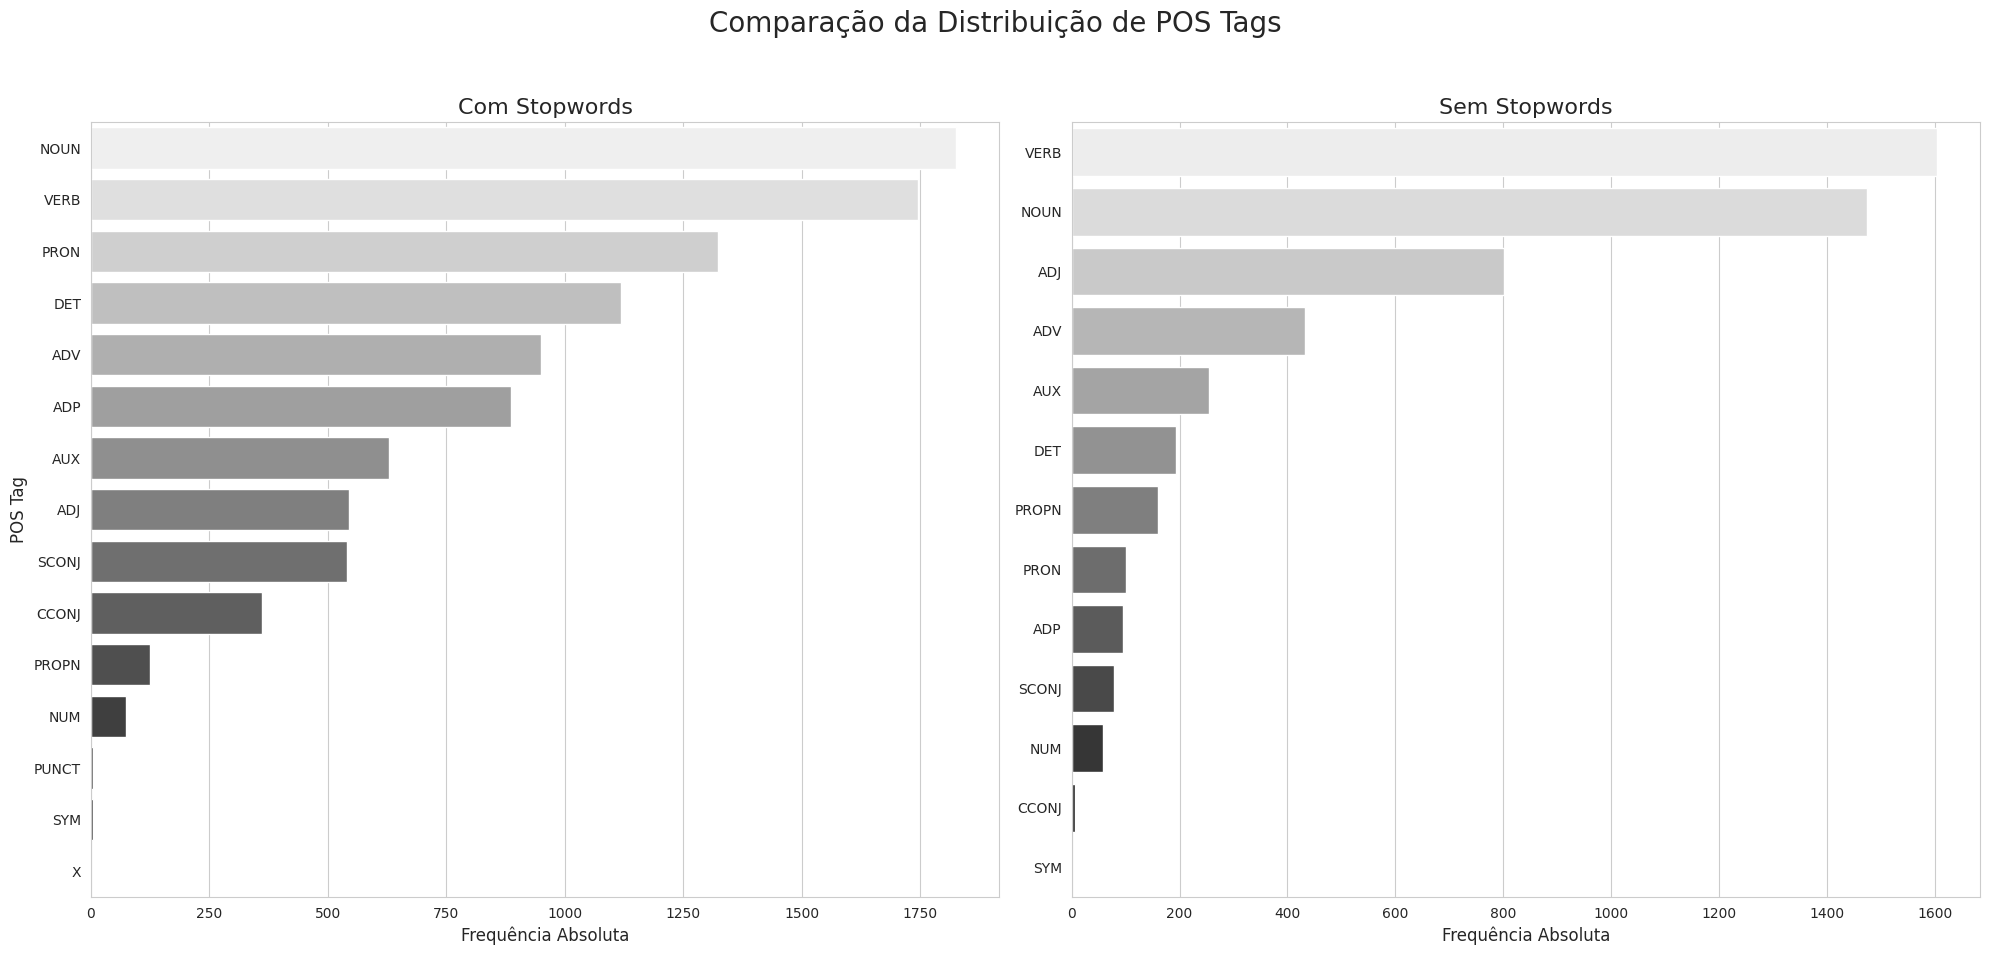

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_combined['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_combined['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparação da Distribuição de POS Tags', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('Com Stopwords', fontsize=16)
axes[0].set_xlabel('Frequência Absoluta', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Frequência Absoluta', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

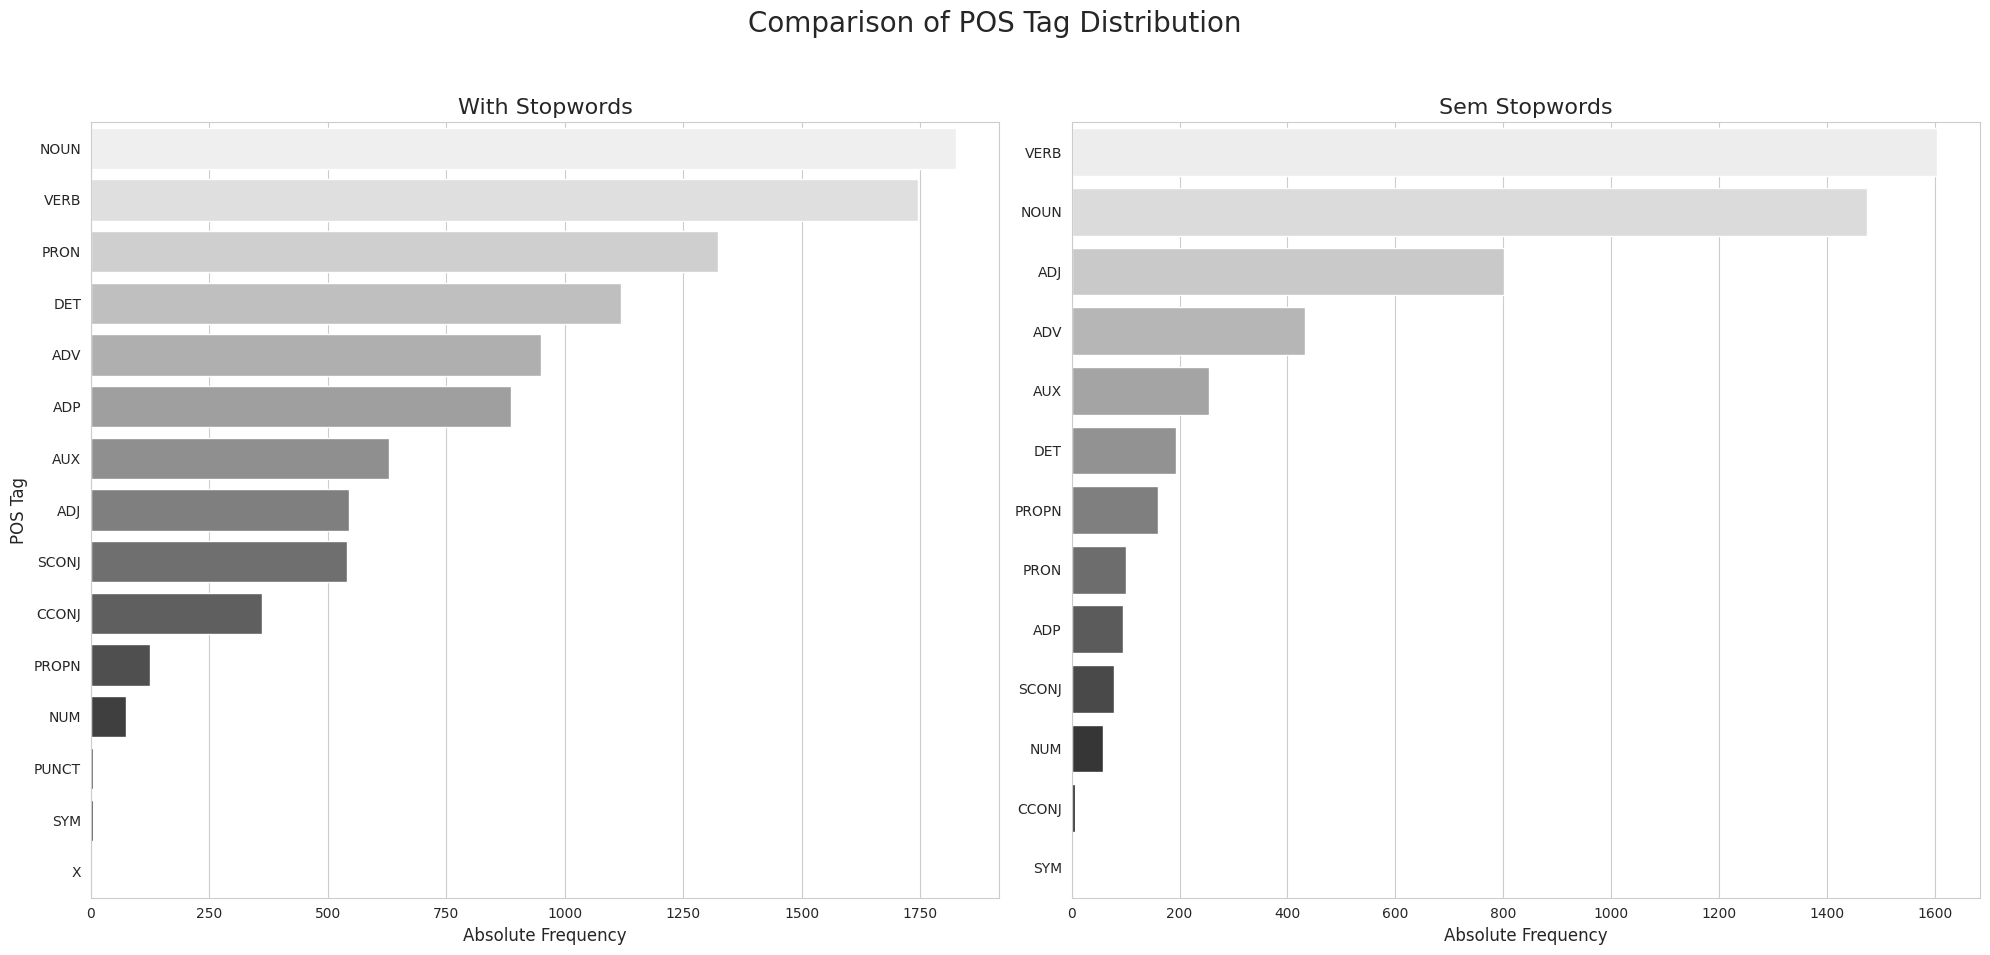

<Figure size 640x480 with 0 Axes>

In [ ]:
todas_as_tags_com_sw = []
for lista_de_tuplas in df_combined['pos_tags']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_com_sw.append(tag)

contagem_com_sw = Counter(todas_as_tags_com_sw)
df_contagem_com_sw = pd.DataFrame(contagem_com_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_com_sw = df_contagem_com_sw.sort_values(by='Frequencia', ascending=False)

todas_as_tags_sem_sw = []
for lista_de_tuplas in df_combined['pos_tags_stopwords']:
    for _, tag in lista_de_tuplas:
        todas_as_tags_sem_sw.append(tag)

contagem_sem_sw = Counter(todas_as_tags_sem_sw)
df_contagem_sem_sw = pd.DataFrame(contagem_sem_sw.items(), columns=['POS_Tag', 'Frequencia'])
df_contagem_sem_sw = df_contagem_sem_sw.sort_values(by='Frequencia', ascending=False)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

fig.suptitle('Comparison of POS Tag Distribution', fontsize=20)

sns.barplot(
    ax=axes[0],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_com_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[0].set_title('With Stopwords', fontsize=16)
axes[0].set_xlabel('Absolute Frequency', fontsize=12)
axes[0].set_ylabel('POS Tag', fontsize=12)

sns.barplot(
    ax=axes[1],
    x='Frequencia',
    y='POS_Tag',
    data=df_contagem_sem_sw,
    palette='gray_r',
    orient='h',
    hue='POS_Tag',
    legend=False
)
axes[1].set_title('Sem Stopwords', fontsize=16)
axes[1].set_xlabel('Absolute Frequency', fontsize=12)
axes[1].set_ylabel('')

# Ajusta o espaçamento e exibe o gráfico
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("POS")

In [ ]:
def convert_views_to_numeric(view_str):
    view_str = str(view_str).strip().upper()
    if 'M' in view_str:
        return float(view_str.replace('M', '')) * 1_000_000
    if 'K' in view_str:
        return float(view_str.replace('K', '')) * 1_000
    try:
        return float(view_str)
    except (ValueError, TypeError):
        return pd.NA

df_combined['Views_Numeric'] = df_combined['Views / Likes_str'].apply(convert_views_to_numeric)

df_plot = df_combined.sort_values('Views_Numeric', ascending=False).reset_index(drop=True)

df_plot['Ranking'] = df_plot.index + 1

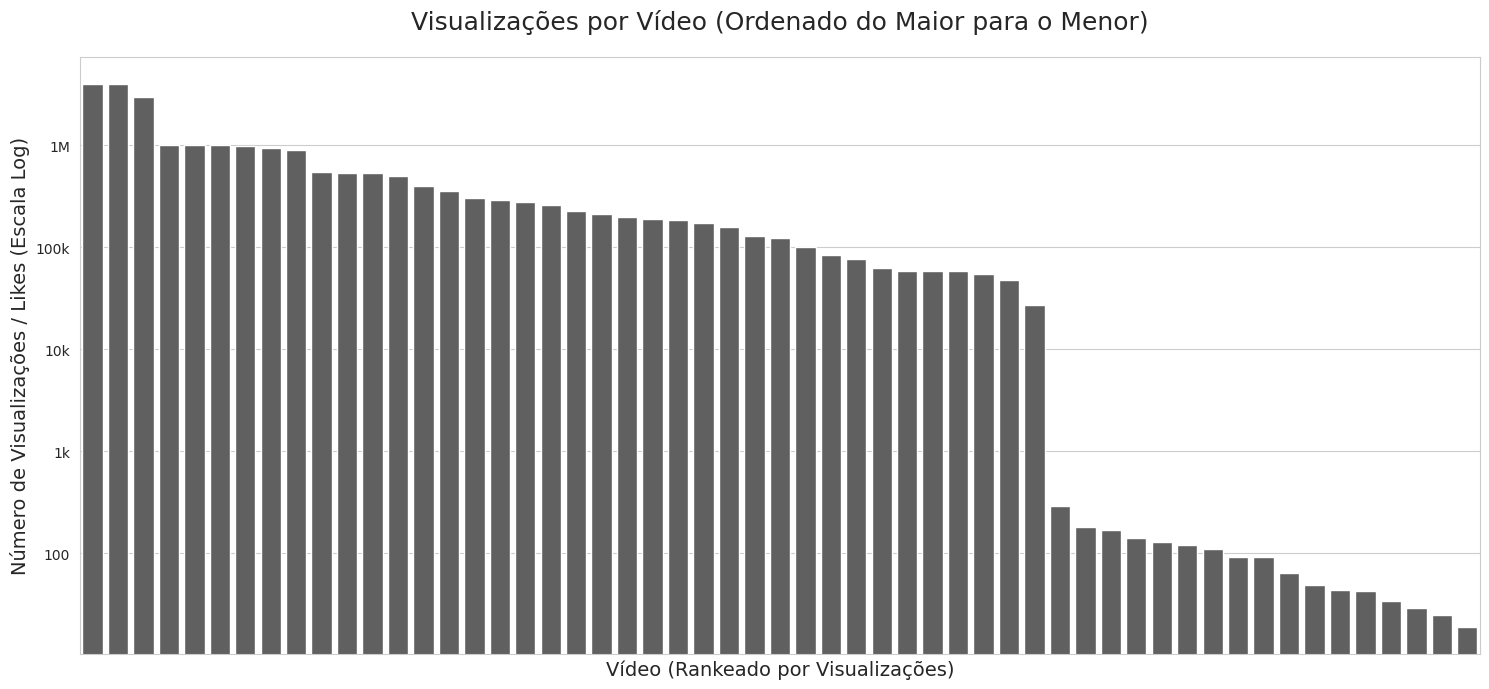

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

barplot = sns.barplot(
    data=df_plot,
    x='Ranking',
    y='Views_Numeric',
    color='#606060'
)

plt.yscale('log')

plt.title('Visualizações por Vídeo (Ordenado do Maior para o Menor)', fontsize=18, pad=20)
plt.xlabel('Vídeo (Rankeado por Visualizações)', fontsize=14)
plt.ylabel('Número de Visualizações / Likes (Escala Log)', fontsize=14)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda y, pos: f'{y/1_000_000:.0f}M' if y >= 1_000_000 else (f'{y/1_000:.0f}k' if y >= 1_000 else f'{y:.0f}'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks([])

plt.tight_layout()
plt.show()

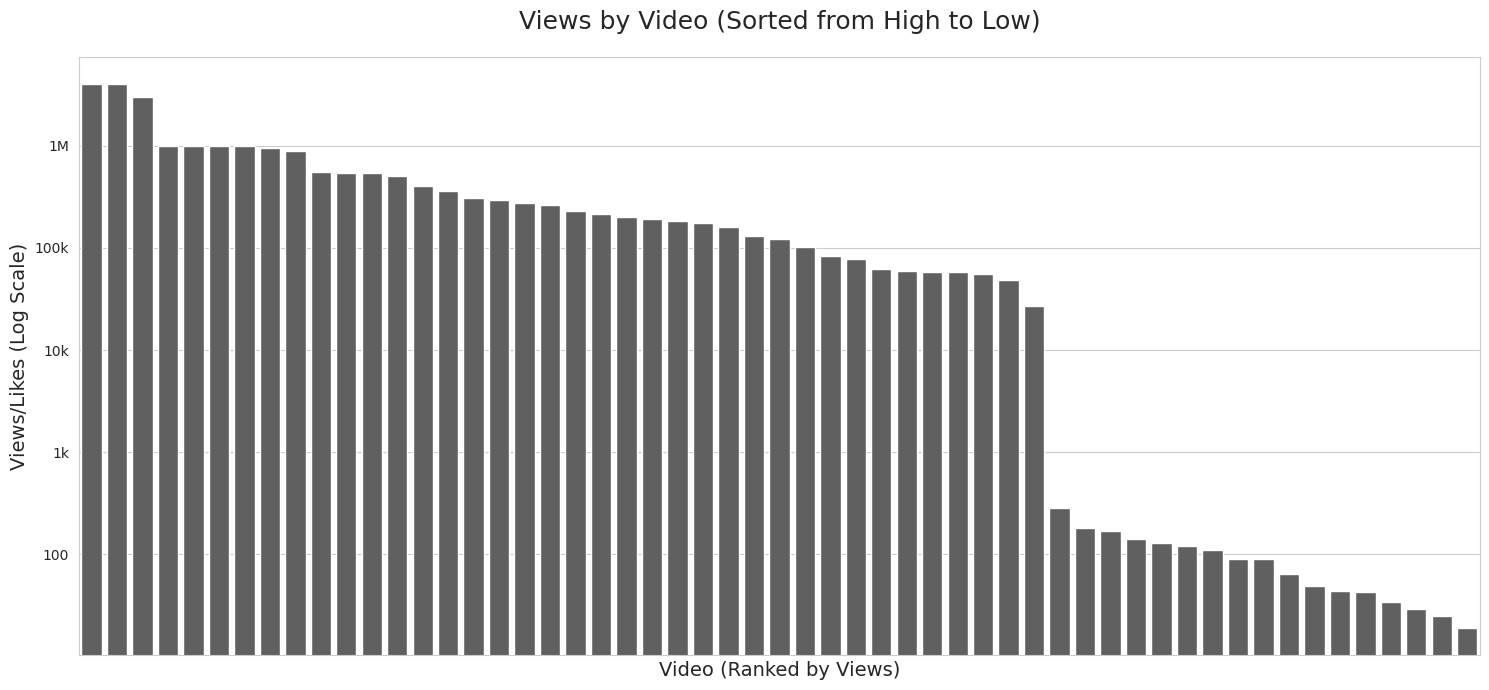

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

barplot = sns.barplot(
    data=df_plot,
    x='Ranking',
    y='Views_Numeric',
    color='#606060'
)

plt.yscale('log')

plt.title('Views by Video (Sorted from High to Low)', fontsize=18, pad=20)
plt.xlabel('Video (Ranked by Views)', fontsize=14)
plt.ylabel('Views/Likes (Log Scale)', fontsize=14)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda y, pos: f'{y/1_000_000:.0f}M' if y >= 1_000_000 else (f'{y/1_000:.0f}k' if y >= 1_000 else f'{y:.0f}'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks([])

plt.tight_layout()
plt.show()

## Training

### Generating Embeddings

In [ ]:
texts_by_class = {}
for class_id in df_combined['Classificação'].unique():
    class_texts = df_combined[df_combined['Classificação'] == class_id]['Transcription'].tolist()
    texts_by_class[class_id] = class_texts
    print(f"Classe {class_id}: {len(class_texts)} textos")

Classe 4: 13 textos
Classe 1: 20 textos
Classe 2: 18 textos
Classe 3: 4 textos


In [ ]:
def get_text_embeddings(texts, batch_size=32, max_length=128, device='cpu'):
    """Converte textos em embeddings usando BERT em modo batch."""
    all_embeddings = []
    embedding_model.to(device)

    for i in tqdm(range(0, len(texts), batch_size), desc="Gerando Embeddings"):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = embedding_model(**inputs)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

print("Gerando embeddings...")
embeddings_by_class = {}
for class_id, texts in texts_by_class.items():
    print(f"Processando classe {class_id}...")
    embeddings = get_text_embeddings(texts[:100])
    embeddings_by_class[class_id] = embeddings
    print(f"  Shape: {embeddings.shape}")

class Generator(nn.Module):
    """Gerador da GAN para criar embeddings sintéticos"""
    def __init__(self, noise_dim=100, embedding_dim=768, hidden_dim=512):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(noise_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim, embedding_dim),
            nn.Tanh()  # Normalizar saída
        )

    def forward(self, noise):
        return self.model(noise)

class Discriminator(nn.Module):
    """Discriminador da GAN para distinguir embeddings reais de sintéticos"""
    def __init__(self, embedding_dim=768, hidden_dim=512):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            # Camada 1
            nn.Linear(embedding_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 2
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada 3
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Camada de saída
            nn.Linear(hidden_dim // 4, 1),
            nn.Sigmoid()
        )

    def forward(self, embedding):
        return self.model(embedding)


def train_gan_for_class(embeddings, epochs=100, batch_size=16, noise_dim=100, device='cpu'): # 1. Adicionar 'device' como parâmetro
    """Treina uma GAN para uma classe específica no dispositivo correto."""

    if len(embeddings) < batch_size:
        print(f"Poucos dados ({len(embeddings)}), ajustando batch_size para {len(embeddings)}")
        batch_size = len(embeddings)

    embedding_dim = embeddings.shape[1]

    generator = Generator(noise_dim, embedding_dim).to(device)
    discriminator = Discriminator(embedding_dim).to(device)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    real_embeddings = torch.FloatTensor(embeddings).to(device)

    g_losses, d_losses = [], []
    print(f"Iniciando treinamento com {len(embeddings)} amostras")

    for epoch in range(epochs):
        indices = torch.randperm(len(real_embeddings))
        epoch_g_loss, epoch_d_loss, num_batches = 0, 0, 0

        for i in range(0, len(indices), batch_size):
            batch_indices = indices[i:i+batch_size]
            real_batch = real_embeddings[batch_indices]
            batch_len = len(real_batch)

            if batch_len <= 1:
              continue

            real_labels = torch.ones(batch_len, 1).to(device)
            fake_labels = torch.zeros(batch_len, 1).to(device)

            # --- Treinar Discriminador ---
            d_optimizer.zero_grad()
            d_real_loss = criterion(discriminator(real_batch), real_labels)

            noise = torch.randn(batch_len, noise_dim).to(device)
            with torch.no_grad():
                fake_batch = generator(noise)
            d_fake_loss = criterion(discriminator(fake_batch), fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()

            # --- Treinar Gerador ---
            g_optimizer.zero_grad()
            noise = torch.randn(batch_len, noise_dim).to(device)
            fake_batch = generator(noise)
            g_loss = criterion(discriminator(fake_batch), real_labels)

            g_loss.backward()
            g_optimizer.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            num_batches += 1

        avg_g_loss = epoch_g_loss / num_batches
        avg_d_loss = epoch_d_loss / num_batches
        g_losses.append(avg_g_loss)
        d_losses.append(avg_d_loss)

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: G_Loss = {avg_g_loss:.4f}, D_Loss = {avg_d_loss:.4f}")

    return generator, discriminator, g_losses, d_losses

scalers_by_class = {}
scaled_embeddings_by_class = {}

for class_id, embeddings in embeddings_by_class.items():
    if len(embeddings) < 3:
        print(f"Classe {class_id} tem dados insuficientes para normalização, pulando.")
        continue

    scaler = StandardScaler()

    scaled_embeddings = scaler.fit_transform(embeddings)

    scalers_by_class[class_id] = scaler
    scaled_embeddings_by_class[class_id] = scaled_embeddings


generators = {}
discriminators = {}
training_histories = {}

for class_id, scaled_embeddings in scaled_embeddings_by_class.items():
    print(f"\nTREINANDO GAN PARA CLASSE {class_id}")

    try:
        generator, discriminator, g_losses, d_losses = train_gan_for_class(
            scaled_embeddings,
            epochs=100,
            batch_size=8,
            device=device
        )

        generators[class_id] = generator
        discriminators[class_id] = discriminator
        training_histories[class_id] = {'g_losses': g_losses, 'd_losses': d_losses}

        print(f"GAN treinada para classe {class_id}")

    except Exception as e:
        print(f"Erro ao treinar GAN para classe {class_id}: {e}")

def generate_and_rescale_embeddings(generator, scaler, num_samples=50, noise_dim=100, device='cpu'):
    """Gera embeddings sintéticos e os retorna para a escala original."""
    generator.eval()
    generator.to(device)

    with torch.no_grad():
        noise = torch.randn(num_samples, noise_dim).to(device)
        synthetic_embeddings_scaled = generator(noise)

        synthetic_embeddings_scaled = synthetic_embeddings_scaled.cpu().numpy()

    synthetic_embeddings_original_scale = scaler.inverse_transform(synthetic_embeddings_scaled)

    return synthetic_embeddings_original_scale

synthetic_embeddings_by_class = {}

for class_id, generator in generators.items():
    print(f"\nGerando embeddings sintéticos para classe {class_id}")

    scaler = scalers_by_class[class_id]

    original_count = len(embeddings_by_class[class_id])
    target_count = max(100, original_count * 3)

    final_synthetic_embeddings = generate_and_rescale_embeddings(
        generator,
        scaler,
        num_samples=target_count,
        device=device
    )

    synthetic_embeddings_by_class[class_id] = final_synthetic_embeddings

    print(f"  Originais: {original_count}, Sintéticos gerados: {len(final_synthetic_embeddings)}")
    print(f"  Média dos embeddings sintéticos (escala original): {final_synthetic_embeddings.mean():.2f}")

Gerando embeddings...
Processando classe 4...


Gerando Embeddings: 100%|██████████| 1/1 [00:04<00:00,  4.92s/it]


  Shape: (13, 768)
Processando classe 1...


Gerando Embeddings: 100%|██████████| 1/1 [00:06<00:00,  6.25s/it]


  Shape: (20, 768)
Processando classe 2...


Gerando Embeddings: 100%|██████████| 1/1 [00:06<00:00,  6.52s/it]


  Shape: (18, 768)
Processando classe 3...


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


  Shape: (4, 768)

TREINANDO GAN PARA CLASSE 4
Iniciando treinamento com 13 amostras
Epoch 0: G_Loss = 0.7184, D_Loss = 1.4082
Epoch 20: G_Loss = 0.6795, D_Loss = 0.9945
Epoch 40: G_Loss = 1.1648, D_Loss = 0.6980
Epoch 60: G_Loss = 1.8455, D_Loss = 0.4445
Epoch 80: G_Loss = 2.7629, D_Loss = 0.1772
GAN treinada para classe 4

TREINANDO GAN PARA CLASSE 1
Iniciando treinamento com 20 amostras
Epoch 0: G_Loss = 0.7168, D_Loss = 1.4093
Epoch 20: G_Loss = 0.8092, D_Loss = 0.9327
Epoch 40: G_Loss = 1.7335, D_Loss = 0.3960
Epoch 60: G_Loss = 3.6836, D_Loss = 0.1755
Epoch 80: G_Loss = 4.1774, D_Loss = 0.1592
GAN treinada para classe 1

TREINANDO GAN PARA CLASSE 2
Iniciando treinamento com 18 amostras
Epoch 0: G_Loss = 0.6982, D_Loss = 1.3762
Epoch 20: G_Loss = 0.7685, D_Loss = 0.9202
Epoch 40: G_Loss = 1.4826, D_Loss = 0.4796
Epoch 60: G_Loss = 2.4849, D_Loss = 0.7194
Epoch 80: G_Loss = 4.0140, D_Loss = 0.1066
GAN treinada para classe 2

TREINANDO GAN PARA CLASSE 3
Poucos dados (4), ajustando b

### Generating synthetic text using cosine similarity

Processando classe 4...


Gerando Embeddings: 100%|██████████| 1/1 [00:04<00:00,  4.87s/it]


  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:03<00:00,  3.75s/it]


  Processados 60/100


...

  Processados 10/100


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]


  Processados 60/100


Gerando Embeddings: 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]


  Gerados 100 textos sintéticos
Dataset original: 55 amostras
Dataset aumentado com GANs: 455 amostras
Aumento: 727.3%

Distribuição das classes no dataset GAN-aumentado:
Classificação
1    120
2    118
4    113
3    104
Name: count, dtype: int64


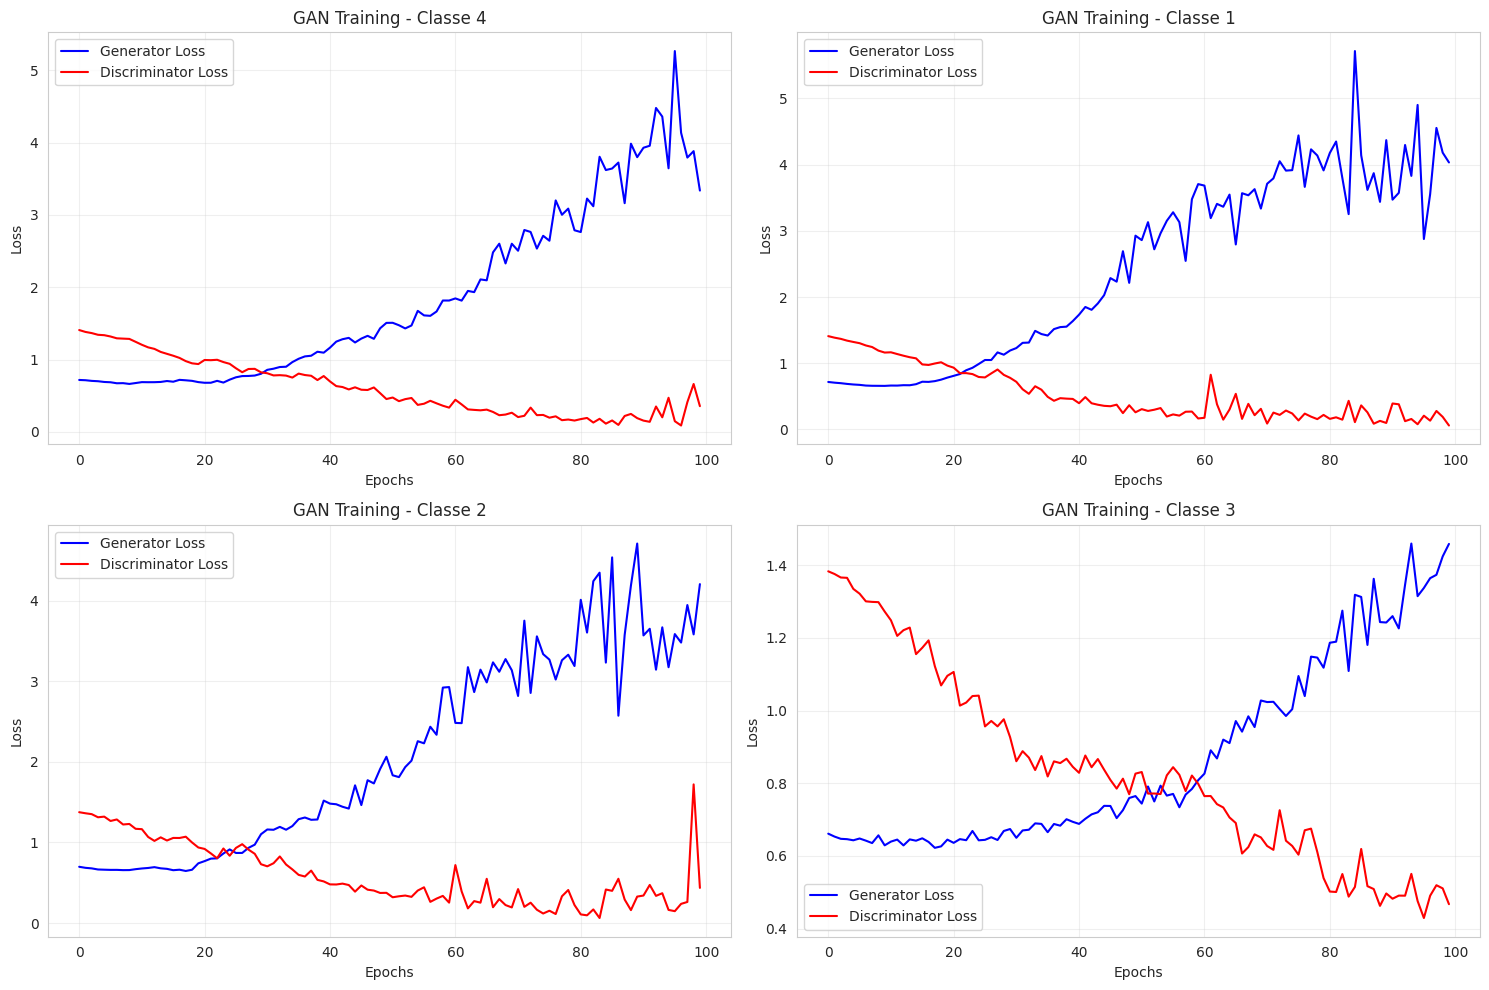

In [ ]:
synthetic_texts_by_class_cosine = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando classe {class_id}...")

    original_texts = texts_by_class[class_id]
    synthetic_texts = []

    # Processar em lotes menores para evitar sobrecarga
    batch_size = 10
    for i in range(0, len(synthetic_embeddings), batch_size):
        batch_embeddings = synthetic_embeddings[i:i+batch_size]

        for embedding in batch_embeddings:
            try:
                synthetic_text = embedding_to_text_simple(embedding, original_texts)
                synthetic_texts.append(synthetic_text)
            except Exception as e:
                print(f"Erro ao converter embedding: {e}")
                # Usar texto original como fallback
                synthetic_texts.append(random.choice(original_texts))

        if i % 50 == 0:
            print(f"  Processados {min(i+batch_size, len(synthetic_embeddings))}/{len(synthetic_embeddings)}")

    synthetic_texts_by_class_cosine[class_id] = synthetic_texts
    print(f"  Gerados {len(synthetic_texts)} textos sintéticos")


combined_gan_augmented_data_cosine = []
for _, row in df_combined.iterrows():
    combined_gan_augmented_data_cosine.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class_cosine.items():
    for text in synthetic_texts:
        combined_gan_augmented_data_cosine.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

# Criar DataFrame
df_combined_gan_augmented_cosine = pd.DataFrame(combined_gan_augmented_data_cosine)

print(f"Dataset original: {len(df_combined)} amostras")
print(f"Dataset aumentado com GANs: {len(df_combined_gan_augmented_cosine)} amostras")
print(f"Aumento: {((len(df_combined_gan_augmented_cosine) - len(df_combined)) / len(df_combined) * 100):.1f}%")

print("\nDistribuição das classes no dataset GAN-aumentado:")
print(df_combined_gan_augmented_cosine['Classificação'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

# Remover subplots não utilizados
for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df_original_for_cossine_processed = preprocess_dataframe(df_combined)
df_gan_augmented_for_cossine_processed = preprocess_dataframe(df_combined_gan_augmented_cosine)

results_combined_original_cossine = find_best_models_and_evaluate(df_original_for_cossine_processed, "DADOS ORIGINAIS (Cosseno)")
results_combined_gan_augmented_cossine = find_best_models_and_evaluate(df_gan_augmented_for_cossine_processed, "DADOS GAN-AUMENTADOS (Cosseno)")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_combined_original_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results_combined_gan_augmented_cossine.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")


Pré-processando DataFrame... Tamanho: 55 linhas.
Pré-processando DataFrame... Tamanho: 455 linhas.
INICIANDO AVALIAÇÃO: DADOS ORIGINAIS (Cosseno)

Tamanho do dataset: 55
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5455
  F1-Score (Macro): 0.3205
  Precision: 0.3611
  Recall: 0.3750

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}
  Accuracy: 0.6364
  F1-Score (Macro): 0.5060
  Precision: 0.5000
  Recall: 0.5625

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.5455
  F1-Score (Macro): 0.3205
  Precision: 0.3611
  Recall: 0.3750

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.5, 'fit_prior': True}
  Accuracy: 0.4545
  F1-Score (Macro): 0.2429
  Precision: 0.3500
  Recall: 0.3125

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS (Cosseno)

Tamanho do dataset: 455


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.9341
  F1-Score (Macro): 0.9376
  Precision: 0.9500
  Recall: 0.9341

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.9231
  F1-Score (Macro): 0.9275
  Precision: 0.9435
  Recall: 0.9237

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.9231
  F1-Score (Macro): 0.9275
  Precision: 0.9435
  Recall: 0.9237

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 10.0, 'fit_prior': True}
  Accuracy: 0.9341
  F1-Score (Macro): 0.9353
  Precision: 0.9416
  Recall: 0.9341



=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===

Modelo: Logistic Regression
  Acurácia: 0.5455
  F1-Score: 0.3205
  Precision: 0.3611
  Recall: 0.3750

Mod

### Generating synthetic text using LLM

In [ ]:
synthetic_texts_by_class = {}
for class_id, synthetic_embeddings in synthetic_embeddings_by_class.items():
    print(f"Processando e gerando textos para a classe {class_id}")

    original_texts = texts_by_class[class_id]
    original_embeds = embeddings_by_class[class_id]

    synthetic_texts = []

    for embedding in tqdm(synthetic_embeddings, desc=f"Gerando textos para classe {class_id}"):
        try:
            synthetic_text = embedding_to_generative_text(
                embedding,
                original_texts,
                original_embeds,
                generator_pipeline
            )
            synthetic_texts.append(synthetic_text)
        except Exception as e:
            print(f"Erro ao converter embedding: {e}")
            if original_texts:
                synthetic_texts.append(random.choice(original_texts))

    synthetic_texts_by_class[class_id] = synthetic_texts
    print(f"\nGerados {len(synthetic_texts)} textos sintéticos para a classe {class_id}")


Processando e gerando textos para a classe 4


Gerando textos para classe 4: 100%|██████████| 100/100 [05:31<00:00,  3.31s/it]



Gerados 100 textos sintéticos para a classe 4
Processando e gerando textos para a classe 1


Gerando textos para classe 1: 100%|██████████| 100/100 [02:16<00:00,  1.36s/it]



Gerados 100 textos sintéticos para a classe 1
Processando e gerando textos para a classe 2


Gerando textos para classe 2:  88%|████████▊ | 88/100 [03:38<00:37,  3.15s/it]Both `max_new_tokens` (=256) and `max_length`(=295) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=295) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Gerando textos para classe 2: 100%|██████████| 100/100 [04:07<00:00,  2.48s/it]



Gerados 100 textos sintéticos para a classe 2
Processando e gerando textos para a classe 3


Gerando textos para classe 3: 100%|██████████| 100/100 [07:19<00:00,  4.40s/it]


Gerados 100 textos sintéticos para a classe 3


In [ ]:
gan_augmented_data = []
for _, row in df_combined.iterrows():
    gan_augmented_data.append({
        'Transcription': row['Transcription'],
        'Classificação': row['Classificação'],
        'augmentation_type': 'original'
    })

for class_id, synthetic_texts in synthetic_texts_by_class.items():
    for text in synthetic_texts:
        gan_augmented_data.append({
            'Transcription': text,
            'Classificação': class_id,
            'augmentation_type': 'gan_synthetic'
        })

df_gan_augmented_combined = pd.DataFrame(gan_augmented_data)

df_gan_augmented_combined.to_csv('df_gan_augmented_combined.csv', index=False)

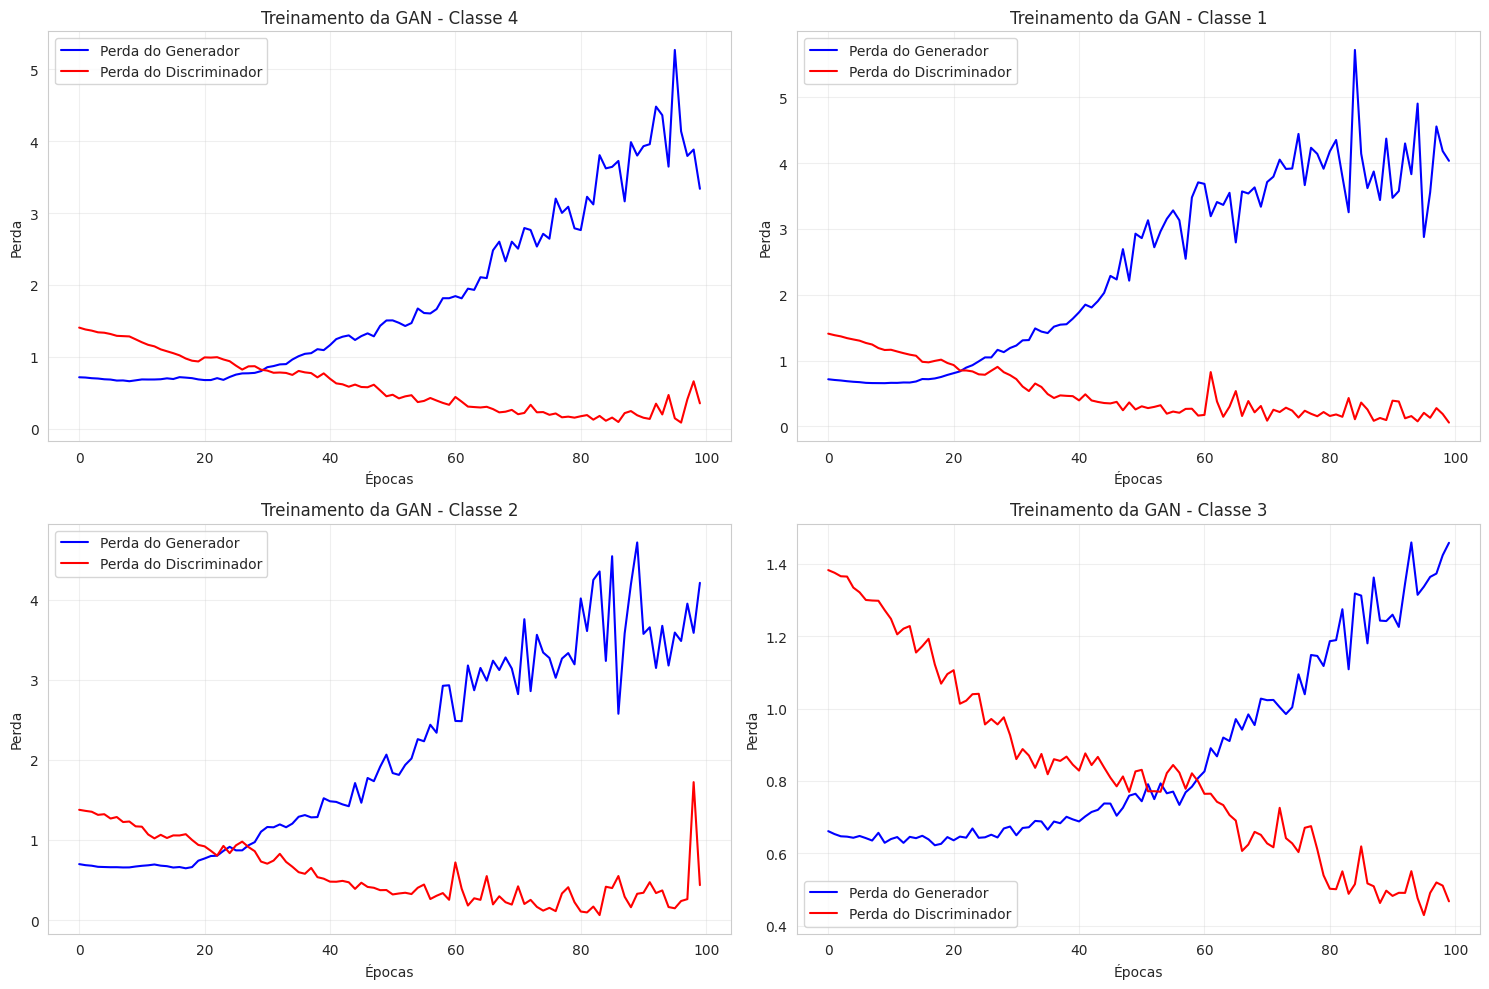

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Perda do Generador', color='blue')
    ax.plot(epochs, history['d_losses'], label='Perda do Discriminador', color='red')

    ax.set_title(f'Treinamento da GAN - Classe {class_id}')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Perda')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

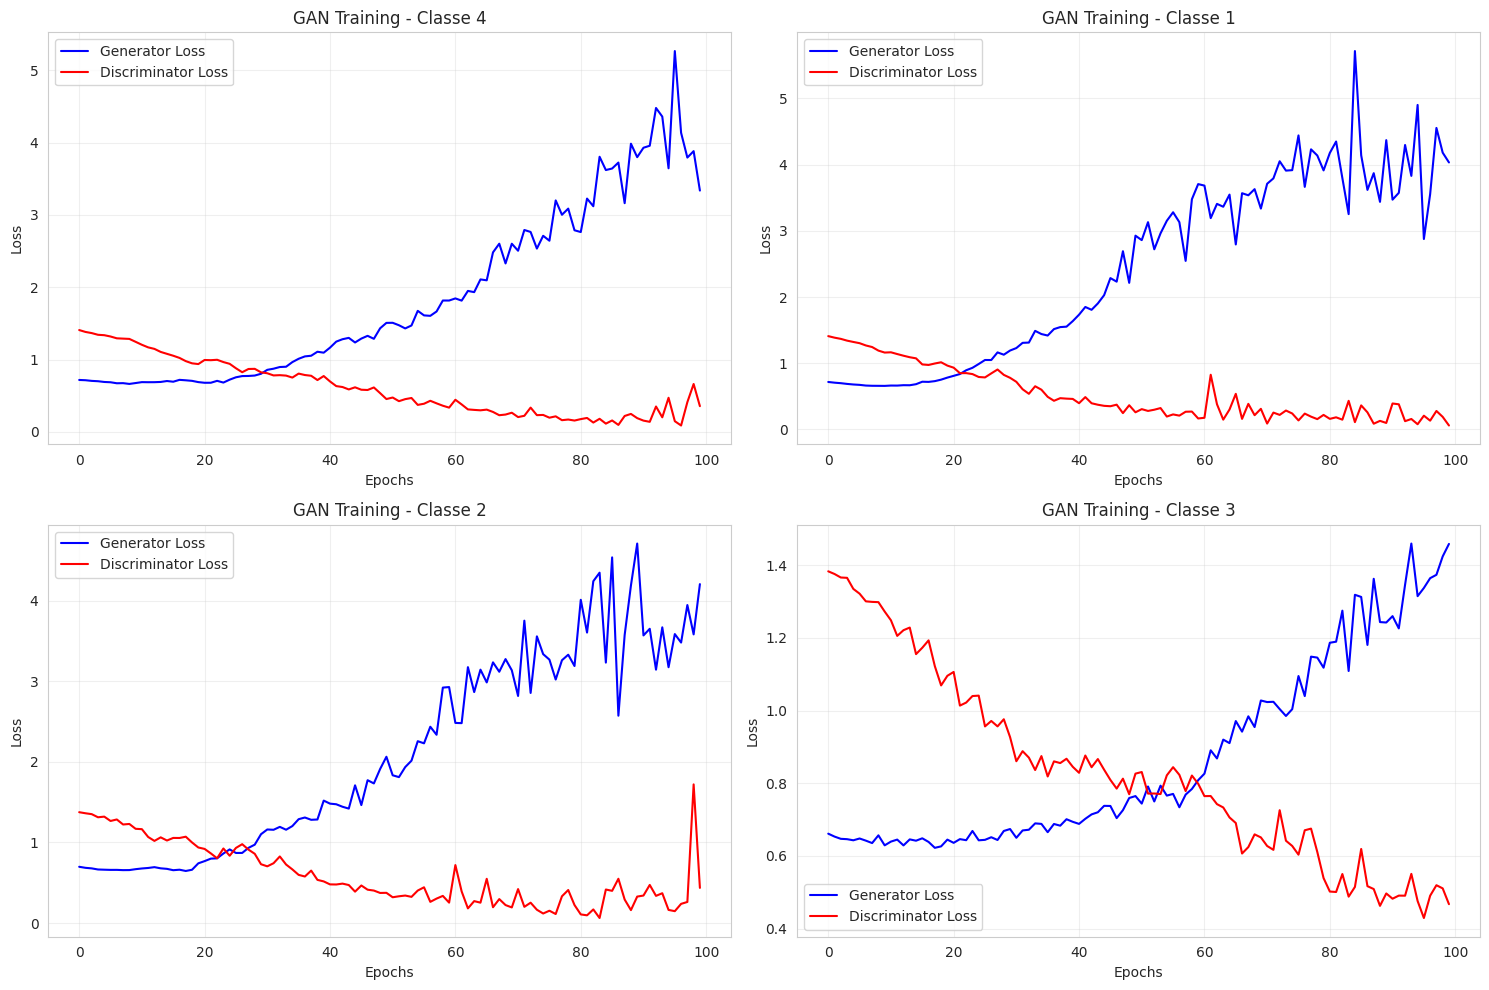

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

plot_idx = 0
for class_id, history in training_histories.items():
    if plot_idx >= 4:
        break

    ax = axes[plot_idx]

    epochs = range(len(history['g_losses']))
    ax.plot(epochs, history['g_losses'], label='Generator Loss', color='blue')
    ax.plot(epochs, history['d_losses'], label='Discriminator Loss', color='red')

    ax.set_title(f'GAN Training - Classe {class_id}')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plot_idx += 1

for i in range(plot_idx, 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
df_gan_augmented_combined['tokenized_words'] = df_gan_augmented_combined['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_gan_augmented_combined['removed_stopwords'] = df_gan_augmented_combined['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_gan_augmented_combined['tokenized_words_joined'] = df_gan_augmented_combined['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

def test_model_performance_gan(data, title):
    """Testa performance do modelo com dados GAN-aumentados"""
    print(f"\n=== {title} ===")
    print(f"Tamanho do dataset: {len(data)}")

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype('int')

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        'Naive Bayes': MultinomialNB(alpha=1.0),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'SVM': SVC(kernel='linear', random_state=42, C=1.0, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=50, class_weight='balanced', min_samples_split=2)
    }

    results = {}

    for model_name, model in models.items():
        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            results[model_name] = {
                'accuracy': accuracy_score(y_val, y_pred),
                'f1': f1_score(y_val, y_pred, average='macro'),
                'precision': precision_score(y_val, y_pred, average='macro'),
                'recall': recall_score(y_val, y_pred, average='macro')
            }

            print(f"{model_name}:")
            print(f"  Accuracy: {results[model_name]['accuracy']:.4f}")
            print(f"  F1-Score: {results[model_name]['f1']:.4f}")

        except Exception as e:
            print(f"Erro com {model_name}: {e}")
            results[model_name] = {'accuracy': 0, 'f1': 0, 'precision': 0, 'recall': 0}

    return results

df_original_processed = pd.DataFrame()
df_original_processed = df_combined.copy()
df_original_processed['tokenized_words'] = df_original_processed['Transcription'].apply(
    lambda x: word_tokenize(str(x))
)
df_original_processed['removed_stopwords'] = df_original_processed['tokenized_words'].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)
df_original_processed['tokenized_words_joined'] = df_original_processed['removed_stopwords'].apply(
    lambda x: ' '.join(x)
)

results_original_gan = test_model_performance_gan(df_original_processed, "DADOS ORIGINAIS")
results_gan_augmented = test_model_performance_gan(df_gan_augmented_combined, "DADOS GAN-AUMENTADOS")


=== DADOS ORIGINAIS ===
Tamanho do dataset: 55
Naive Bayes:
  Accuracy: 0.4545
  F1-Score: 0.3016
Logistic Regression:
  Accuracy: 0.4545
  F1-Score: 0.3016
SVM:
  Accuracy: 0.4545
  F1-Score: 0.4444


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest:
  Accuracy: 0.1818
  F1-Score: 0.1111

=== DADOS GAN-AUMENTADOS ===
Tamanho do dataset: 455
Naive Bayes:
  Accuracy: 0.9121
  F1-Score: 0.9116
Logistic Regression:
  Accuracy: 0.9011
  F1-Score: 0.9025
SVM:
  Accuracy: 0.9121
  F1-Score: 0.9142
Random Forest:
  Accuracy: 0.9341
  F1-Score: 0.9356


In [ ]:
df_original_combined_processed = preprocess_dataframe(df_combined)
df_gan_augmented_combined_processed = preprocess_dataframe(df_gan_augmented_combined)

results_combined_original = find_best_models_and_evaluate(df_original_combined_processed, "DADOS ORIGINAIS")
results_combined_gan_augmented = find_best_models_and_evaluate(df_gan_augmented_combined_processed, "DADOS GAN-AUMENTADOS")

print("\n\n=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===")
for model, metrics in results_combined_original.items():
    print(f"\nModelo: {model}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

print("\n\n=== RESULTADOS FINAIS (DADOS GAN-AUMENTADOS) ===")
for model, metrics in results_combined_gan_augmented.items():
    print(f"\nModelo: {model}")
    print(f"  Melhores Parâmetros: {metrics.get('best_params')}")
    print(f"  Acurácia: {metrics.get('accuracy'):.4f}")
    print(f"  F1-Score: {metrics.get('f1'):.4f}")
    print(f"  Precision: {metrics.get('precision'):.4f}")
    print(f"  Recall: {metrics.get('recall'):.4f}")

Pré-processando DataFrame... Tamanho: 55 linhas.
Pré-processando DataFrame... Tamanho: 455 linhas.
INICIANDO AVALIAÇÃO: DADOS ORIGINAIS

Tamanho do dataset: 55
--- Treinando e otimizando Logistic Regression ---
  Melhores parâmetros: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
  Accuracy: 0.5455
  F1-Score (Macro): 0.3205
  Precision: 0.3611
  Recall: 0.3750

--- Treinando e otimizando Random Forest ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 10}
  Accuracy: 0.6364
  F1-Score (Macro): 0.5060
  Precision: 0.5000
  Recall: 0.5625

--- Treinando e otimizando SVM ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.5455
  F1-Score (Macro): 0.3205
  Precision: 0.3611
  Recall: 0.3750

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.5, 'fit_prior': True}
  Accuracy: 0.4545
  F1-Score (Macro): 0.2429
  Precision: 0.3500
  Recall: 0.3125

INICIANDO AVALIAÇÃO: DADOS GAN-AUMENTADOS

Tamanho do dataset: 455
--- Treinando e otimizando Logistic Regression ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Melhores parâmetros: {'C': 10.0, 'penalty': 'l1', 'solver': 'liblinear'}
  Accuracy: 0.8791
  F1-Score (Macro): 0.8806
  Precision: 0.8933
  Recall: 0.8782

--- Treinando e otimizando Random Forest ---
  Melhores parâmetros: {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
  Accuracy: 0.8681
  F1-Score (Macro): 0.8768
  Precision: 0.9167
  Recall: 0.8682

--- Treinando e otimizando SVM ---
  Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
  Accuracy: 0.8791
  F1-Score (Macro): 0.8846
  Precision: 0.9046
  Recall: 0.8787

--- Treinando e otimizando Naive Bayes ---
  Melhores parâmetros: {'alpha': 0.5, 'fit_prior': True}
  Accuracy: 0.9121
  F1-Score (Macro): 0.9172
  Precision: 0.9375
  Recall: 0.9118



=== RESULTADOS FINAIS (DADOS ORIGINAIS) ===

Modelo: Logistic Regression
  Acurácia: 0.5455
  F1-Score: 0.3205
  Precision: 0.3611
  Recall: 0.3750

Modelo: Random Forest
  Acurácia: 0.6364
  F1-Score: 0.

## Plots

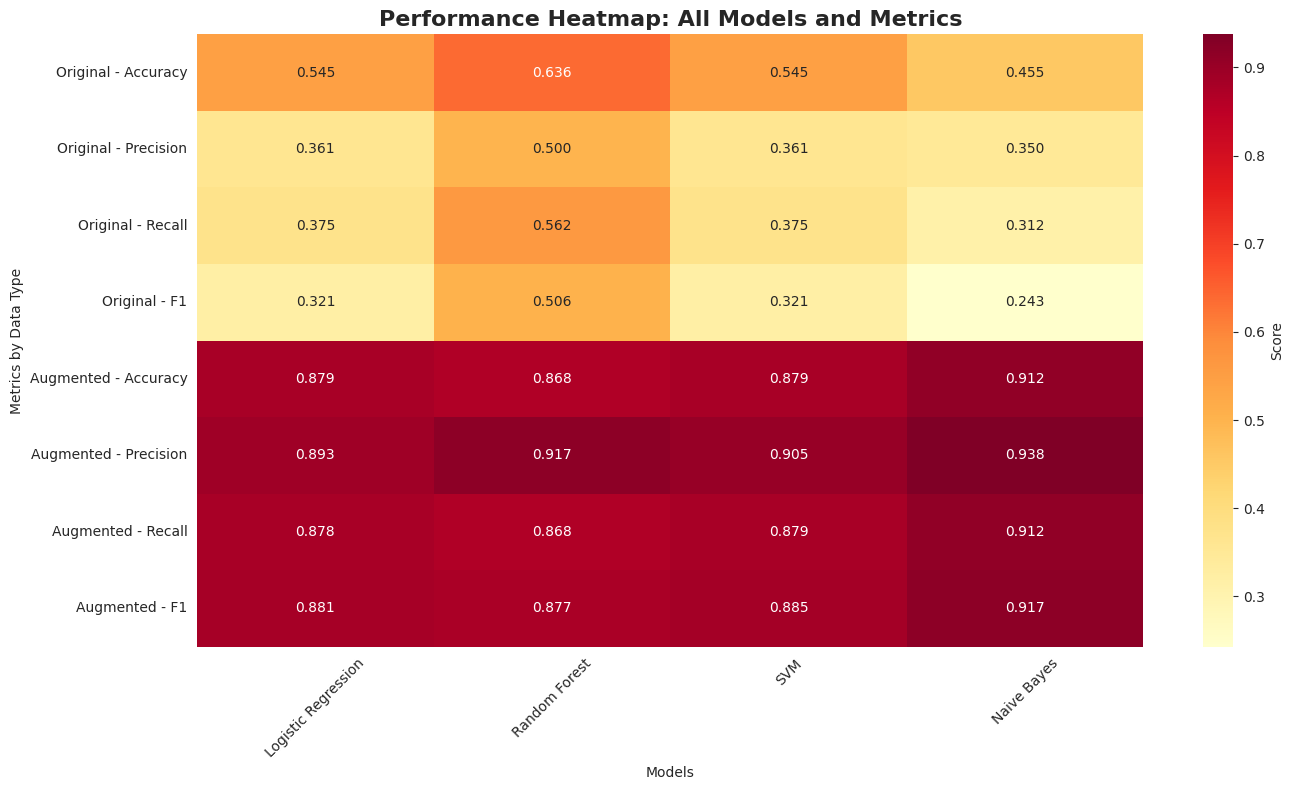

In [ ]:
comparison_df = create_comparison_df(results_combined_original, results_combined_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
metrics = ['accuracy', 'precision', 'recall', 'f1']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Score'})

plt.title('Performance Heatmap: All Models and Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Metrics by Data Type')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

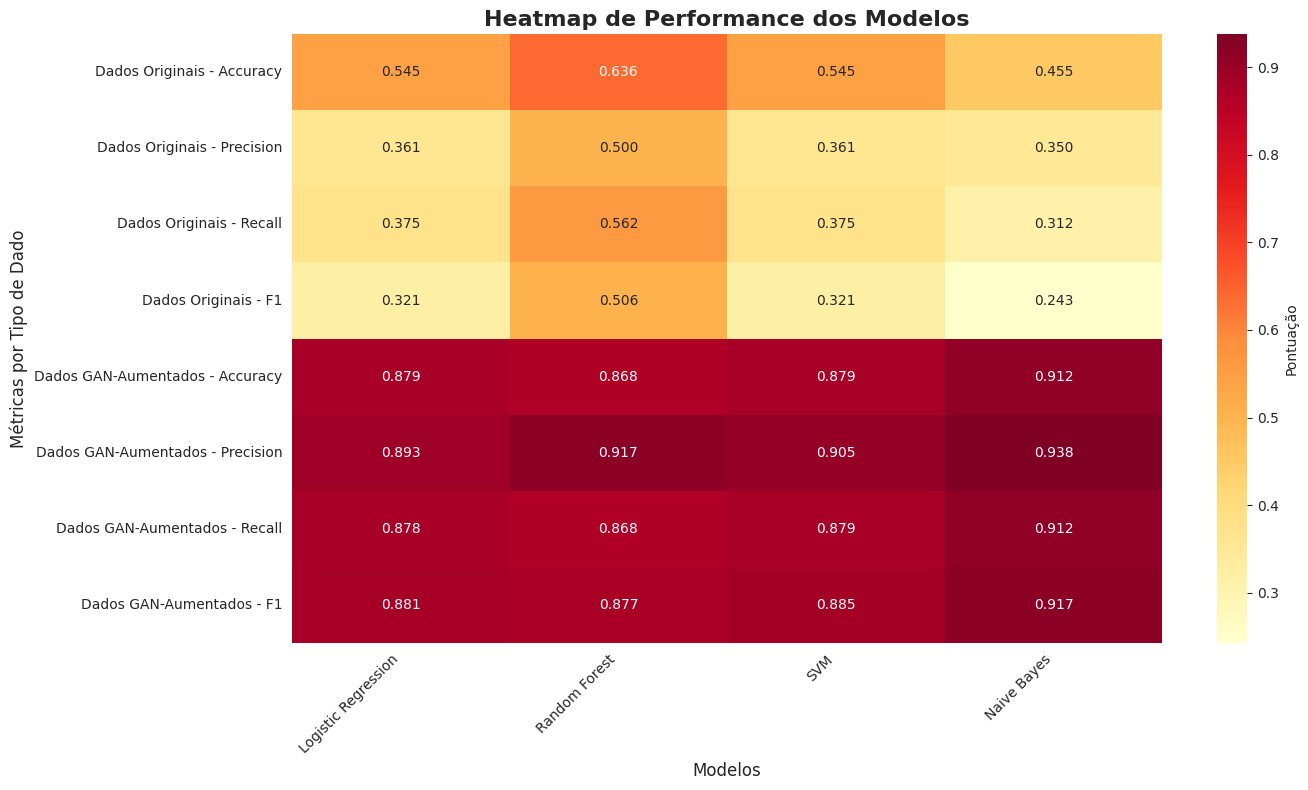

In [ ]:
comparison_df = create_comparison_df(results_combined_original, results_combined_gan_augmented)

plt.figure(figsize=(14, 8))

# Criar matriz para heatmap
metrics_matrix = []
models_list = comparison_df['model'].unique()
conditions = ['Original', 'Augmented']
conditions_br = ['Dados Originais', 'Dados GAN-Aumentados']
metrics = ['accuracy', 'precision', 'recall', 'f1']
metrics_labels_pt = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']

for condition in conditions:
    for metric in metrics:
        row = []
        for model in models_list:
            value = comparison_df[(comparison_df['model'] == model) &
                                (comparison_df['condition'] == condition)][metric].iloc[0]
            row.append(value)
        metrics_matrix.append(row)

# Criar labels para o heatmap
y_labels = [f'{condition} - {metric.capitalize()}' for condition in conditions_br for metric in metrics]

# Plot heatmap
sns.heatmap(metrics_matrix,
            xticklabels=models_list,
            yticklabels=y_labels,
            annot=True,
            fmt='.3f',
            cmap='YlOrRd',
            cbar_kws={'label': 'Pontuação'})

plt.title('Heatmap de Performance dos Modelos', fontsize=16, fontweight='bold')
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Métricas por Tipo de Dado', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [ ]:
def plot_class_distribution(data, title):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimensão 1': X_embedded[:, 0],
        'Dimensão 2': X_embedded[:, 1],
        'Classe': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimensão 1',
        y='Dimensão 2',
        hue='Classe',
        style='Classe',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Distribuição das Classes ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("Componente t-SNE 1", fontsize=12)
    plt.ylabel("Componente t-SNE 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


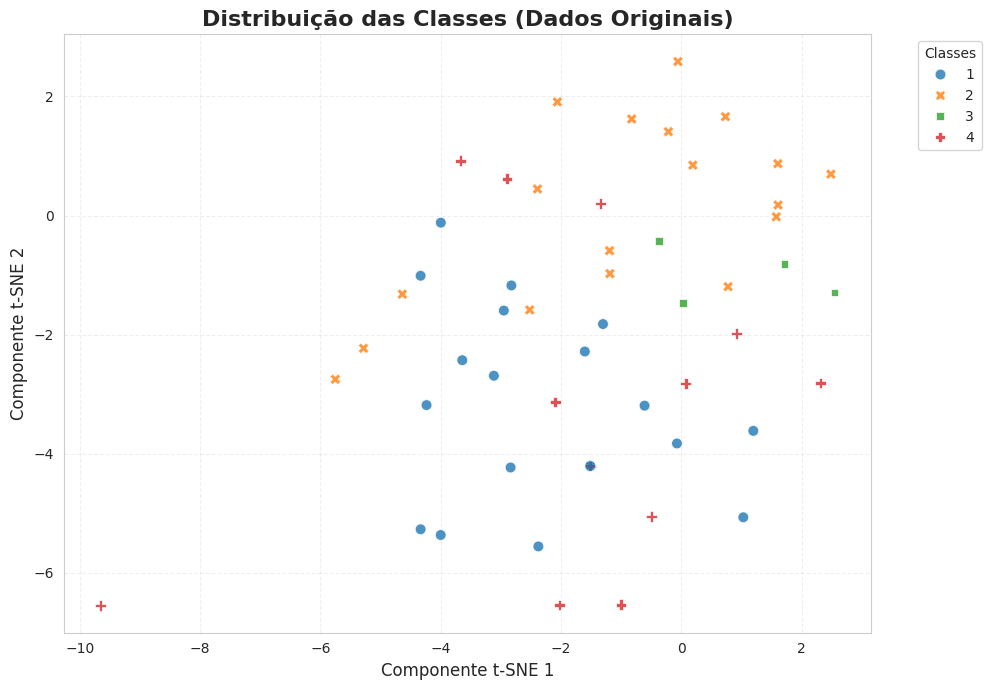

In [ ]:
plot_class_distribution(df_original_combined_processed, "Dados Originais")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


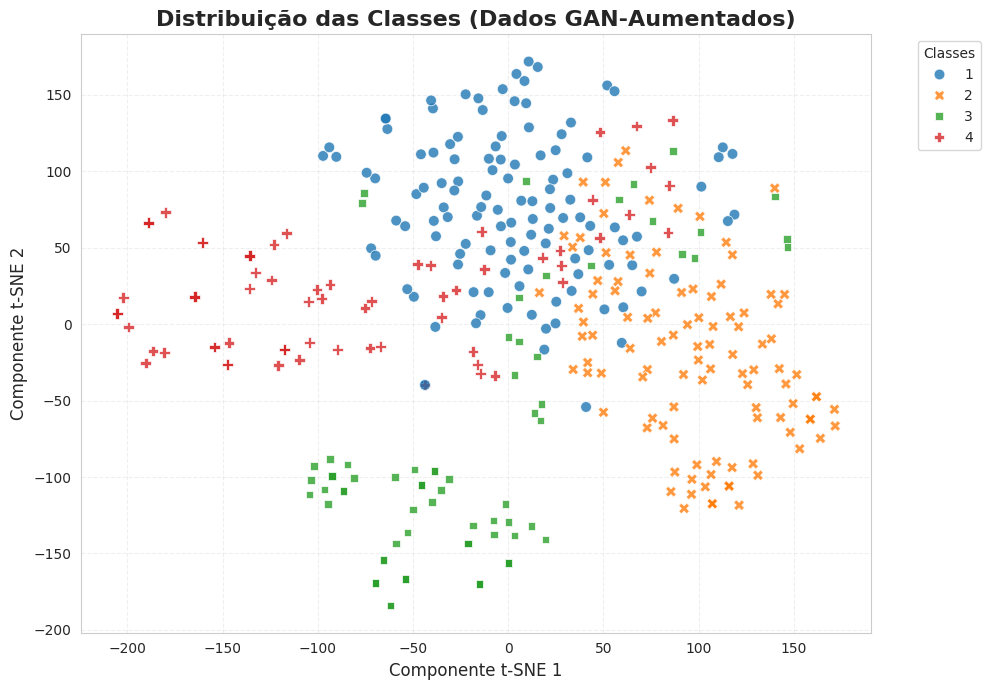

In [ ]:
plot_class_distribution(df_gan_augmented_combined_processed, "Dados GAN-Aumentados")

In [ ]:
def plot_class_distribution(data, title):
    # Vectorize the text data using TF-IDF
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=1)
    X = vectorizer.fit_transform(data['tokenized_words_joined'])
    y = data['Classificação'].astype(int)

    max_components = min(100, X.shape[0] - 1, X.shape[1] - 1)
    if max_components <= 1:
        print(f"Não é possível plotar '{title}': dados insuficientes.")
        return

    X_pca = PCA(n_components=max_components, random_state=42).fit_transform(X.toarray())

    perplexity_value = min(30, X_pca.shape[0] - 1)
    X_embedded = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity_value,
        n_iter=1000,
        init='pca',
        learning_rate='auto'
    ).fit_transform(X_pca)

    plot_df = pd.DataFrame({
        'Dimension 1': X_embedded[:, 0],
        'Dimension 2': X_embedded[:, 1],
        'Class': y
    })

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        x='Dimension 1',
        y='Dimension 2',
        hue='Class',
        style='Class',
        palette='tab10',
        data=plot_df,
        alpha=0.8,
        s=60,
        edgecolor='w'
    )

    plt.title(f"Class Distribution ({title})", fontsize=16, fontweight='bold')
    plt.xlabel("t-SNE 1 Component", fontsize=12)
    plt.ylabel("t-SNE 2 Component", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)

    plt.legend(title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


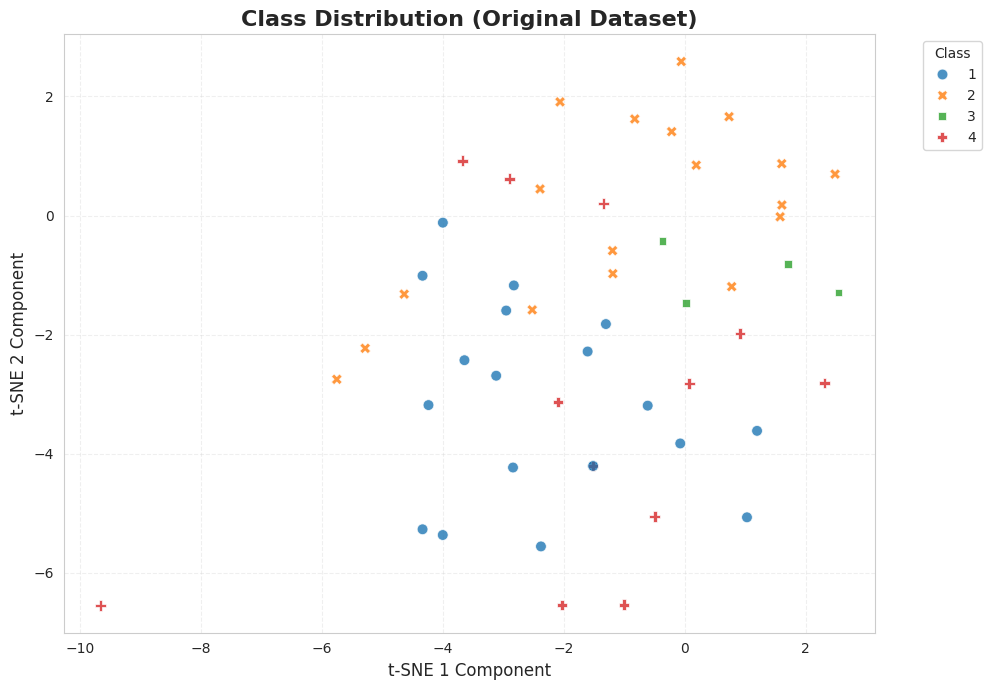

In [ ]:
plot_class_distribution(df_original_combined_processed, "Original Dataset")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


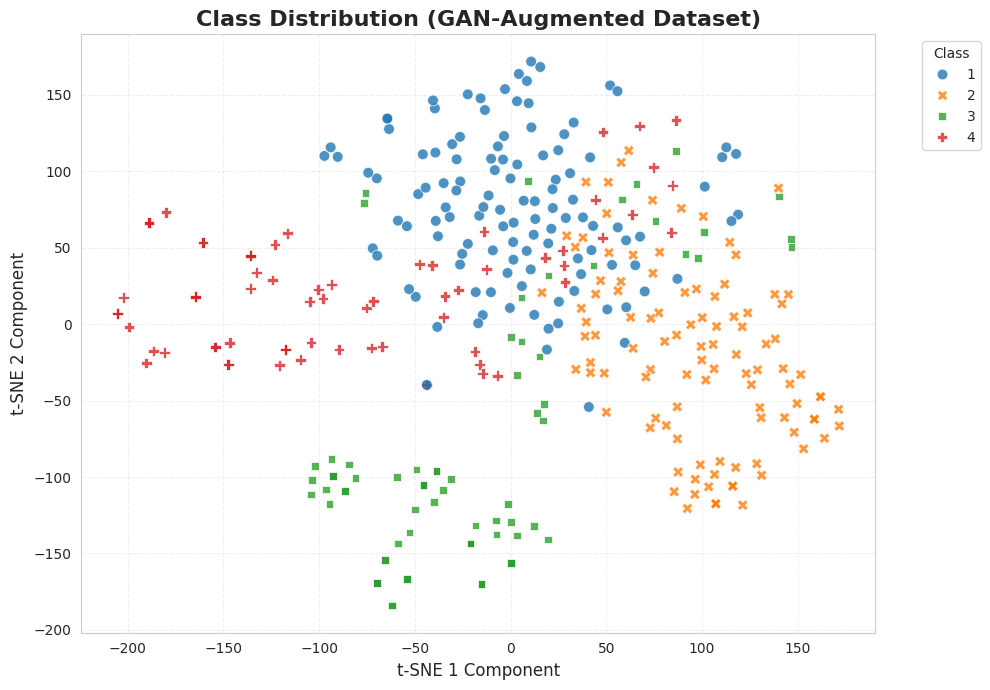

In [ ]:
plot_class_distribution(df_gan_augmented_combined_processed, "GAN-Augmented Dataset")